In [1]:
# ================================================================================
# BLOQUE 1: IMPORTACIONES Y CONFIGURACIÓN
# ================================================================================

# --- Librerías Estándar de Python ---
import os
import time
import warnings
from dateutil.relativedelta import relativedelta

# --- Librerías de Terceros (Análisis y Datos) ---
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import datetime
import requests
from scipy.stats import spearmanr
from scipy.stats.mstats import winsorize

# --- Librerías de Visualización ---
import matplotlib.pyplot as plt

# --- Librerías de Machine Learning (Modelos) ---
from catboost import CatBoostRegressor,CatBoostRanker, Pool
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline as _SkPipe
from xgboost import XGBRegressor, XGBRanker

# --- Librerías de Machine Learning (Utilidades y Métricas) ---
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


try:
    from IPython.display import display as _display
    def safe_display(obj): _display(obj)
except Exception:
    def safe_display(obj): print(obj.to_string() if hasattr(obj, "to_string") else obj)


# ================================================================================
# --- CONFIGURACIÓN GENERAL DEL SCRIPT ---
# ================================================================================

# Ignorar warnings para una salida más limpia durante la ejecución
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None     

DO_PERM_TEST    = False  # test de permutación (era n_perm=50)
DO_STRESS_TESTS = False  # forward-chain, purged 6m, ventanas 12/24/36/48/60


In [2]:
# ===============================================================================
# BLOQUE 2 · Configuración de la API Finnhub (segura)
# ===============================================================================

# Cargar variables desde .env si existe (requiere python-dotenv)
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

FINNHUB_API_KEY = os.getenv("FINNHUB_API_KEY", "").strip()

if not FINNHUB_API_KEY:
    print("⚠️  FINNHUB_API_KEY no está definida en el entorno.")
    ENABLE_FINNHUB = False
else:
    ENABLE_FINNHUB = True
    print("🔐 FINNHUB_API_KEY detectada (OK).")

CACHE_FILE    = "finnhub_sector_industry.pkl"  # Cache local para no repetir descargas
RATE_LIMIT    = 60  # Límite de llamadas por minuto para el plan gratuito de Finnhub
SLEEP_SECONDS = 61  # Pausa tras RATE_LIMIT llamadas (un segundo extra por seguridad)


🔐 FINNHUB_API_KEY detectada (OK).


In [3]:
# ===============================================================================
# BLOQUE 3· Reproducibilidad total (semillas, env, logging, metadatos)
# ===============================================================================

import os, sys, json, random, platform, subprocess, time
import numpy as np

# (opcional) si usás TensorFlow/Keras
try:
    import tensorflow as tf
except Exception:
    tf = None

def set_global_determinism(seed: int = 42, enable_tf: bool = True):
    """Fija semillas y banderas para resultados reproducibles."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"         # TF determinista
    os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
    os.environ["OMP_NUM_THREADS"] = "1"              # evita non-determinism por paralelismo
    os.environ["OPENBLAS_NUM_THREADS"] = "1"
    os.environ["MKL_NUM_THREADS"] = "1"
    os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
    os.environ["NUMEXPR_NUM_THREADS"] = "1"

    random.seed(seed)
    np.random.seed(seed)

    if enable_tf and tf is not None:
        try:
            tf.random.set_seed(seed)
            # Forzar single-thread en TF para mayor determinismo
            tf.config.threading.set_intra_op_parallelism_threads(1)
            tf.config.threading.set_inter_op_parallelism_threads(1)
        except Exception as e:
            print(f"[WARN] No se pudo fijar determinismo TF: {e}")

    print(f"[OK] Semillas y entorno fijados con seed={seed}")

# --- GPU safety para TensorFlow (evita OOM y calores) ---
if tf is not None:
    try:
        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            for g in gpus:
                tf.config.experimental.set_memory_growth(g, True)
            print(f"[TF] GPU detectada ({len(gpus)}), memory_growth=True")
        else:
            print("[TF] Sin GPU; correrá en CPU.")
    except Exception as e:
        print(f"[TF] No pude configurar memory_growth: {e}")    

def lib_versions():
    """Devuelve versiones útiles para reproducibilidad."""
    vers = {"python": sys.version.split()[0], "platform": platform.platform()}
    def _get_ver(mod, name):
        try:
            import importlib
            m = importlib.import_module(mod)
            vers[name] = getattr(m, "__version__", "unknown")
        except Exception:
            vers[name] = "not_installed"
    _get_ver("numpy","numpy"); _get_ver("pandas","pandas"); _get_ver("scipy","scipy")
    _get_ver("sklearn","scikit_learn"); _get_ver("xgboost","xgboost")
    _get_ver("lightgbm","lightgbm"); _get_ver("catboost","catboost")
    _get_ver("tensorflow","tensorflow"); _get_ver("keras","keras")
    return vers

def save_run_metadata(path_json:str,
                      seed:int,
                      feature_cols:list=None,
                      target_col:str=None,
                      extra:dict=None):
    """Guarda metadatos mínimos de la corrida."""
    meta = {
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "seed": seed,
        "versions": lib_versions(),
        "feature_cols": list(feature_cols) if feature_cols is not None else None,
        "target_col": target_col,
    }
    if extra:
        meta["extra"] = extra
    os.makedirs(os.path.dirname(path_json) or ".", exist_ok=True)
    with open(path_json, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)
    print(f"[OK] Metadatos guardados en: {path_json}")

# ======= INVOCACIÓN TEMPRANA (llamar una sola vez, bien arriba del pipeline) =======
GLOBAL_SEED = 42
set_global_determinism(GLOBAL_SEED, enable_tf=True)

# ===============================================================================
HOLDOUT_M = 24
assert HOLDOUT_M % 3 == 0, f"HOLDOUT_M ({HOLDOUT_M}) debe ser múltiplo de 3 para el rebalanceo trimestral."

# === Cadencia trimestral (pasos) y embargo en MESES reales ===
STEP_M     = 3                 # una “pasada” = 3 meses
EMBARGO_M  = 3                 # embargo en MESES reales (sugerido = horizonte)
GAP_STEPS  = max(1, EMBARGO_M // STEP_M)   # embargo en pasos trimestrales

[TF] GPU detectada (1), memory_growth=True
[OK] Semillas y entorno fijados con seed=42


In [4]:
# ================================================================================
# BLOQUE 4: CARGA, LIMPIEZA INICIAL Y ENRIQUECIMIENTO CON DATOS DE SECTOR
# ================================================================================

# Cargar los datos
file_path = 'D:/OneDrive/Desktop/MCD/Tesis/Datos_fuente_Bloomberg/en valores/serie completa 2014-2024/Dataset/dataset_oct_2014-set_2024.xlsx'
df = pd.read_excel(file_path, sheet_name='dataset')

# Fechas
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y%m%d')

# ---------- Conversión % robusta (CPI/FFR/Expectativas) ----------
def to_decimal_smart(series: pd.Series, verbose: bool = True) -> pd.Series:
    s = series.astype(str).str.strip()
    s = (s.str.replace('%', '', regex=False)
           .str.replace(',', '', regex=False))  # quita separador de miles si aparece
    s = pd.to_numeric(s, errors='coerce')

    nn = s.dropna()
    if nn.empty:
        return s

    # Heurística: si ≥20% de valores >1 o p95>1.5, asumimos que venía en %
    frac_gt1 = (nn > 1.0).mean()
    p95 = float(nn.quantile(0.95))
    is_percent = (frac_gt1 >= 0.20) or (p95 > 1.5)

    if verbose:
        fmt = "porcentaje (÷100)" if is_percent else "decimal (sin cambios)"
        print(f"  · Detección formato → {fmt} | frac>1={frac_gt1:.2%} | p95={p95:.3f}")

    return s / 100.0 if is_percent else s

pct_cols = [
    'CPI','CPI_Exp_mediana','CPI_Exp_promedio',
    'Fed Funds Rate','Fed Funds Rate_Exp_mediana','Fed Funds Rate_Exp_promedio'
]

print("\nNormalizando columnas en %/decimales (detección automática)…")
for col in pct_cols:
    if col in df.columns:
        print(f"  - {col}:")
        df[col] = to_decimal_smart(df[col], verbose=True)  # pon verbose=False si no querés logs

# --- NFP: limpieza más robusta (k/K y comas) ---
for col in ['Non farm payrolls','Non farm payrolls_Exp_mediana','Non farm payrolls_Exp_promedio']:
    if col in df.columns:
        s = df[col].astype(str).str.replace(',', '', regex=False).str.strip()
        s = s.str.replace('K', '', regex=False).str.replace('k', '', regex=False)
        df[col] = pd.to_numeric(s, errors='coerce')

# Ordenar datos, es crucial para cálculos temporales
df = df.sort_values(['Empresa', 'Fecha']).reset_index(drop=True)
print("Datos cargados y limpieza inicial completada.")

# --- 4.2: Descarga y Unión de Datos de Sector desde Finnhub ---
print("\nIniciando descarga de datos de sector desde Finnhub...")

# Función de limpieza para convertir ticker de Bloomberg a formato Finnhub
def bloomberg_to_symbol(tk: str) -> str:
    base = str(tk).split()[0].strip()   # ej. 'BRK/B US Equity' -> 'BRK/B'
    base = base.replace('/', '.')       # BRK/B -> BRK.B
    # Importante: Finnhub usa PUNTO para clases (no convertir '.' a '-')
    return base.upper()

symbols_to_fetch = df['Empresa'].map(bloomberg_to_symbol).unique().tolist()

# Cargar caché si existe
if os.path.exists(CACHE_FILE):
    sector_df = pd.read_pickle(CACHE_FILE)
    cached_symbols = set(sector_df['Symbol'])
else:
    sector_df = pd.DataFrame()
    cached_symbols = set()

records_to_add = []
tickers_to_process = [s for s in symbols_to_fetch if s not in cached_symbols]

if not tickers_to_process:
    print("  - Todos los datos de sector ya estaban en el caché.")
else:
    print(f"  - Se descargarán datos para {len(tickers_to_process)} nuevos tickers.")
    for i, symbol in enumerate(tickers_to_process, 1):
        print(f"    Descargando {symbol} ({i}/{len(tickers_to_process)})...")
        url = f"https://finnhub.io/api/v1/stock/profile2?symbol={symbol}&token={FINNHUB_API_KEY}"
        try:
            response = requests.get(url, timeout=15)
            response.raise_for_status()
            data = response.json()
            if data and data.get('finnhubIndustry'):
                records_to_add.append({
                    'Symbol':   symbol,
                    'Sector':   data.get('gicSector') or data.get('finnhubIndustry'),
                    'Industry': data.get('finnhubIndustry'),
                })
            else:
                print(f"    ⚠️  Sin datos de sector para {symbol}.")
        except requests.exceptions.RequestException as e:
            print(f"    ❌ Error de red para {symbol}: {e}")

        if i % RATE_LIMIT == 0 and i < len(tickers_to_process):
            print(f"  - Límite de {RATE_LIMIT} llamadas alcanzado. Pausando por {SLEEP_SECONDS} segundos...")
            time.sleep(SLEEP_SECONDS)

    if records_to_add:
        new_data_df = pd.DataFrame(records_to_add)
        sector_df = pd.concat([sector_df, new_data_df], ignore_index=True).drop_duplicates('Symbol')
        sector_df.to_pickle(CACHE_FILE)
        print(f"\n{len(records_to_add)} nuevos símbolos añadidos al caché -> {CACHE_FILE}")

# Unir los datos de sector al DataFrame principal
if not sector_df.empty:
    df['Symbol_key'] = df['Empresa'].map(bloomberg_to_symbol)
    df = pd.merge(df, sector_df, left_on='Symbol_key', right_on='Symbol', how='left')
    df.drop(columns=['Symbol_key', 'Symbol'], inplace=True)
    print("\nDatos de Sector e Industria unidos al DataFrame principal.")
else:
    print("\nNo se pudieron obtener datos de sector.")


Normalizando columnas en %/decimales (detección automática)…
  - CPI:
  · Detección formato → porcentaje (÷100) | frac>1=81.67% | p95=8.205
  - CPI_Exp_mediana:
  · Detección formato → decimal (sin cambios) | frac>1=0.00% | p95=0.081
  - CPI_Exp_promedio:
  · Detección formato → decimal (sin cambios) | frac>1=0.00% | p95=0.081
  - Fed Funds Rate:
  · Detección formato → porcentaje (÷100) | frac>1=50.83% | p95=5.500
  - Fed Funds Rate_Exp_mediana:
  · Detección formato → decimal (sin cambios) | frac>1=0.00% | p95=0.055
  - Fed Funds Rate_Exp_promedio:
  · Detección formato → decimal (sin cambios) | frac>1=0.00% | p95=0.055
Datos cargados y limpieza inicial completada.

Iniciando descarga de datos de sector desde Finnhub...
  - Se descargarán datos para 1 nuevos tickers.
    Descargando LANC (1/1)...
    ⚠️  Sin datos de sector para LANC.

Datos de Sector e Industria unidos al DataFrame principal.


In [5]:
# ===============================================================================
# BLOQUE 5 · Normalización de fechas a FIN DE MES (alineación global)
#   - Asegura que todo el pipeline (riesgo, anclaje Q-2, señales, buckets, splits)
#     trabaje en la misma grilla temporal (MonthEnd).
# ===============================================================================

print("\n🗓️  Normalizando fechas a fin de mes…")

# 1) Forzar Fecha a MonthEnd (fin de mes)
df['Fecha'] = pd.to_datetime(df['Fecha'])
df['Fecha'] = df['Fecha'].dt.to_period('M').dt.to_timestamp('M')

# 2) Resolver posibles duplicados (Empresa, Fecha) manteniendo la última fila del mes
dup_count = df.duplicated(subset=['Empresa', 'Fecha'], keep=False).sum()
if dup_count:
    df = (
        df.sort_values(['Empresa', 'Fecha'])
          .groupby(['Empresa', 'Fecha'], as_index=False)
          .tail(1)
          .reset_index(drop=True)
    )
    print(f"  · Se resolvieron {dup_count} duplicados (Empresa, Fecha).")

# 3) Orden final de seguridad
df = df.sort_values(['Empresa', 'Fecha']).reset_index(drop=True)

# 4) Chequeo rápido
assert not df.duplicated(subset=['Empresa', 'Fecha']).any(), "Quedaron duplicados (Empresa, Fecha)."

print("  · Fechas normalizadas a fin de mes y dataset ordenado.")



🗓️  Normalizando fechas a fin de mes…
  · Fechas normalizadas a fin de mes y dataset ordenado.


In [6]:
# --- 6.1: Conteo de Empresas por Sector ---
sector_counts = (
    df.drop_duplicates(['Empresa', 'Sector'])  # ➊ deja una sola fila por empresa-sector
      .groupby('Sector')['Empresa']            # ➋ agrupa por sector
      .nunique()                               # ➌ cuenta empresas únicas
      .reset_index(name='num_empresas')        # ➍ DataFrame ordenado
      .sort_values('num_empresas', ascending=False)
)

sector_counts

,Sector,num_empresas
31,Technology,18
28,Retail,17
30,Semiconductors,17
12,Electrical Equipment,12
14,Financial Services,10
16,Health Care,10
26,Professional Services,7
29,Road & Rail,6
23,Machinery,6
24,Media,6


In [7]:
# --- 6.2: Conteo de Empresas por Industria ---
industry_counts = (
    df.drop_duplicates(['Empresa', 'Industry'])  # ➊ deja una sola fila por empresa-industria
      .groupby('Industry')['Empresa']            # ➋ agrupa por industria
      .nunique()                               # ➌ cuenta empresas únicas
      .reset_index(name='num_empresas')        # ➍ DataFrame ordenado
      .sort_values('num_empresas', ascending=False)
)

industry_counts

,Industry,num_empresas
31,Technology,18
28,Retail,17
30,Semiconductors,17
12,Electrical Equipment,12
14,Financial Services,10
16,Health Care,10
26,Professional Services,7
29,Road & Rail,6
23,Machinery,6
24,Media,6


In [8]:
# ========================================================================
# BLOQUE 7 · Forzar Industry  →  11 Sectores GICS
# ========================================================================

# --- 1.  Diccionario completo ------------------------------------------
INDUSTRY_TO_GICS = {
    # Information Technology
    'Technology':                      'Information Technology',
    'Semiconductors':                  'Information Technology',

    # Consumer Discretionary
    'Retail':                          'Consumer Discretionary',
    'Consumer products':               'Consumer Discretionary',
    'Hotels, Restaurants & Leisure':   'Consumer Discretionary',
    'Auto Components':                 'Consumer Discretionary',
    'Textiles, Apparel & Luxury Goods':'Consumer Discretionary',
    'Leisure Products':                'Consumer Discretionary',
    'Distributors':                    'Consumer Discretionary',
    'Diversified Consumer Services':   'Consumer Discretionary',

    # Industrials
    'Electrical Equipment':            'Industrials',
    'Machinery':                       'Industrials',
    'Trading Companies & Distributors':'Industrials',
    'Road & Rail':                     'Industrials',
    'Commercial Services & Supplies':  'Industrials',
    'Industrial Conglomerates':        'Industrials',
    'Building':                        'Industrials',
    'Aerospace & Defense':             'Industrials',
    'Logistics & Transportation':      'Industrials',
    'Professional Services':           'Industrials',

    # Financials
    'Financial Services':              'Financials',
    'Insurance':                       'Financials',

    # Health Care
    'Health Care':                     'Health Care',
    'Biotechnology':                   'Health Care',
    'Life Sciences Tools & Services':  'Health Care',

    # Communication Services
    'Media':                           'Communication Services',
    'Communications':                  'Communication Services',

    # Consumer Staples
    'Food Products':                   'Consumer Staples',
    'Beverages':                       'Consumer Staples',

    # Utilities
    'Utilities':                       'Utilities',

    # Materials
    'Chemicals':                       'Materials',
    'Metals & Mining':                 'Materials',
    'Construction':                    'Materials',

    # Energy
    'Energy':                          'Energy',

    # Real Estate
    'Real Estate':                     'Real Estate',
}

# --- 2.  Asignar SIEMPRE a partir de Industry --------------------------
df['Sector_GICS'] = df['Industry'].map(INDUSTRY_TO_GICS).fillna('Unknown')

# --- 3.  Chequeo rápido -------------------------------------------------
print("\nDistribución después del mapeo (deberían ser ≤ 11):")
safe_display(
    df.drop_duplicates(['Empresa','Sector_GICS'])
      .groupby('Sector_GICS')['Empresa']
      .nunique()
      .sort_values(ascending=False)
      .to_frame('empresas')
)


Distribución después del mapeo (deberían ser ≤ 11):


,empresas
Sector_GICS,
Industrials,49
Consumer Discretionary,39
Information Technology,35
Health Care,13
Financials,11
Consumer Staples,10
Communication Services,8
Materials,5
Real Estate,4


In [9]:
# --- 4.  Inspección de casos 'Unknown' -----------------------------------
unknown_company_df = df[df['Sector_GICS'] == 'Unknown']

print("Detalles de la empresa (o empresas) con sector 'Unknown':")
# Mostramos columnas clave para identificarla y ver pistas
if not unknown_company_df.empty:
    safe_display(unknown_company_df[['Empresa', 'Fecha', 'Industry', 'Sector']].drop_duplicates(subset='Empresa'))
else:
    print("No se encontraron empresas con sector 'Unknown'.")

Detalles de la empresa (o empresas) con sector 'Unknown':


,Empresa,Fecha,Industry,Sector
10080,LANC US Equity,2014-10-31,NaN,NaN


In [10]:
# ========================================================================
# BLOQUE 7.a · Corrección Manual de Sectores GICS
# ========================================================================
# Basado en investigación externa, se identificó que 'LANC US Equity'
# no tenía datos de sector/industria de Finnhub. Se asigna manualmente
# al sector GICS correcto.

print("\n🔧 Aplicando correcciones manuales de sector GICS...")

# Corrección para Lancaster Colony Corporation (LANC)
df.loc[df['Empresa'] == 'LANC US Equity', 'Sector_GICS'] = 'Consumer Staples'

print("  · 'LANC US Equity' asignado a 'Consumer Staples'.")

# --- Verificación post-corrección ---
# Volvemos a correr el conteo para asegurarnos de que 'Unknown' ha desaparecido
print("\nDistribución después de la corrección manual:")
safe_display(
    df.drop_duplicates(['Empresa','Sector_GICS'])
      .groupby('Sector_GICS')['Empresa']
      .nunique()
      .sort_values(ascending=False)
      .to_frame('empresas')
)


🔧 Aplicando correcciones manuales de sector GICS...
  · 'LANC US Equity' asignado a 'Consumer Staples'.

Distribución después de la corrección manual:


,empresas
Sector_GICS,
Industrials,49
Consumer Discretionary,39
Information Technology,35
Health Care,13
Consumer Staples,11
Financials,11
Communication Services,8
Materials,5
Real Estate,4


In [11]:
# ==============================================================================
# BLOQUE 7.b · Monitoreo de cobertura del mapeo GICS (Industry → Sector_GICS)
# ==============================================================================

print("\n📊 Cobertura del mapeo a GICS")

# Normalización suave para reporte (no altera el mapeo original)
df['_Industry_raw'] = df['Industry'].astype(str).str.strip()

unk_mask = df['Sector_GICS'].eq('Unknown')
unknown_rows_pct = float(unk_mask.mean())
unknown_emps = df.loc[unk_mask, 'Empresa'].nunique()
total_emps   = df['Empresa'].nunique()
unknown_emps_pct = unknown_emps / max(1, total_emps)

print(f"  · Filas con Sector_GICS='Unknown': {unknown_rows_pct:.1%}")
print(f"  · Empresas afectadas: {unknown_emps} / {total_emps} ({unknown_emps_pct:.1%})")

# Top industrias sin mapear (por cantidad de empresas distintas)
top_unknown_industries = (
    df.loc[unk_mask & df['_Industry_raw'].ne('nan')]
      .groupby('_Industry_raw')['Empresa']
      .nunique()
      .sort_values(ascending=False)
      .head(20)
      .rename('num_empresas')
      .reset_index()
      .rename(columns={'_Industry_raw': 'Industry'})
)

if not top_unknown_industries.empty:
    print("\nTop industrias sin mapear (por # de empresas):")
    safe_display(top_unknown_industries)
else:
    print("  · No hay industrias sin mapear en el top 20.")

# (Opcional) Ver también los sectores originales asociados a esos Unknown (si existe 'Sector'):
if 'Sector' in df.columns and top_unknown_industries.shape[0] > 0:
    cross = (
        df.loc[unk_mask & df['_Industry_raw'].isin(top_unknown_industries['Industry'])]
          .groupby(['_Industry_raw','Sector'])['Empresa'].nunique()
          .sort_values(ascending=False)
          .groupby(level=0).head(3)  # top-3 sectores por Industry sin mapear
          .rename('num_empresas')
          .reset_index()
          .rename(columns={'_Industry_raw':'Industry'})
    )
    print("\nSugerencias de contexto (Industry sin mapear × Sector original):")
    safe_display(cross)

# Limpieza de columnas auxiliares de este bloque
df.drop(columns=['_Industry_raw'], inplace=True, errors='ignore')



📊 Cobertura del mapeo a GICS
  · Filas con Sector_GICS='Unknown': 0.0%
  · Empresas afectadas: 0 / 180 (0.0%)
  · No hay industrias sin mapear en el top 20.


In [12]:
# ==============================================================================
# BLOQUE 8: Descarga y Procesamiento de Tasa Libre de Riesgo (FRED)
# ==============================================================================

# --- CONFIGURACIÓN ---
# Símbolo de FRED para la T-Bill a 3 meses (tasa anualizada en %)
fred_symbol = 'TB3MS'
start_date = datetime.datetime(2014, 1, 1)
end_date = datetime.datetime.now()  # Hasta la fecha actual

print(f"Descargando datos para '{fred_symbol}' desde FRED (desde {start_date.date()})...")

try:
    # 1) Descargar datos diarios/mensuales según disponibilidad
    t_bills_rate_raw = web.DataReader(fred_symbol, 'fred', start_date, end_date)

    # 2) Remuestrear a FIN DE MES y rellenar huecos hacia adelante (valor más reciente conocido)
    t_bills_rate = t_bills_rate_raw.resample('M').last().ffill()
    print("  · Fechas re-muestreadas a fin de mes y huecos rellenados (ffill).")

    # 3) Convertir a decimal y calcular retorno mensual **efectivo**
    #    Usa to_decimal_smart si lo definiste en el Bloque 4; si no, divide por 100.
    if 'to_decimal_smart' in globals():
        annual_rate = to_decimal_smart(t_bills_rate[fred_symbol], verbose=False)
    else:
        annual_rate = pd.to_numeric(t_bills_rate[fred_symbol], errors='coerce') / 100.0

    # Seguridad numérica (por si FRED trae valores raros)
    annual_rate = annual_rate.clip(lower=-0.99, upper=1.00)
    t_bills_rate[fred_symbol] = annual_rate

    # Tasa mensual efectiva: (1 + r_anual)^(1/12) - 1
    t_bills_rate['risk_free_monthly_return'] = (1.0 + annual_rate).pow(1.0/12.0) - 1.0

    # (opcional) versión lag-1 para uso conservador
    t_bills_rate['rf_m_lag1'] = t_bills_rate['risk_free_monthly_return'].shift(1)

    # Retorno acumulado a 3 meses (para “excess return” trimestral)
    t_bills_rate['rf_3m'] = (1 + t_bills_rate['risk_free_monthly_return']).rolling(3).apply(np.prod, raw=True) - 1

    print("  · Tasa convertida a decimal y retorno mensual calculado (efectivo, no /12).")

    # 4) Index y DataFrame final prolijos
    t_bills_rate.index.name = 'Fecha'
    df_risk_free = t_bills_rate[['risk_free_monthly_return', 'rf_m_lag1']].copy()


    # 5) (Opcional) Chequeo rápido de NaNs
    n_nans = int(df_risk_free['risk_free_monthly_return'].isna().sum())
    if n_nans == 0:
        print("  · No hay NaNs en 'risk_free_monthly_return'.")
    else:
        print(f"  · Advertencia: Hay {n_nans} NaNs en 'risk_free_monthly_return' tras el procesamiento.")

    print("\n--- Datos de Tasa Libre de Riesgo listos para usar ---")
    print("Primeras filas:")
    print(df_risk_free.head())
    print("\nÚltimas filas:")
    print(df_risk_free.tail())

    # --- (Opcional) Guardar en disco ---
    # df_risk_free.to_csv('risk_free_returns_monthly_2014_present.csv')
    # print("\nDatos guardados en 'risk_free_returns_monthly_2014_present.csv'")

except Exception as e:
    print(f"\nERROR al descargar o procesar los datos de FRED: {e}")
    print("Verifica tu conexión a internet o si la librería pandas-datareader está actualizada.")
    df_risk_free = None  # Indica fallo

# --- CÓMO USARLO EN TU BACKTEST ---
#
# 1) Asegúrate de que el índice de tu DataFrame de resultados (spr_df)
#    también sea DatetimeIndex y esté a fin de mes.
#
# 2) Merge + ffill (modo estándar, suficiente para excess returns del mes t):
#    spr_df = spr_df.merge(df_risk_free, left_index=True, right_index=True, how='left')
#    spr_df['risk_free_monthly_return'].ffill(inplace=True)
#    spr_df['excess_return_net'] = spr_df['spread_net'] - spr_df['risk_free_monthly_return']
#
# 3) (Opcional, ultra-conservador) usar RF con un mes de lag:
#    df_risk_free['rf_m_lag1'] = df_risk_free['risk_free_monthly_return'].shift(1)
#    spr_df = spr_df.merge(df_risk_free[['rf_m_lag1']], left_index=True, right_index=True, how='left')
#    spr_df['rf_m_lag1'].ffill(inplace=True)
#    spr_df['excess_return_net'] = spr_df['spread_net'] - spr_df['rf_m_lag1']
#
# Nota: En ambos casos no hay fuga de información hacia el ranking cross-sectional,
# porque la RF desplaza a todos por igual ese mes. Usa el modo lag si quieres timing
# ultra conservador o si vas a emplear RF como feature del modelo.


Descargando datos para 'TB3MS' desde FRED (desde 2014-01-01)...
  · Fechas re-muestreadas a fin de mes y huecos rellenados (ffill).
  · Tasa convertida a decimal y retorno mensual calculado (efectivo, no /12).
  · No hay NaNs en 'risk_free_monthly_return'.

--- Datos de Tasa Libre de Riesgo listos para usar ---
Primeras filas:
            risk_free_monthly_return  rf_m_lag1
Fecha                                          
2014-01-31                  0.000033        NaN
2014-02-28                  0.000042   0.000033
2014-03-31                  0.000042   0.000042
2014-04-30                  0.000025   0.000042
2014-05-31                  0.000025   0.000025

Últimas filas:
            risk_free_monthly_return  rf_m_lag1
Fecha                                          
2025-04-30                  0.003442   0.003434
2025-05-31                  0.003474   0.003442
2025-06-30                  0.003458   0.003474
2025-07-31                  0.003474   0.003458
2025-08-31                  0.0

In [13]:
# ==============================================================================
# BLOQUE 9 · FEATURE ENGINEERING AVANZADO
#   – Momentum (1-3-6-12 m)
#   – Volatilidad (3-6-12 m)
#   – Sorpresas macro
#   – Momentum 18 m + Vol-de-Vol 6 m
#   – PE-zscore 6 m
#   – Momentum sectorial (seguro, usando GICS/fallback)
#   – Dummies sector GICS  / Dummy pandemia
# ==============================================================================

print("\nIniciando Feature Engineering Avanzado…")

# ────────────────────────────────────────────────────────────────────────────────
# 0)  Asegurar listas y parámetros base
# ────────────────────────────────────────────────────────────────────────────────
if 'features_mercado' not in locals() or not isinstance(features_mercado, list):
    features_mercado = []

if 'MIN_PERIODS_WINDOW' not in locals():
    MIN_PERIODS_WINDOW = 3

if 'VALUATION_MOMENTUM_WINDOW' not in locals():
    VALUATION_MOMENTUM_WINDOW = 6

# ────────────────────────────────────────────────────────────────────────────────
# 9.1  Momentum y volatilidad de precios + sorpresas macro
# ────────────────────────────────────────────────────────────────────────────────

# --- Momentum de precios -------------------------------------------------------
print("  · Calculando momentum de precios...")
for p in (1, 3, 6, 12):
    col = f'ret_P_Share_{p}m_base'
    df[col] = df.groupby('Empresa')['P_Share'].pct_change(p)
    features_mercado.append(col)

# --- Volatilidad rolling -------------------------------------------------------
print("  · Calculando volatilidad de precios...")
for w in (3, 6, 12):
    col = f'vol_P_Share_{w}m_base'
    # rolling std por empresa manteniendo alineación
    df[col] = (
        df.groupby('Empresa', group_keys=False)['P_Share']
          .apply(lambda s: s.rolling(window=w, min_periods=MIN_PERIODS_WINDOW).std())
    )
    features_mercado.append(col)

# --- Sorpresas macro -----------------------------------------------------------
print("  · Calculando sorpresas macro...")
df['dif_CPI_mediana'] = (df['CPI'] - df['CPI_Exp_mediana']) * 10_000
df['dif_FFR_mediana'] = (df['Fed Funds Rate'] - df['Fed Funds Rate_Exp_mediana']) * 10_000
df['dif_NFP_mediana'] =  df['Non farm payrolls'] - df['Non farm payrolls_Exp_mediana']

# NO imputar aquí. Dejamos NaN y más tarde, tras crear _lag1, se cae solo
# df[base_cols] = df[base_cols].fillna(0.0)
print("  · Features base creadas (sin imputar aquí; el _lag1 y dropna limpian luego).")

# ────────────────────────────────────────────────────────────────────────────────
# 9-plus  · Momentum 18 m (ret_18m_lag1)  +  Vol-de-Vol 6 m (vov_6m_lag1)
# ────────────────────────────────────────────────────────────────────────────────
print("  · Añadiendo momentum 18 m y vol-de-vol 6 m…")

# Momentum 18m con un lag adicional (info conocida al cierre t-1)
df['ret_18m_tmp']  = df.groupby('Empresa')['P_Share'].pct_change(18)
df['ret_18m_lag1'] = df.groupby('Empresa')['ret_18m_tmp'].shift(1).fillna(0.0)
df.drop(columns='ret_18m_tmp', inplace=True)
features_mercado.append('ret_18m_lag1')

# Vol-de-Vol 6m (std de la std rolling 6m), winsorizado 1-99%, luego lag(1)
vol6 = (
    df.groupby('Empresa', group_keys=False)['P_Share']
      .apply(lambda s: s.rolling(window=6, min_periods=3).std())
)
vov6 = (
    vol6.groupby(df['Empresa'], group_keys=False)
        .apply(lambda s: s.rolling(window=6, min_periods=3).std())
)

# winsorizar por percentiles globales (robusto)
p1, p99 = vov6.quantile([.01, .99])
vov6_clip = vov6.clip(lower=p1 if pd.notna(p1) else None,
                      upper=p99 if pd.notna(p99) else None)

df['vov_6m_lag1'] = vov6_clip.groupby(df['Empresa']).shift(1).fillna(0.0)
features_mercado.append('vov_6m_lag1')
print("    · ret_18m_lag1 y vov_6m_lag1 añadidas.")

# ────────────────────────────────────────────────────────────────────────────────
# 9.2  Z-score de valoración (P/E winsorizado, ventana 6 m)
# ────────────────────────────────────────────────────────────────────────────────
print("  · Calculando Z-score de valoración (PE_zscore_6m)...")

from scipy.stats.mstats import winsorize

def winsor_1pct(series: pd.Series) -> pd.Series:
    """Winsoriza la serie al 1 % por cola, conservando índice."""
    if series.dropna().shape[0] < 2:
        return series
    arr = winsorize(series.dropna().astype(float), limits=[.01, .01])
    return pd.Series(arr, index=series.dropna().index, dtype='float64').reindex(series.index)

# 1) P/E winsorizado empresa-a-empresa
df['P_E_wins'] = (
    df.groupby('Empresa', group_keys=False)['P_E']
      .apply(winsor_1pct)
)

# 2) Mediana y MAD móvil (6m) por empresa
eps = 1e-6
def rolling_mad(x):
    med = np.median(x)
    return np.median(np.abs(x - med)) + eps

df['median_6m'] = (
    df.groupby('Empresa', group_keys=False)['P_E_wins']
      .apply(lambda s: s.rolling(window=VALUATION_MOMENTUM_WINDOW,
                                 min_periods=MIN_PERIODS_WINDOW).median())
)
df['mad_6m'] = (
    df.groupby('Empresa', group_keys=False)['P_E_wins']
      .apply(lambda s: s.rolling(window=VALUATION_MOMENTUM_WINDOW,
                                 min_periods=MIN_PERIODS_WINDOW).apply(rolling_mad, raw=True))
)

# 3) Z-score robusto
df['PE_zscore_6m'] = (df['P_E_wins'] - df['median_6m']) / (df['mad_6m'] * 1.4826)
df['PE_zscore_6m'].replace([np.inf, -np.inf], 0.0, inplace=True)
df['PE_zscore_6m'].fillna(0.0, inplace=True)

# 4) Dummy historial corto
df['is_short_hist_zscore'] = (df.groupby('Empresa').cumcount() < VALUATION_MOMENTUM_WINDOW).astype(int)

# Limpieza temporales
df.drop(columns=['P_E_wins', 'median_6m', 'mad_6m'], inplace=True)
features_mercado += ['PE_zscore_6m', 'is_short_hist_zscore']
print("  · Z-score de valoración (PE_zscore_6m) calculado.")

# ────────────────────────────────────────────────────────────────────────────────
# 9.2-bis  Momentum sectorial (seguro) — usa Sector_GICS con fallback
# ────────────────────────────────────────────────────────────────────────────────
print("  · Calculando señal de momentum sectorial (versión segura, GICS/fallback)…")

# Columna de sector de referencia: GICS si existe; si no, Sector; si no, 'Unknown'
sec1 = df['Sector_GICS'] if 'Sector_GICS' in df.columns else pd.Series(index=df.index, dtype='object')
sec2 = df['Sector']      if 'Sector'      in df.columns else pd.Series(index=df.index, dtype='object')
df['Sector_ref'] = sec1.where(sec1.notna(), sec2).fillna('Unknown')


# Usar precios lag-1 (info disponible al cierre t-1)
df['P_Share_l1'] = df.groupby('Empresa')['P_Share'].shift(1)

tmp = (
    df[['Fecha', 'Empresa', 'Sector_ref', 'P_Share_l1']]
      .dropna(subset=['Sector_ref', 'P_Share_l1'])
      .sort_values(['Empresa', 'Fecha'])
)

# Retornos sobre P_Share_l1 (→ info hasta t-1)
tmp['ret1']  = tmp.groupby('Empresa')['P_Share_l1'].pct_change(1)
tmp['ret12'] = tmp.groupby('Empresa')['P_Share_l1'].pct_change(12)

# Promedio por sector y score
sector_mom = (
    tmp.groupby(['Fecha', 'Sector_ref'])[['ret12', 'ret1']].mean().reset_index()
)
sector_mom['sec_score'] = 0.5 * (sector_mom['ret12'] - sector_mom['ret1'])

# Z-score cross-sectional por fecha
def _z(s):
    mu, sd = s.mean(), s.std(ddof=0)
    return (s - mu) / (sd + 1e-9) if sd > 0 else 0.0

sector_mom['sec_score_z'] = sector_mom.groupby('Fecha')['sec_score'].transform(_z)

# Unir al DF principal y dejar la columna YA laggeada
df = df.merge(sector_mom[['Fecha', 'Sector_ref', 'sec_score_z']],
              on=['Fecha', 'Sector_ref'], how='left')

df['sec_score_z_safe'] = df['sec_score_z'].fillna(0.0)
df.drop(columns=['sec_score_z'], inplace=True)

# registra la feature con el nuevo nombre
features_mercado.append('sec_score_z_safe')
print("  · Señal sectorial segura incorporada: sec_score_z_safe")

# ────────────────────────────────────────────────────────────────────────────────
# 9.3  Dummies de sector (GICS)
# ────────────────────────────────────────────────────────────────────────────────
print("  · Creando dummies sector GICS…")
d_sec = pd.get_dummies(df['Sector_GICS'], prefix='sector', drop_first=True)
df = pd.concat([df, d_sec], axis=1)

# añadir las dummies a la lista de mercado
features_mercado += [c for c in d_sec.columns]
print(f"  · Dummies sector GICS creadas: {len(d_sec.columns)} columnas")

# ────────────────────────────────────────────────────────────────────────────────
# 9.4  Dummy pandemia (mar-20 → jun-21)
# ────────────────────────────────────────────────────────────────────────────────
print("  · Creando dummy de pandemia...")
df['pandemic_dummy'] = ((df['Fecha'] >= '2020-03-01') & (df['Fecha'] <= '2021-06-30')).astype(int)
print("  · Dummy pandemia creada.")

# ────────────────────────────────────────────────────────────────────────────────
# 9.5  Consolidar lista de features de mercado (sin duplicados)
# ────────────────────────────────────────────────────────────────────────────────
features_mercado = list(dict.fromkeys(features_mercado))  # dedup preservando orden

print("\n— Fin Bloque 4 · DataFrame listo para los lags contables —")
try:
    print("Ejemplo de filas:")
    print(df.head(5))
except Exception:
    pass



Iniciando Feature Engineering Avanzado…
  · Calculando momentum de precios...
  · Calculando volatilidad de precios...
  · Calculando sorpresas macro...
  · Features base creadas (sin imputar aquí; el _lag1 y dropna limpian luego).
  · Añadiendo momentum 18 m y vol-de-vol 6 m…
    · ret_18m_lag1 y vov_6m_lag1 añadidas.
  · Calculando Z-score de valoración (PE_zscore_6m)...
  · Z-score de valoración (PE_zscore_6m) calculado.
  · Calculando señal de momentum sectorial (versión segura, GICS/fallback)…
  · Señal sectorial segura incorporada: sec_score_z_safe
  · Creando dummies sector GICS…
  · Dummies sector GICS creadas: 10 columnas
  · Creando dummy de pandemia...
  · Dummy pandemia creada.

— Fin Bloque 4 · DataFrame listo para los lags contables —
Ejemplo de filas:
          Empresa      Fecha      P_E     P_B     P_S  P_Share       ROCE  \
0  AAPL US Equity 2014-10-31  16.8500  5.6796  3.6047   27.000  32.246867   
1  AAPL US Equity 2014-11-30  18.5553  6.2544  3.9695   29.733  32.9

In [14]:
df.head(20)

,Empresa,Fecha,P_E,P_B,P_S,P_Share,ROCE,EBIT,Total Activos,Deuda a LP,...,sector_Consumer Staples,sector_Energy,sector_Financials,sector_Health Care,sector_Industrials,sector_Information Technology,sector_Materials,sector_Real Estate,sector_Utilities,pandemic_dummy
0,AAPL US Equity,2014-10-31,16.8500,5.6796,3.6047,27.000,32.246867,10576.333333,225626.333333,29015.666667,...,False,False,False,False,False,True,False,False,False,0
1,AAPL US Equity,2014-11-30,18.5553,6.2544,3.9695,29.733,32.929333,10870.666667,228732.666667,29001.333333,...,False,False,False,False,False,True,False,False,False,0
2,AAPL US Equity,2014-12-31,14.9215,5.2147,3.2904,27.595,33.611800,11165.000000,231839.000000,28987.000000,...,False,False,False,False,False,True,False,False,False,0
3,AAPL US Equity,2015-01-31,15.8381,5.5350,3.4925,29.290,34.123267,15525.333333,241857.333333,30159.333333,...,False,False,False,False,False,True,False,False,False,0
4,AAPL US Equity,2015-02-28,17.3656,6.0689,3.8294,32.115,34.634733,19885.666667,251875.666667,31331.666667,...,False,False,False,False,False,True,False,False,False,0
5,AAPL US Equity,2015-03-31,15.3999,5.5579,3.4464,31.108,35.146200,24246.000000,261894.000000,32504.000000,...,False,False,False,False,False,True,False,False,False,0
6,AAPL US Equity,2015-04-30,15.4890,5.5900,3.4664,31.288,36.221300,22256.666667,261660.666667,35026.666667,...,False,False,False,False,False,True,False,False,False,0
7,AAPL US Equity,2015-05-31,16.1239,5.8192,3.6085,32.570,37.296400,20267.333333,261427.333333,37549.333333,...,False,False,False,False,False,True,False,False,False,0
8,AAPL US Equity,2015-06-30,14.4905,5.6940,3.2548,31.356,38.371500,18278.000000,261194.000000,40072.000000,...,False,False,False,False,False,True,False,False,False,0
9,AAPL US Equity,2015-07-31,14.0140,5.5067,3.1477,30.325,39.296467,16879.666667,265179.666667,42521.000000,...,False,False,False,False,False,True,False,False,False,0


In [15]:
# ===============================================================================
# BLOQUE 10 · ANCLAJE CONTABLE (Q-2) + TARGET + LISTAS DE FEATURES (SIMPLIFICADO)
# ===============================================================================

print("\n⏩  BLOQUE 5  –  Anclaje contable y construcción del dataset final…")

# ───────────────────────────────────────────────────────────────────────────────
# 10.0 · DEFINICIÓN DE LAS LISTAS DE FEATURES
# ───────────────────────────────────────────────────────────────────────────────

# 1) CONTABLES (nombres limpios desde el Excel)
features_contables = [
    'ROCE', 'ROA', 'EBIT', 'Total Activos', 'Deuda a LP',
    'Beneficio neto', 'ROI', 'EV', 'Cap de mercado',
    'Deuda a CP', 'Efectivo y equiv'
]
# Usar solo las columnas que realmente existen
features_contables = [col for col in features_contables if col in df.columns]

# 2) MERCADO / MOMENTUM (consolidar sin duplicar, preservando orden)
base_market = [
    'P_E','P_B','P_S',
    'ret_P_Share_1m_base','ret_P_Share_3m_base','ret_P_Share_6m_base','ret_P_Share_12m_base',
    'vol_P_Share_3m_base','vol_P_Share_6m_base','vol_P_Share_12m_base',
    'PE_zscore_6m','is_short_hist_zscore',
    'ret_18m_lag1','vov_6m_lag1','sec_score_z_safe' 
]

if 'features_mercado' in locals() and isinstance(features_mercado, list):
    # dedup preservando el orden
    seen = set()
    features_mercado = [x for x in (features_mercado + base_market) if not (x in seen or seen.add(x))]
else:
    features_mercado = base_market[:]

# Añadir dummies sectoriales creadas en Bloque 4.3 (si existen)
features_mercado += [c for c in df.columns if c.startswith('sector_')]

# 3) MACRO
features_macro = ['dif_CPI_mediana', 'dif_NFP_mediana']

print(f"    · {len(features_contables):2d} contables, "
      f"{len(features_mercado):2d} mercado, "
      f"{len(features_macro):2d} macro definidos.")

# ───────────────────────────────────────────────────────────────────────────────
# 10.1 · ANCLAJE CONTABLE (Q-2)
# ───────────────────────────────────────────────────────────────────────────────
# Mapea cada mes (t) con el último dato contable disponible de t-2 trimestres
df['periodo_trimestre'] = df['Fecha'].dt.to_period('Q')
QUARTERLY_OFFSET = 2
df['periodo_informe'] = df['periodo_trimestre'] - QUARTERLY_OFFSET

# Tomar el último registro de cada trimestre por empresa (fin de trimestre)
df_cont_q = (
    df.sort_values('Fecha')
      .groupby(['Empresa', 'periodo_trimestre'])
      .tail(1)
      .copy()
)

# Eliminar columnas contables actuales antes del merge (evita sombras)
df.drop(columns=features_contables, errors='ignore', inplace=True)

# Merge: trae las contables del trimestre (t-2) a cada fila mensual en t
df = pd.merge(
    df,
    df_cont_q[['Empresa', 'periodo_trimestre'] + features_contables],
    left_on=['Empresa', 'periodo_informe'],
    right_on=['Empresa', 'periodo_trimestre'],
    how='left'
)

# Limpieza de columnas auxiliares
df.drop(columns=[c for c in df.columns if c.startswith('periodo_')], inplace=True, errors='ignore')
print("    · Contables anclados correctamente (Q-2).")

# ───────────────────────────────────────────────────────────────────────────────
# 10.2 · VARIABLE OBJETIVO (retorno futuro a 3 meses)
# ───────────────────────────────────────────────────────────────────────────────
TARGET_HORIZON = 3
TARGET_COL = f"retorno_futuro_{TARGET_HORIZON}m"

df[TARGET_COL] = df.groupby('Empresa')['P_Share'].shift(-TARGET_HORIZON) / df['P_Share'] - 1

rows_before = len(df)
df.dropna(subset=[TARGET_COL], inplace=True)
print(f"    · Target creado. Filas eliminadas por NaN en target: {rows_before - len(df):,}")

print("\n✅  Fin Bloque 5 – DataFrame listo para el Bloque 6 (lags finales).")

# ───────────────────────────────────────────────────────────────────────────────
# 10.3 · GUARDADO DE METADATOS DE LA CORRIDA (reproducibilidad)
# ───────────────────────────────────────────────────────────────────────────────
# Si ya existe predictor_cols_final (p.ej., tras Bloque 6), lo guardamos.
# Si no, guardamos un snapshot de features crudas (sin lag) para trazabilidad.
if 'predictor_cols_final' in locals():
    feature_cols_snapshot = predictor_cols_final
else:
    feature_cols_snapshot = list(dict.fromkeys(features_mercado + features_macro
     + features_contables))

# Asegurar carpeta de artefactos
os.makedirs("artifacts", exist_ok=True)

# Guardar registro de columnas/target y versiones
save_run_metadata(
    path_json="artifacts/run_metadata.json",
    seed=GLOBAL_SEED if 'GLOBAL_SEED' in globals() else 42,
    feature_cols=feature_cols_snapshot,
    target_col=TARGET_COL,
    extra={
    "cv": {"outer": "WalkForwardPurged", "gap_steps": int(GAP_STEPS), "hold_steps": 1},
    "scorer": "Spearman_IC_monthly",
    "notes": "Rebalance 3M; target 3M; embargo 3M (meses reales)."
    }
)



⏩  BLOQUE 5  –  Anclaje contable y construcción del dataset final…
    · 11 contables, 35 mercado,  2 macro definidos.
    · Contables anclados correctamente (Q-2).
    · Target creado. Filas eliminadas por NaN en target: 540

✅  Fin Bloque 5 – DataFrame listo para el Bloque 6 (lags finales).
[OK] Metadatos guardados en: artifacts/run_metadata.json


In [16]:
features_contables

['ROCE',
 'ROA',
 'EBIT',
 'Total Activos',
 'Deuda a LP',
 'Beneficio neto',
 'ROI',
 'EV',
 'Cap de mercado',
 'Deuda a CP',
 'Efectivo y equiv']

In [17]:
df.head(20)

,Empresa,Fecha,P_E,P_B,P_S,P_Share,CPI,CPI_Exp_mediana,CPI_Exp_promedio,Fed Funds Rate,...,EBIT,Total Activos,Deuda a LP,Beneficio neto,ROI,EV,Cap de mercado,Deuda a CP,Efectivo y equiv,retorno_futuro_3m
0,AAPL US Equity,2014-10-31,16.8500,5.6796,3.6047,27.000,0.017,1.600000e-02,0.0162,0.0025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.084815
1,AAPL US Equity,2014-11-30,18.5553,6.2544,3.9695,29.733,0.013,1.600000e-02,0.0157,0.0025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.080113
2,AAPL US Equity,2014-12-31,14.9215,5.2147,3.2904,27.595,0.008,1.400000e-02,0.0142,0.0025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.127306
3,AAPL US Equity,2015-01-31,15.8381,5.5350,3.4925,29.290,-0.001,7.000000e-03,0.0069,0.0025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.068214
4,AAPL US Equity,2015-02-28,17.3656,6.0689,3.8294,32.115,0.000,-1.000000e-03,-0.0013,0.0025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.014168
5,AAPL US Equity,2015-03-31,15.3999,5.5579,3.4464,31.108,-0.001,-1.000000e-03,-0.0008,0.0025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007972
6,AAPL US Equity,2015-04-30,15.4890,5.5900,3.4664,31.288,-0.002,1.000000e-10,0.0002,0.0025,...,11165.0,231839.0,28987.0,8467.0,29.6832,471071.7208,603277.6191,6308.0,155239.0,-0.030779
7,AAPL US Equity,2015-05-31,16.1239,5.8192,3.6085,32.570,0.000,-2.000000e-03,-0.0016,0.0025,...,11165.0,231839.0,28987.0,8467.0,29.6832,471071.7208,603277.6191,6308.0,155239.0,-0.134480
8,AAPL US Equity,2015-06-30,14.4905,5.6940,3.2548,31.356,0.001,1.000000e-03,0.0006,0.0025,...,11165.0,231839.0,28987.0,8467.0,29.6832,471071.7208,603277.6191,6308.0,155239.0,-0.120583
9,AAPL US Equity,2015-07-31,14.0140,5.5067,3.1477,30.325,0.002,1.000000e-03,0.0015,0.0025,...,24246.0,261894.0,32504.0,18024.0,28.3788,522601.5018,668533.0938,3899.0,177955.0,-0.014839


In [18]:
# ===============================================================================
# BLOQUE DIAGNÓSTICO · Validaciones de anclaje y target
# ===============================================================================

print("\n🕵️  Iniciando validaciones…")

# --- ASUNCIONES ---
# df: DataFrame final (contables ya anclados Q-2)
# df_cont_q: DataFrame creado en el Bloque 5 que contiene los datos originales
# features_contables: Lista de features contables
# TARGET_COL: Nombre de la columna objetivo
# TARGET_HORIZON: Horizonte de la variable objetivo

# --------------------------------------------------------------------------- #
# 1) Chequeo de anclaje contable (Q-2) sin tautologías
#    - Debe ser CONSTANTE dentro de cada trimestre
#    - Los CAMBIOS solo deben ocurrir cuando cambia el trimestre
# --------------------------------------------------------------------------- #
print("\n🔎 Chequeo 1 — Constancia intra-trimestre y cambios solo en cambio de trimestre")

# Asegurar lista de columnas contables
if 'features_contables' not in globals() or not features_contables:
    features_contables = []

viol_intra_all = []
viol_boundary_all = []

# Precalcular periodos trimestrales actuales y previos por fila/empresa
Q_now  = df['Fecha'].dt.to_period('Q')
Q_prev = df.groupby('Empresa')['Fecha'].shift(1).dt.to_period('Q')

for col in features_contables:
    if col not in df.columns:
        continue

    # (A) Constancia dentro de cada trimestre
    nunq = (df.groupby(['Empresa', Q_now])[col]
              .nunique(dropna=False)
              .rename('n_unique')
              .reset_index())
    bad_intra = nunq.loc[nunq['n_unique'] > 1].copy()
    if not bad_intra.empty:
        bad_intra['col'] = col
        viol_intra_all.append(bad_intra)

    # (B) Cambios solo cuando cambia el trimestre
    chg = df.groupby('Empresa')[col].diff().abs() > 1e-12  # cambio de valor
    same_q = (Q_now == Q_prev)
    bad_boundary = df.loc[chg & same_q, ['Empresa', 'Fecha', col]].copy()
    if not bad_boundary.empty:
        bad_boundary['col'] = col
        bad_boundary['detalle'] = 'Cambio dentro del mismo trimestre'
        viol_boundary_all.append(bad_boundary)

# Reporte
if not viol_intra_all and not viol_boundary_all:
    print("✅ Chequeo 1 – Contables constantes por trimestre y cambios solo en límites de trimestre.")
else:
    if viol_intra_all:
        print("⚠️ Chequeo 1A – Variaciones INTRA-trimestre detectadas (revisar anclaje Q-2):")
        safe_display(pd.concat(viol_intra_all, ignore_index=True).head(20))
    if viol_boundary_all:
        print("⚠️ Chequeo 1B – Cambios detectados dentro del mismo trimestre (deberían ocurrir solo en el cambio de Q):")
        safe_display(pd.concat(viol_boundary_all, ignore_index=True).head(20))

# --------------------------------------------------------------------------- #
# 2) Vista rápida de 3 empresas al azar
# --------------------------------------------------------------------------- #
np.random.seed(42)
sel_empresas = np.random.choice(df['Empresa'].unique(), size=3, replace=False)

# --- CORRECCIÓN: Usar solo las columnas '_l' que ahora existen en df ---
cont_cols_demo = ['ROA', 'Total Activos']
# Asegurarse de que las columnas de demostración realmente existan en el DataFrame
cont_cols_demo_exist = [col for col in cont_cols_demo if col in df.columns]
cols_demo = ['Empresa', 'Fecha', 'P_Share'] + cont_cols_demo_exist

muestra = (df.loc[df['Empresa'].isin(sel_empresas), cols_demo]
             .sort_values(['Empresa', 'Fecha'])
             .groupby('Empresa', group_keys=False)
             .head(15)
             .reset_index(drop=True))

print("\n🔍 Chequeo 2 – 3 empresas al azar (primeras 15 fechas c/u):")
safe_display(muestra)

# --------------------------------------------------------------------------- #
# 3) ¿Los contables cambian solo en el mes en que llega el nuevo informe?
# --------------------------------------------------------------------------- #
violaciones = []
# El bucle ahora itera sobre 'features_contables', que solo contiene las '_l'
for col in features_contables:
    if col in df.columns:
        cambia = df.groupby('Empresa')[col].diff().abs() > 1e-12
        bad = (cambia.groupby([df['Empresa'], df['Fecha'].dt.to_period('Q')])
                     .sum()
                     .reset_index(name='n_cambios')
                     .query('n_cambios > 1'))
        if not bad.empty:
            bad['col'] = col
            violaciones.append(bad)

if not violaciones:
    print("✅ Chequeo 3 – Sin look-ahead: los contables solo cambian cuando toca.")
else:
    print("⚠️ Chequeo 3 – Algunos contables cambian antes de tiempo:")
    safe_display(pd.concat(violaciones).head())

# --------------------------------------------------------------------------- #
# 4) Consistencia del target
# --------------------------------------------------------------------------- #
chk = df[['Empresa', 'Fecha', 'P_Share', TARGET_COL]].copy()
chk['P_Share_futuro'] = chk.groupby('Empresa')['P_Share'].shift(-TARGET_HORIZON)
chk['reconstruido'] = (1 + chk[TARGET_COL]) * chk['P_Share']

err = (chk['reconstruido'] - chk['P_Share_futuro']).abs()
if err.dropna().max() < 1e-6:
    print(f"✅ Chequeo 4 – El target ({TARGET_HORIZON}m) se reconstruye sin error numérico.")
else:
    print("⚠️ Chequeo 4 – Discrepancias en la reconstrucción del target:")
    safe_display(chk.loc[err > 1e-6, ['Empresa', 'Fecha', 'P_Share',
                                 'P_Share_futuro', TARGET_COL]].head())

print("\n🟢 Validaciones finalizadas.\n")


🕵️  Iniciando validaciones…

🔎 Chequeo 1 — Constancia intra-trimestre y cambios solo en cambio de trimestre
✅ Chequeo 1 – Contables constantes por trimestre y cambios solo en límites de trimestre.

🔍 Chequeo 2 – 3 empresas al azar (primeras 15 fechas c/u):


,Empresa,Fecha,P_Share,ROA,Total Activos
0,CENT US Equity,2014-10-31,6.2457,NaN,NaN
1,CENT US Equity,2014-11-30,5.7291,NaN,NaN
2,CENT US Equity,2014-12-31,6.8718,NaN,NaN
3,CENT US Equity,2015-01-31,6.6135,NaN,NaN
4,CENT US Equity,2015-02-28,7.0910,NaN,NaN
5,CENT US Equity,2015-03-31,7.7249,NaN,NaN
6,CENT US Equity,2015-04-30,7.2436,0.7623,1148.727
7,CENT US Equity,2015-05-31,7.4353,0.7623,1148.727
8,CENT US Equity,2015-06-30,8.2650,0.7623,1148.727
9,CENT US Equity,2015-07-31,7.1927,1.3489,1188.963


✅ Chequeo 3 – Sin look-ahead: los contables solo cambian cuando toca.
✅ Chequeo 4 – El target (3m) se reconstruye sin error numérico.

🟢 Validaciones finalizadas.



In [19]:
# ===============================================================================
# Tabla de Diagnóstico de Anclaje
#   - Une por TRIMESTRE (Q), no por Fecha, para evitar NaNs en meses intra-Q
#   - (Opcional) Trae también el valor ORIGINAL del trimestre t-2 (Qm2)
# ===============================================================================

print("\n🕵️  Generando Tabla de Diagnóstico de Anclaje (Versión Final, Q-merge)...")

# 1) Elegí empresa y features a verificar
empresa_a_verificar = sel_empresas[0]
features_a_verificar = ['ROA', 'EBIT']
features_a_verificar_exist = [c for c in features_a_verificar if c in df.columns]

print(f"\nGenerando tabla para Empresa: {empresa_a_verificar}")

# 2) Subsets: anclado (mensual) y crudo trimestral
df_empresa_anclado   = df.loc[df['Empresa'] == empresa_a_verificar].copy()
df_empresa_original_q = df_cont_q.loc[df_cont_q['Empresa'] == empresa_a_verificar].copy()

# 3) Periodos trimestrales
df_empresa_anclado['Q']    = pd.PeriodIndex(df_empresa_anclado['Fecha'], freq='Q')
df_empresa_original_q['Q'] = pd.PeriodIndex(df_empresa_original_q['Fecha'], freq='Q')

# 4) Base de anclado (mensual) + renombrar columnas ancladas
tabla_final = df_empresa_anclado[['Fecha', 'Q'] + features_a_verificar_exist].copy()
tabla_final.rename(
    columns={col: f'{col}_Anclado' for col in features_a_verificar_exist},
    inplace=True
)

# 5) Traer ORIGINAL del mismo trimestre (Q)
df_orig_Q = df_empresa_original_q[['Q'] + features_a_verificar_exist].rename(
    columns={col: f'{col}_Original_Q' for col in features_a_verificar_exist}
)
tabla_final = tabla_final.merge(df_orig_Q, on='Q', how='left')

# 6) (Opcional) Traer ORIGINAL del trimestre t-2 (Qm2) para comparar 1:1 con Anclado
tabla_final['Qm2'] = tabla_final['Q'] - 2
df_orig_Qm2 = df_empresa_original_q[['Q'] + features_a_verificar_exist].rename(
    columns={'Q': 'Qm2', **{col: f'{col}_Original_Qm2' for col in features_a_verificar_exist}}
)
tabla_final = tabla_final.merge(df_orig_Qm2, on='Qm2', how='left')

# 7) Armar columnas para mostrar
cols_display = ['Fecha']
for f in features_a_verificar_exist:
    # Orden sugerido: Original del Q actual, Original Q-2 (alineable con anclado), y Anclado(Q-2)
    cols_display.extend([f'{f}_Original_Q', f'{f}_Original_Qm2', f'{f}_Anclado'])

tabla_final_display = (
    tabla_final[cols_display]
      .sort_values('Fecha')
      .reset_index(drop=True)
)

# 8) Mostrar una vista corta
print("\nTabla de Diagnóstico (Original_Q, Original_Qm2, Anclado[Q-2]):")
safe_display(tabla_final_display.head(15))
print("\n🟢 Tabla de diagnóstico generada (merge por trimestre).")



🕵️  Generando Tabla de Diagnóstico de Anclaje (Versión Final, Q-merge)...

Generando tabla para Empresa: CENT US Equity

Tabla de Diagnóstico (Original_Q, Original_Qm2, Anclado[Q-2]):


,Fecha,ROA_Original_Q,ROA_Original_Qm2,ROA_Anclado,EBIT_Original_Q,EBIT_Original_Qm2,EBIT_Anclado
0,2014-10-31,0.7623,NaN,NaN,1.373,NaN,NaN
1,2014-11-30,0.7623,NaN,NaN,1.373,NaN,NaN
2,2014-12-31,0.7623,NaN,NaN,1.373,NaN,NaN
3,2015-01-31,1.3489,NaN,NaN,1.138,NaN,NaN
4,2015-02-28,1.3489,NaN,NaN,1.138,NaN,NaN
5,2015-03-31,1.3489,NaN,NaN,1.138,NaN,NaN
6,2015-04-30,1.4166,0.7623,0.7623,49.971,1.373,1.373
7,2015-05-31,1.4166,0.7623,0.7623,49.971,1.373,1.373
8,2015-06-30,1.4166,0.7623,0.7623,49.971,1.373,1.373
9,2015-07-31,2.7799,1.3489,1.3489,38.993,1.138,1.138



🟢 Tabla de diagnóstico generada (merge por trimestre).


In [20]:
# ===============================================================================
# BLOQUE 11  –  Dataset final (lags solo mercado & macro)  [versión robusta]
# ===============================================================================

print("\n⏩  BLOQUE 11  –  Generando dataset definitivo para el modelo…")

# 0) Orden correcto para que el shift funcione bien
df = df.sort_values(['Empresa','Fecha']).reset_index(drop=True)

# 1) Compilar listas finales
#    - Mercado + Macro → lag(1), filtrando estáticas
#    - Contables → directos (ya anclados Q-2)
STATIC_PREFIXES = ('sector_',)
STATIC_EXACT    = {'is_short_hist_zscore', 'sec_score_z_safe'}

need_lag1_raw = sorted(list({*(features_mercado or []), *(features_macro or [])}))
need_lag1 = [c for c in need_lag1_raw
             if not c.startswith(STATIC_PREFIXES) and c not in STATIC_EXACT]
use_as_is = sorted(features_contables or [])

print(f"    · Mercado+Macro (lag-1): {len(need_lag1)}  ·  Contables directos: {len(use_as_is)}")

# 2) Crear/poblar columnas lag-1 para mercado+macro (evita doblar lag)
for col in need_lag1:
    if col in df.columns and not col.endswith('_lag1'):
        df[f"{col}_lag1"] = df.groupby('Empresa', sort=False)[col].shift(1)

# 2bis) Detectar columnas estáticas que deben ir 'tal cual' (sin lag)
sector_dummy_cols = [c for c in df.columns if c.startswith('sector_')]
static_passthrough = [c for c in ['sec_score_z_safe', 'is_short_hist_zscore'] if c in df.columns]

# 2ter) Predictores definitivos:
#   - mercado/macro con _lag1,
#   - contables tal cual,
#   - estáticas tal cual (dummies y señales ya normalizadas)
predictor_cols_final = [
    (c if c.endswith('_lag1') else f"{c}_lag1") for c in need_lag1 if c in df.columns
] + use_as_is + sector_dummy_cols + static_passthrough

# dedup preservando orden + filtrar por existencia real
predictor_cols_final = list(dict.fromkeys([c for c in predictor_cols_final if c in df.columns]))

# 3) Construir df_model y castear a numérico ANTES de limpiar NaNs
model_cols = ['Empresa', 'Fecha', TARGET_COL] + predictor_cols_final
df_model   = df[model_cols].copy()

for c in predictor_cols_final:
    # robustez: coerciona a numérico; NaNs se limpian en el paso siguiente
    df_model[c] = pd.to_numeric(df_model[c], errors='coerce').astype('float32')

# 4) Diagnóstico de NaNs en predictores (mostrar solo los que tienen huecos)
nan_cnt = df_model[predictor_cols_final].isna().sum()
nan_cnt = nan_cnt[nan_cnt > 0].sort_values(ascending=False)
if not nan_cnt.empty:
    print("\n[NaNs por columna en predictores] (top):")
    print(nan_cnt.head(30))

# 4bis) Limpiar NaNs (solo en predictores)
before = len(df_model)
df_model.dropna(subset=predictor_cols_final, inplace=True)
dropped = before - len(df_model)

print(f"\n    · Filas eliminadas por NaNs en predictores: {dropped:,}")
print(f"    · Dataset final: {len(df_model):,} filas  ·  {len(predictor_cols_final)} features")

# 5) Salidas finales
X = df_model[predictor_cols_final]
y = df_model[TARGET_COL]
groups = df_model['Empresa']

# ✅ Sanity checks
print("En predictor_cols_final → sector_*:", sum(c.startswith('sector_') for c in predictor_cols_final))
print("En predictor_cols_final → sec_score_z_safe?:", 'sec_score_z_safe' in predictor_cols_final)
print("En predictor_cols_final → is_short_hist_zscore?:", 'is_short_hist_zscore' in predictor_cols_final)

print("En X → incluye sector_*?:", any(c.startswith('sector_') for c in X.columns))
print("En X → incluye sec_score_z_safe?:", 'sec_score_z_safe' in X.columns)
print("En X → incluye is_short_hist_zscore?:", 'is_short_hist_zscore' in X.columns)

# (opcional) corta la corrida si faltan
assert any(c.startswith('sector_') for c in X.columns), "Faltan dummies sector_* en X"
assert 'sec_score_z_safe' in X.columns, "Falta sec_score_z_safe en X"

print(f"    · X listo: {X.shape[0]:,} filas × {X.shape[1]} cols | empresas={groups.nunique()}")

# 6) Checks rápidos de cobertura de features estáticas
print("✔ Incluye sec_score_z_safe?:", 'sec_score_z_safe' in predictor_cols_final)
print("✔ Incluye is_short_hist_zscore?:", 'is_short_hist_zscore' in predictor_cols_final)
print("✔ Incluye dummies sector_*?:", any(c.startswith('sector_') for c in predictor_cols_final))

# 7) (Opcional) Exportar set de columnas estáticas para wrappers (BLOQUE 11.y)
#    Construido en base a lo que realmente quedó en predictor_cols_final.
try:
    macro_bases = list(features_macro)
except NameError:
    macro_bases = []

macro_lag_cols_in_X = [f"{c}_lag1" for c in macro_bases if f"{c}_lag1" in predictor_cols_final]
sector_cols_in_X    = [c for c in predictor_cols_final if c.startswith('sector_')]
static_cols_for_wrappers = sorted(set(
    macro_lag_cols_in_X + sector_cols_in_X +
    [c for c in ['sec_score_z_safe','is_short_hist_zscore'] if c in predictor_cols_final]
))
print(f"    · Passthrough estático (p/ wrappers): {len(static_cols_for_wrappers)} cols")
# (En BLOQUE 11.y podés usar: 
#   zscore_cs = SafeSkipColsWrapper(_z_base, skip_cols=static_cols_for_wrappers)
#   winsor_cs = SafeSkipColsWrapper(_w_base, skip_cols=static_cols_for_wrappers)
# )



⏩  BLOQUE 11  –  Generando dataset definitivo para el modelo…
    · Mercado+Macro (lag-1): 15  ·  Contables directos: 11

[NaNs por columna en predictores] (top):
ret_P_Share_12m_base_lag1    2340
ret_P_Share_6m_base_lag1     1260
Total Activos                1080
Cap de mercado               1080
ROI                          1080
ROCE                         1080
ROA                          1080
Efectivo y equiv             1080
EV                           1080
EBIT                         1080
Deuda a LP                   1080
Deuda a CP                   1080
Beneficio neto               1080
ret_P_Share_3m_base_lag1      720
vol_P_Share_6m_base_lag1      540
vol_P_Share_3m_base_lag1      540
vol_P_Share_12m_base_lag1     540
ret_P_Share_1m_base_lag1      360
P_B_lag1                      180
dif_NFP_mediana_lag1          180
dif_CPI_mediana_lag1          180
P_S_lag1                      180
P_E_lag1                      180
PE_zscore_6m_lag1             180
dtype: int64

    · 

In [21]:
# ======================================================================
# BLOQUE: Auxiliares para Pipelines (Ensure2D y NanFix)
# ======================================================================
from sklearn.preprocessing import FunctionTransformer
import numpy as np
import pandas as pd

def _ensure_2d(A):
    if isinstance(A, pd.DataFrame):
        A = A.to_numpy()
    A = np.asarray(A, dtype=np.float32)
    if A.ndim == 1:
        A = A.reshape(-1, 1)
    return A

ensure2d = FunctionTransformer(_ensure_2d, validate=False)

def _ensure_df(X):
    import pandas as pd
    return X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

ensure_df = FunctionTransformer(_ensure_df, validate=False)

def _nan_fix(a):
    return np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)

nan_fix = FunctionTransformer(_nan_fix, validate=False)


In [22]:
# ===============================================================================
# BLOQUE 11.x · Filtro de universo mínimo por mes (robustez cross-sectional)
#   - Evita meses “flacos” que rompen deciles/quintiles e inflan métricas.
#   - Reconstruye X, y, groups y fechas tras el filtro.
#   - Define df_model_sorted / df_sorted alineados 1:1 con X/y.
# ===============================================================================

print("\n🧹  Filtrando meses con universo insuficiente…")

UNIVERSE_MIN    = 30   # mínimo de acciones por mes para mantener el mes
MIN_PER_SECTOR  = 0    # pon >0 (p.ej. 5) si quieres exigir mínimo por sector (opcional)
USE_SECTOR_GICS = 'Sector_GICS' in df.columns

# 1) Conteo por mes del universo tras el dropna de predictores
n_by_month = (
    df_model.groupby('Fecha')['Empresa']
            .nunique()
            .rename('n_empresas')
)

# 2) Si condicionás por sector, construir conteo por mes y sector
if MIN_PER_SECTOR > 0 and USE_SECTOR_GICS:
    # Mapear Sector_GICS al df_model (índices alineados con df)
    sec_series = df.loc[df_model.index, 'Sector_GICS']
    tmp = (
        pd.concat([df_model[['Fecha','Empresa']], sec_series.rename('Sector_GICS')], axis=1)
          .dropna(subset=['Sector_GICS'])
    )
    n_by_m_sec = (
        tmp.groupby(['Fecha','Sector_GICS'])['Empresa']
           .nunique()
           .rename('n_emp_sec')
           .reset_index()
    )
    ok_by_m_sec = (
        n_by_m_sec.groupby('Fecha')['n_emp_sec']
                  .apply(lambda s: (s >= MIN_PER_SECTOR).all())
    )
    mask_month_sector_ok = ok_by_m_sec.reindex(n_by_month.index).fillna(False)
else:
    mask_month_sector_ok = pd.Series(True, index=n_by_month.index)

# 3) Meses que cumplen los mínimos
mask_month_size_ok = (n_by_month >= UNIVERSE_MIN)
good_months = n_by_month.index[mask_month_size_ok & mask_month_sector_ok]

# 4) Aplicar filtro al df_model, ordenar y resetear
df_model = df_model[df_model['Fecha'].isin(good_months)].copy()
df_model = df_model.sort_values(['Fecha','Empresa']).reset_index(drop=True)

# ==============================================================================
# === FILTRO PARA REBALANCEO TRIMESTRAL ===
# ==============================================================================
print("\n" + "="*50)
print("FILTRANDO PARA REBALANCEO TRIMESTRAL (Mar, Jun, Sep, Dic)")
print(f"  · Filas antes del filtro: {len(df_model):,}")

# Nos quedamos solo con los meses de fin de trimestre
df_model = df_model[df_model['Fecha'].dt.month.isin([3, 6, 9, 12])].copy()

print(f"  · Filas después del filtro: {len(df_model):,}")
print("="*50 + "\n")
# ==============================================================================

# 4.bis) Compatibilidad → construir df_model_sorted y df_sorted alineados a df_model
df_model_sorted = df_model.copy()
df_sorted = (
    df.set_index(['Empresa','Fecha'])
      .loc[pd.MultiIndex.from_frame(df_model[['Empresa','Fecha']])]
      .reset_index()
)

# --- Alinear nombres entre df_model y predictor_cols_final (ANTES de construir X) ---

def _sanitize(idx):
    return (pd.Index(idx)
            .str.replace(r"\s+", "_", regex=True)
            .str.replace("/", "_"))

# 1) Renombrar df_model con la misma regla
df_model = df_model.rename(columns=dict(zip(df_model.columns, _sanitize(df_model.columns))))

# 2) Alinear predictor_cols_final a la misma regla
predictor_cols_final = list(_sanitize(predictor_cols_final))

# 3) Crear dummies faltantes (solo sector_*) si hiciera falta
missing = [c for c in predictor_cols_final if c not in df_model.columns]
for c in missing:
    if c.startswith("sector_"):
        df_model[c] = 0.0

# 4) Verificación final
still_missing = [c for c in predictor_cols_final if c not in df_model.columns]
if still_missing:
    raise KeyError(f"Faltan columnas reales en df_model: {still_missing[:10]}")

# 5) Reconstruir X, y, groups y fechas desde el df_model ya filtrado
X = df_model[predictor_cols_final].copy().astype('float32')
y = df_model[TARGET_COL].copy()
groups = df_model['Empresa'].copy()
DATES_SERIES = pd.to_datetime(df_model['Fecha']).reset_index(drop=True)

# 6) Sanear nombres de features (evita warning de LightGBM por espacios)
X.columns = (pd.Index(X.columns)
             .str.replace(r"\s+", "_", regex=True)
             .str.replace("/", "_"))  # opcional: otros caracteres problemáticos
predictor_cols_final = list(X.columns)  # mantener consistencia con lo que sigue

# 7) Higiene final (por si acaso)
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0.0, inplace=True)
mask_ok = y.notna().to_numpy() & np.isfinite(y.to_numpy())

X = X.loc[mask_ok].reset_index(drop=True)
y = y.loc[mask_ok].reset_index(drop=True)
groups = groups.loc[mask_ok].reset_index(drop=True)
DATES_SERIES = DATES_SERIES.loc[mask_ok].reset_index(drop=True)

# ===== FAST SAMPLE por mes (seguro; usa DATES_SERIES alineada a X/y) =====
N_PM = 120  # cantidad objetivo por mes
months_all = pd.to_datetime(DATES_SERIES).dt.to_period('M')

ix_sample = (
    pd.Series(np.arange(len(y)), index=y.index)       # posiciones válidas post-mask
      .groupby(months_all, group_keys=False)
      .apply(lambda s: s.sample(min(N_PM, len(s)), random_state=42))
      .to_numpy()
)

#X_fast = X.iloc[ix_sample].reset_index(drop=True)
#y_fast = y.iloc[ix_sample].reset_index(drop=True)
#DATES_SERIES_fast = DATES_SERIES.iloc[ix_sample].reset_index(drop=True)
#groups_fast = groups.iloc[ix_sample].reset_index(drop=True)
# ========================================================================

# === Métrica de tuning: IC mensual (segura; index de y_val) ===
from scipy.stats import spearmanr
import numpy as np
import pandas as pd

def ic_monthly_score(estimator, X_val, y_val):
    
    # Predicciones del fold
    y_hat = estimator.predict(X_val)

     # Meses correctos del SUBSET de validación
    months_sub = pd.to_datetime(DATES_SERIES.loc[X_val.index]).dt.to_period('M')

    # IC de Spearman por mes y promedio simple
    dfm = pd.DataFrame({'m': months_sub.values, 
                        'y': y_val.values, 
                        'p': np.asarray(y_hat)})
    
    ic_m = dfm.groupby('m', sort=True).apply(
        lambda g: spearmanr(g['y'], g['p'])[0]).dropna()
    
    return float(ic_m.mean()) if len(ic_m) else 0.0

spearman_scorer = ic_monthly_score

# === Mini-check (opcional, recomendable) ===
m_counts = pd.Series(pd.to_datetime(DATES_SERIES).dt.to_period('M')).value_counts().sort_index()
print(f"[Mini-check] meses válidos={m_counts.shape[0]} | mediana de nombres/mes={int(m_counts.median())}")

# Alinear también los dataframes de compatibilidad con el mismo mask
df_model_sorted = df_model_sorted.loc[mask_ok].reset_index(drop=True)
df_sorted       = df_sorted.loc[mask_ok].reset_index(drop=True)

# 7) Reporte de diagnóstico
print(f"  · Meses totales: {n_by_month.shape[0]}  |  Meses válidos: {len(good_months)}")
bad_months = n_by_month.index[~n_by_month.index.isin(good_months)]
if len(bad_months):
    worst = n_by_month.loc[bad_months].sort_values().head(5)
    print("  · Ejemplos de meses filtrados (universo pequeño):")
    print(worst)

print(f"  · Dataset final tras filtro: X={X.shape}, y={y.shape}, empresas={groups.nunique()}")

from lightgbm import LGBMRanker
from xgboost import XGBRanker

N_BINS = 10
def make_rel_labels(y_sub, months_sub, n_bins=N_BINS):
    months_sr = pd.Series(months_sub, index=y_sub.index)
    r = y_sub.groupby(months_sr).rank(method='first', pct=True)
    lab = np.minimum(n_bins-1, (r * n_bins).astype(int))
    return lab.fillna(0).astype(int)

LABEL_GAIN = [int(round((i/(N_BINS-1))**1.2 * 10)) for i in range(N_BINS)]  # cóncava suave

from lightgbm import LGBMRanker, log_evaluation, early_stopping
from xgboost import XGBRanker
from sklearn.pipeline import Pipeline as _SkPipe

def fit_with_rank_support(pipe, X_sub, y_sub, months_sub):
    df = X_sub.copy()
    df["__y__"] = y_sub.values if hasattr(y_sub, "values") else y_sub
    df["__m__"] = months_sub
    df.sort_values("__m__", kind="mergesort", inplace=True)

    Xo = df.drop(columns=["__y__", "__m__"])
    yo = df["__y__"]
    mo = df["__m__"]

    mdl = pipe.named_steps["model"]
    
    # Identificar el tipo de modelo
    is_lgbm_ranker  = isinstance(mdl, LGBMRanker)
    is_xgb_ranker   = isinstance(mdl, XGBRanker)
    is_cat_ranker   = mdl.__class__.__name__ == 'CatBoostRankerSk'
    is_rfc_ranker   = mdl.__class__.__name__ == 'RFCAsRanker'

    # Labels enteras por decil para los rankers que las necesitan
    needs_int_labels = is_lgbm_ranker or is_xgb_ranker or is_cat_ranker
    y_fit = make_rel_labels(yo, mo, n_bins=N_BINS) if needs_int_labels else yo

    # qid (group id) por fila a partir de los meses
    qid = pd.factorize(mo)[0]

    # --- Lógica de entrenamiento específica por tipo de modelo ---
    
    if is_lgbm_ranker:
        last_m  = mo.iloc[-1]
        ev_mask = (mo == last_m); tr_mask = ~ev_mask
        X_tr, y_tr, q_tr = Xo.loc[tr_mask], y_fit.loc[tr_mask], qid[tr_mask]
        X_ev, y_ev, q_ev = Xo.loc[ev_mask], y_fit.loc[ev_mask], qid[ev_mask]
        q_tr_sizes = pd.Series(q_tr).value_counts().sort_index().astype(int).tolist()
        q_ev_sizes = pd.Series(q_ev).value_counts().sort_index().astype(int).tolist()
        cbs = [log_evaluation(0), early_stopping(stopping_rounds=50, verbose=False)]
        return _SkPipe.fit(
            pipe, X_tr, y_tr,
            model__group=q_tr_sizes,
            model__eval_set=[(X_ev, y_ev)],
            model__eval_group=[q_ev_sizes],
            model__callbacks=cbs
        )

    if is_xgb_ranker:
        group_sizes = pd.Series(qid).value_counts().sort_index().astype(int).tolist()
        return _SkPipe.fit(pipe, Xo, y_fit, model__group=group_sizes)

    if is_cat_ranker:
        last_m  = mo.iloc[-1]
        ev_mask = (mo == last_m); tr_mask = ~ev_mask
        X_tr, y_tr, q_tr = Xo.loc[tr_mask], y_fit.loc[tr_mask], qid[tr_mask]
        X_ev, y_ev, q_ev = Xo.loc[ev_mask], y_fit.loc[ev_mask], qid[ev_mask]
        return _SkPipe.fit(pipe, X_tr, y_tr, model__group=q_tr, model__eval_set=(X_ev, y_ev, q_ev))

    if is_rfc_ranker:
        return _SkPipe.fit(pipe, Xo, yo, model__months=mo)

    # Fallback para todos los demás modelos (regresores)
    return _SkPipe.fit(pipe, Xo, yo)


🧹  Filtrando meses con universo insuficiente…

FILTRANDO PARA REBALANCEO TRIMESTRAL (Mar, Jun, Sep, Dic)
  · Filas antes del filtro: 18,720
  · Filas después del filtro: 6,300

[Mini-check] meses válidos=35 | mediana de nombres/mes=180
  · Meses totales: 104  |  Meses válidos: 104
  · Dataset final tras filtro: X=(6300, 38), y=(6300,), empresas=180


In [23]:
# === Wrapper para que el tuner respete los grupos/meses en rankers ===
from sklearn.pipeline import Pipeline

class RankPipeline(Pipeline):
    """Pipeline que, al entrenar, usa fit_with_rank_support con los meses del subset."""
    def fit(self, X, y=None, **fit_params):
        import pandas as pd, numpy as np
        # TimeSeriesSplit conserva los índices originales: los usamos para mapear meses
        if hasattr(X, "index"):
            months_sub = pd.to_datetime(DATES_SERIES.loc[X.index]).dt.to_period('M')
        else:
            # fallback raro si se perdieran las labels
            idx = np.arange(len(X))
            months_sub = pd.to_datetime(DATES_SERIES.iloc[idx]).dt.to_period('M')
        return fit_with_rank_support(self, X, y, months_sub)


In [24]:
# ============================================================
# BLOQUE 11.z · Size buckets por mes (sin fuga de información)
#   Usa sólo la info disponible en cada MES.
#   Trabaja sobre df_sorted, que está 1:1 con df_model/X/y
# ============================================================

# 1) Mes como Period[M]
df_sorted['Mes'] = pd.to_datetime(df_sorted['Fecha']).dt.to_period('M')

# 2) Función de bucket por mes (Small/Mid/Large)
def _bucket_size_mensual(g, col='Cap de mercado', q=3, labels=('Small','Mid','Large')):
    s = g[col].astype(float)
    # si hay muy pocos nombres, devuelve NA (evita cortes inestables)
    if s.notna().sum() < q:
        return pd.Series(pd.NA, index=g.index, dtype='object')
    r = s.rank(method='first')  # rompe empates antes de qcut
    try:
        return pd.qcut(r, q=q, labels=labels)
    except ValueError:
        return pd.Series(pd.NA, index=g.index, dtype='object')

# 3) Asignar bucket dentro de cada mes
df_sorted['size_bucket'] = (
    df_sorted.groupby('Mes', group_keys=False)
             .apply(_bucket_size_mensual)
             .astype('category')
)

In [25]:
# ===============================================================================
# Baselines de señal — IC mensual (compat sec_score_z_safe / sec_score_z_lag1)
# ===============================================================================

from scipy.stats import spearmanr
import pandas as pd

print("\n### Baselines de señal — IC mensual ###")

# Frame auxiliar perfectamente alineado con df_model/df_sorted
aux = pd.DataFrame({
    'Fecha'   : pd.to_datetime(df_model['Fecha']).values,
    'Empresa' : df_model['Empresa'].values,
    'target'  : y.values,
    'P_Share' : df_sorted['P_Share'].values
})

# ---- Baseline A: momentum 12m lag1 (stock-level) ----
aux['mom12']      = aux.groupby('Empresa', group_keys=False)['P_Share'].pct_change(12)
aux['mom12_lag1'] = aux.groupby('Empresa', group_keys=False)['mom12'].shift(1)

ic_mom = (
    aux.dropna(subset=['mom12_lag1'])
       .groupby(aux['Fecha'].dt.to_period('M'), sort=True)
       .apply(lambda g: spearmanr(g['target'], g['mom12_lag1'])[0])
       .dropna()
)
print(f"Baseline (mom12 lag1) — IC medio: {float(ic_mom.mean()):.4f} | n_meses={len(ic_mom)}")

# ---- Baseline B: señal sectorial segura (ya en t-1 por construcción) ----
# Soporta ambos nombres para atrás/adelante
sec_col = ('sec_score_z_safe' if 'sec_score_z_safe' in df_sorted.columns else
           ('sec_score_z_lag1' if 'sec_score_z_lag1' in df_sorted.columns else None))

if sec_col:
    aux[sec_col] = df_sorted[sec_col].values
    ic_sec = (
        aux.dropna(subset=[sec_col])
           .groupby(aux['Fecha'].dt.to_period('M'), sort=True)
           .apply(lambda g: spearmanr(g['target'], g[sec_col])[0])
           .dropna()
    )
    print(f"Baseline (sector-mom: {sec_col}) — IC medio: {float(ic_sec.mean()):.4f} | n_meses={len(ic_sec)}")
else:
    print("Baseline sectorial: señal no disponible en df_sorted (ni 'sec_score_z_safe' ni 'sec_score_z_lag1').")



### Baselines de señal — IC mensual ###
Baseline (mom12 lag1) — IC medio: 0.0348 | n_meses=22
Baseline (sector-mom: sec_score_z_safe) — IC medio: -0.0024 | n_meses=35


In [26]:
# ======================================================================
# GKXEnsemble — Ensamble simple de MLPs con interfaz scikit-learn
# ======================================================================
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except Exception as e:
    tf = None
    print("[GKXEnsemble] TensorFlow no disponible:", e)

class GKXEnsemble(BaseEstimator, RegressorMixin):
    def __init__(self,
                 n_ens=5,
                 hidden=(64, 32, 16),
                 dropout=0.2,
                 l2=1e-4,
                 lr=1e-3,
                 batch=256,
                 epochs=60,
                 patience=10,
                 val_frac=0.2,
                 verbose=0,
                 random_state=42):
        self.n_ens=n_ens; self.hidden=hidden; self.dropout=dropout
        self.l2=l2; self.lr=lr; self.batch=batch; self.epochs=epochs
        self.patience=patience; self.val_frac=val_frac; self.verbose=verbose
        self.random_state=random_state
        self._models=[]

    def _build_one(self, n_features, seed):
        keras.utils.set_random_seed(seed)
        reg = keras.regularizers.l2(self.l2) if self.l2 else None
        x = inputs = keras.Input(shape=(n_features,))
        for h in self.hidden:
            x = layers.Dense(h, activation="relu", kernel_regularizer=reg)(x)
            x = layers.BatchNormalization()(x)
            if self.dropout and self.dropout>0:
                x = layers.Dropout(self.dropout)(x)
        outputs = layers.Dense(1)(x)
        m = keras.Model(inputs, outputs)
        m.compile(optimizer=keras.optimizers.Adam(self.lr), loss="mse")
        return m

    def fit(self, X, y):
        if tf is None:
            raise RuntimeError("TensorFlow/Keras no disponible.")
        X = np.asarray(X, np.float32)
        y = np.asarray(y, np.float32).reshape(-1,1)
        n = X.shape[0]; n_val = int(max(1, np.floor(self.val_frac*n)))
        X_tr, X_val = (X[:-n_val], X[-n_val:]) if n_val>0 else (X, X[:0])
        y_tr, y_val = (y[:-n_val], y[-n_val:]) if n_val>0 else (y, y[:0])

        self._models=[]; base_seed=int(self.random_state)
        cbs=[]
        if n_val>0:
            cbs=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=self.patience,
                                               restore_best_weights=True, verbose=0),
                 keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=max(3,self.patience//2),
                                                   factor=0.5, min_lr=1e-5, verbose=0)]
        for i in range(self.n_ens):
            m = self._build_one(X.shape[1], seed=base_seed+i)
            m.fit(X_tr, y_tr, validation_data=(X_val, y_val) if n_val>0 else None,
                  batch_size=self.batch, epochs=self.epochs, verbose=self.verbose, callbacks=cbs)
            self._models.append(m)
        return self

    def predict(self, X):
        X = np.asarray(X, np.float32)
        if not self._models:
            return np.zeros(X.shape[0], dtype=np.float32)
        preds = [m.predict(X, verbose=0).reshape(-1) for m in self._models]
        return np.mean(preds, axis=0).astype(np.float32)

In [27]:
# ======================================================================
# Wrapper scikit para CatBoostRanker
# ======================================================================
class CatBoostRankerSk(BaseEstimator, RegressorMixin):
    def __init__(self,
                 iterations=600, learning_rate=0.05, depth=6,
                 l2_leaf_reg=3.0, random_state=42,
                 loss_function='YetiRank',  # o 'PairLogit'
                 task_type='CPU', verbose=False):
        self.iterations=iterations; self.learning_rate=learning_rate
        self.depth=depth; self.l2_leaf_reg=l2_leaf_reg
        self.random_state=random_state; self.loss_function=loss_function
        self.task_type=task_type; self.verbose=verbose
        self._mdl=None

    def fit(self, X, y, group=None, eval_set=None):
        self._mdl = CatBoostRanker(
            iterations=self.iterations, learning_rate=self.learning_rate,
            depth=self.depth, l2_leaf_reg=self.l2_leaf_reg,
            random_state=self.random_state, loss_function=self.loss_function,
            task_type=self.task_type, verbose=self.verbose
        )
        train_pool = Pool(X, y, group_id=group)
        eval_pool  = None
        if isinstance(eval_set, tuple) and len(eval_set)==3:
            Xev, yev, gev = eval_set
            eval_pool = Pool(Xev, yev, group_id=gev)
        self._mdl.fit(train_pool, eval_set=eval_pool, verbose=self.verbose)
        return self

    def predict(self, X):
        return self._mdl.predict(X)

# ======================================================================
# Wrapper para usar RandomForestClassifier como Ranker por bins
# ======================================================================
class RFCAsRanker(BaseEstimator, RegressorMixin):
    def __init__(self, n_estimators=400, max_depth=None, random_state=42, n_jobs=1):
        self.n_estimators=n_estimators; self.max_depth=max_depth
        self.random_state=random_state; self.n_jobs=n_jobs
        self._clf=None; self._labels_=None

    def fit(self, X, y, months=None):
        # y acá es el target continuo; necesitamos meses para deciles
        assert months is not None, "RFCAsRanker requiere 'months' en fit(...)"
        y_lab = make_rel_labels(pd.Series(y).reset_index(drop=True),
                                pd.Series(months).reset_index(drop=True),
                                n_bins=N_BINS)
        self._labels_ = np.sort(np.unique(y_lab))
        self._clf = RandomForestClassifier(
            n_estimators=self.n_estimators, max_depth=self.max_depth,
            random_state=self.random_state, n_jobs=self.n_jobs, class_weight='balanced_subsample'
        )
        self._clf.fit(X, y_lab)
        return self

    def predict(self, X):
        proba = self._clf.predict_proba(X)
        # mapear columnas a labels observados (0..N_BINS-1)
        exp_rank = (proba * self._labels_[None, :]).sum(axis=1)
        return exp_rank.astype(np.float32)

In [28]:
# ==========================================================================
# SETUP FASE 1 — csZ en todos los modelos + XGBoost/CatBoost/LightGBM en GPU
# ==========================================================================

import os, gc, time, warnings, joblib, numpy as np, pandas as pd
warnings.filterwarnings("ignore")

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr, loguniform, uniform

# Modelos
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor, XGBRanker
from lightgbm import LGBMRegressor, LGBMRanker
from sklearn.neural_network import MLPRegressor

# ========= Config general (tuneable) =========
FAST_MODE      = False
GPU            = True     # ← XGBoost en GPU
GPU_LGBM       = True     # ← LGBM en GPU
CPU_CORES      = os.cpu_count() or 4

# Hilos para modelos CPU (evita calentar demasiado la máquina)
N_JOBS         = max(1, min(4, CPU_CORES - 1))

# Hilos para RandomizedSearchCV (1 si usás GPU para no competir)
SEARCH_N_JOBS  = 1

TRAIN_MIN = 24  # meses mínimos para entrenar
GAP   = GAP_STEPS  # embargo en pasos
HOLD  = 1          # 1 paso = 1 trimestre
MAX_FOLDS = 0
N_ITER_RS = 20 if not FAST_MODE else 8
TOP_N     = 1

SAVE_DIR  = "best_models_phase1"
SAVE_OOF  = True
OOF_DIR   = "artifacts/oof_phase1"
RUN_TAG   = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

ALLOW_GKX = False

# ===== Scorer: IC mensual (equal-weight por mes) =====
from scipy.stats import spearmanr
import numpy as np
import pandas as pd

# ===== LightGBM kwargs =====
def _lgbm_kwargs(GPU=False, FAST_MODE=False, N_JOBS=1):
    base = dict(
        random_state=42,
        n_estimators=(400 if not FAST_MODE else 200), # Un valor base razonable
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50, # 'min_data_in_leaf' es un alias, usemos el nombre oficial
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        lambda_l2=2.0,
        n_jobs=N_JOBS,
        verbosity=-1,
    )
    if GPU:
        base['device_type'] = 'gpu'
        # Parámetros recomendados para GPU
        base['max_bin'] = 127 
    else:
        base['device_type'] = 'cpu'
        base['force_col_wise'] = True
        
    return base

# ===== Construcción de pipelines (TODOS con csZ) =====
def build_models_and_search(FAST_MODE=False, GPU=True, GPU_LGBM=True, N_JOBS=1, ALLOW_GKX=True):
    # XGBoost en GPU (solo árbol), CPU mínima
    xgb_kwargs = dict(
        random_state=42,
        n_estimators=(200 if FAST_MODE else 400),
        verbosity=0,
        n_jobs=1,                              # la GPU hace el trabajo
        tree_method=('gpu_hist' if GPU else 'hist'),
        predictor=('gpu_predictor' if GPU else 'auto'),
        subsample=0.8, 
        colsample_bytree=0.8
    )
    # LGBM
    lgbm_kwargs = _lgbm_kwargs(GPU=GPU_LGBM, FAST_MODE=FAST_MODE, N_JOBS=N_JOBS)
    
    # Prepara los kwargs para el Ranker por separado
    lgbm_ranker_kwargs = lgbm_kwargs.copy() # Empieza con la base
    lgbm_ranker_kwargs.update({
        'objective': 'lambdarank',
        'n_estimators': (600 if not FAST_MODE else 300), # Sobreescribe el n_estimators base
        'learning_rate': (0.03 if not FAST_MODE else 0.05), # Sobreescribe el learning_rate
        'num_leaves': (127 if not FAST_MODE else 63), # Sobreescribe num_leaves
        'label_gain': LABEL_GAIN,
        'metric': 'ndcg',
        'eval_at': [5, 10]
    })
    # Elimina n_jobs si existe, ya no es un parámetro de __init__ en versiones recientes
    lgbm_ranker_kwargs.pop('n_jobs', None)

    # CatBoost
    cb_kwargs = dict(
        iterations=(300 if FAST_MODE else 600),
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3.0,
        random_state=42,
        loss_function='YetiRank',
        task_type=('GPU' if GPU else 'CPU'),  # <-- GPU ON
        verbose=False,
        # Opcional:
        # bootstrap_type='Bayesian',   # suele ir bien en ranking
    )

    MODELS_ALL = {
        'Lineales': {
            'OLS (Linear Regression)': Pipeline([
                ('ensure_df', ensure_df),
                ('winsor_cs', winsor_cs),
                ('cs_z', zscore_cs),
                ('nanfix', nan_fix),
                ('model', LinearRegression())
            ]),
            'ElasticNet': Pipeline([
                ('ensure_df', ensure_df),
                ('winsor_cs', winsor_cs),
                ('cs_z', zscore_cs),
                ('nanfix', nan_fix),
                ('model', ElasticNet(random_state=42, max_iter=10000))
            ]),
        },
        'Boosting': {
            'Random Forest': Pipeline([
                ('ensure_df', ensure_df),
                ('winsor_cs', winsor_cs),
                ('cs_z', zscore_cs),
                ('nanfix', nan_fix),
                ('model', RandomForestRegressor(
                    random_state=42, n_jobs=N_JOBS,
                    n_estimators=(500 if not FAST_MODE else 200),
                    max_depth=None, min_samples_split=5, min_samples_leaf=2, max_features='sqrt'
                ))
            ]),
            'Random Forest (Ranker-bins)': Pipeline([
                ('ensure_df', ensure_df), 
                ('winsor_cs', winsor_cs), 
                ('cs_z', zscore_cs), 
                ('nanfix', nan_fix),
                ('model', RFCAsRanker(
                    n_estimators=(400 if FAST_MODE else 800), 
                    n_jobs=N_JOBS))
            ]),
            'XGBoost': Pipeline([
                ('ensure_df', ensure_df),
                ('winsor_cs', winsor_cs),
                ('cs_z', zscore_cs),
                ('nanfix', nan_fix),
                ('model', XGBRegressor(**xgb_kwargs))
            ]),
            'XGBoost (Ranker)': Pipeline([
                ('ensure_df', ensure_df),
                ('winsor_cs', winsor_cs),
                ('cs_z', zscore_cs),
                ('nanfix', nan_fix),
                ('model', XGBRanker(
                    objective='rank:pairwise', 
                    n_estimators=(200 if FAST_MODE else 400),
                    learning_rate=0.05,
                    max_depth=6,
                    subsample=0.8, colsample_bytree=0.8,
                    tree_method=('gpu_hist' if GPU else 'hist'),
                    predictor=('gpu_predictor' if GPU else 'auto'),
                    random_state=42, n_jobs=1
                ))
            ]),
            'XGBoost (Ranker NDCG)': Pipeline([
                ('ensure_df', ensure_df), 
                ('winsor_cs', winsor_cs), 
                ('cs_z', zscore_cs), 
                ('nanfix', nan_fix),
                ('model', XGBRanker(
                    objective='rank:ndcg', 
                    eval_metric='ndcg@10', 
                    n_estimators=(200 if FAST_MODE else 400), 
                    learning_rate=0.05, max_depth=6, 
                    subsample=0.8, 
                    colsample_bytree=0.8, 
                    tree_method=('gpu_hist' if GPU else 'hist'), 
                    predictor=('gpu_predictor' if GPU else 'auto'), 
                    random_state=42, n_jobs=1))
            ]),
            'LightGBM': Pipeline([   
                ('ensure_df', ensure_df),
                ('winsor_cs', winsor_cs),
                ('cs_z', zscore_cs),
                ('nanfix', nan_fix),
                ('model', LGBMRegressor(**lgbm_kwargs))
            ]),
            'LightGBM (Ranker)': Pipeline([
                ('ensure_df', ensure_df),
                ('winsor_cs', winsor_cs),
                ('cs_z', zscore_cs),
                ('nanfix', nan_fix),
                ('model', LGBMRanker(**lgbm_ranker_kwargs))                  
            ]),
            'CatBoost (Ranker)': Pipeline([
                ('ensure_df', ensure_df), 
                ('winsor_cs', winsor_cs), 
                ('cs_z', zscore_cs), 
                ('nanfix', nan_fix),
                ('model', CatBoostRankerSk(**cb_kwargs))
            ]),
        },
        'Redes neuronales': {
            'MLP clásico': Pipeline([
                ('ensure_df', ensure_df),
                ('winsor_cs', winsor_cs),
                ('cs_z', zscore_cs),
                ('nanfix', nan_fix),
                ('model', MLPRegressor(
                    random_state=42,
                    max_iter=(400 if not FAST_MODE else 200),
                    early_stopping=True, n_iter_no_change=10
                ))
            ]),
            **({
                'GKX NN (64-32-16)': Pipeline([
                    ('ensure_df', ensure_df),
                    ('winsor_cs', winsor_cs),
                    ('cs_z', zscore_cs),
                    ('nanfix', nan_fix),
                    ('model', GKXEnsemble(
                        n_ens=(5 if not FAST_MODE else 3),
                        hidden=(64,32,16),
                        dropout=0.2, l2=1e-4,
                        lr=1e-3, batch=256,
                        epochs=(60 if not FAST_MODE else 40),
                        patience=10, verbose=0, random_state=42
                    ))
                ])
            } if ALLOW_GKX and 'GKXEnsemble' in globals() else {})
        }
    }

    # Grids de búsqueda
    param_dist_en = {
            'model__alpha': loguniform(1e-4, 1e1), 
            'model__l1_ratio': uniform(0.0, 1.0)}
    param_dist_rf = {
            'model__max_depth': [10, 20, 30, None], 
            'model__min_samples_leaf': [5, 10, 20], 
            'model__max_features': ['sqrt', 0.7]}
    param_dist_rfcas = {
    'model__n_estimators': [200, 400, 800],
    'model__max_depth': [None, 10, 20, 30],}
    param_dist_xgb = {
            'model__max_depth': [3, 5, 7], 
            'model__learning_rate': [0.01, 0.05, 0.1], 
            'model__subsample': [0.7, 0.9], 
            'model__colsample_bytree': [0.7, 0.9]}
    param_dist_lgbm = {
            'model__max_depth': [3, 5, -1], 
            'model__learning_rate': [0.01, 0.03, 0.05, 0.1], 
            'model__num_leaves': [31, 63, 127], 
            'model__min_data_in_leaf': [25, 50, 100], 
            'model__feature_fraction': [0.7, 0.85, 1.0], 
            'model__bagging_fraction': [0.7, 0.9, 1.0], 
            'model__lambda_l2': [0.0, 1.0, 5.0]}
    param_dist_cat = {
            'model__depth': [5, 6, 7], 
            'model__learning_rate': [0.03, 0.05], 
            'model__l2_leaf_reg': [1.0, 3.0, 5.0], 
            'model__loss_function': ['YetiRank', 'PairLogit']}
    param_dist_mlp = {
            'model__hidden_layer_sizes': [(50,), (100,), (50, 25)], 
            'model__activation': ['relu', 'tanh'], 
            'model__alpha': [1e-4, 1e-3, 1e-2], 
            'model__learning_rate_init': [1e-3, 5e-3]}
    param_dist_gkx = {
            'model__n_ens': [3, 5],                         # ensembles chicos
            'model__hidden': [(64,32,16), (128,64)],     # 2 arquitecturas
            'model__dropout': [0.1, 0.2],
            'model__l2': [1e-5, 1e-4, 1e-3],
            'model__lr': [5e-4, 1e-3],
            'model__batch': [256, 512],
            'model__epochs': [40],                      # bajo; hay early stopping
            'model__patience': [8, 12]}
    
    SEARCH_CFG = {
        # Lineales
        'ElasticNet': param_dist_en,
        # Boosting
        'Random Forest': param_dist_rf,
        'Random Forest (Ranker-bins)': param_dist_rfcas,
        'XGBoost': param_dist_xgb,
        'XGBoost (Ranker)': param_dist_xgb,
        'XGBoost (Ranker NDCG)': param_dist_xgb,
        'LightGBM': param_dist_lgbm,
        'LightGBM (Ranker)': param_dist_lgbm,
        'CatBoost (Ranker)': param_dist_cat,
        # Redes Neuronales
        'MLP clásico': param_dist_mlp,
    }
    if ALLOW_GKX:
        SEARCH_CFG['GKX NN (64-32-16)'] = param_dist_gkx

    return MODELS_ALL, SEARCH_CFG

In [29]:
# ===============================================================================
# BLOQUE · Transformadores Cross-Sectional (versión corregida INDEX-SAFE)
#   - No resetean índices en transform()
#   - Alinean por etiquetas del subset (train/test) para evitar misalign
#   - Devuelven np.ndarray float32 (compat pipelines)
# ===============================================================================

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer

class CrossSectionalZ(BaseEstimator, TransformerMixin):
    """
    Z-score cross-sectional por período (mes por defecto).
    - dates_full: Serie/array con TODAS las fechas del dataset (mismo orden posicional que X completo).
    - En transform(), X puede ser un subset (train/test) con índice de filas del original (RangeIndex).
      Tomamos ese índice como posiciones para mapear períodos desde dates_full, sin resetear.
    """
    def __init__(self, dates_full, freq='M', fill_invalid='zero', print_debug=False):
        self.dates_full = dates_full
        self.freq = freq
        self.fill_invalid = fill_invalid  # 'zero' o 'error'
        self.print_debug = print_debug

    def _prepare_full(self):
        s = pd.to_datetime(pd.Series(self.dates_full), errors='coerce')
        self.dates_full_ = s
        self.per_full_ = s.dt.to_period(self.freq)  # Series de Period[M]

    def fit(self, X, y=None):
        self._prepare_full()
        return self

    def transform(self, X, y=None, dates=None):
        Xdf = pd.DataFrame(X).astype('float32', copy=False)
        n_rows, n_cols = Xdf.shape
        if n_rows == 0 or n_cols == 0:
            raise ValueError("CrossSectionalZ: entrada vacía (0 filas o 0 columnas).")

        idx_sub = Xdf.index  # etiquetas del subset (deberían venir del RangeIndex original)

        # períodos alineados a *posiciones* del subset, con el MISMO índice que Xdf
        if dates is None:
            if not hasattr(self, 'per_full_'):
                self._prepare_full()
            max_pos = len(self.per_full_) - 1
            pos = np.clip(idx_sub.to_numpy(), 0, max_pos)  # usa las etiquetas como posiciones
            per_arr = self.per_full_.iloc[pos].to_numpy()
        else:
            ds = pd.to_datetime(pd.Series(dates), errors='coerce')
            if len(ds) != len(Xdf):
                ds = ds.iloc[:len(Xdf)]
            per_arr = ds.dt.to_period(self.freq).to_numpy()

        per_s = pd.Series(per_arr, index=idx_sub)
        valid = per_s.notna().to_numpy()

        if self.print_debug:
            print(f"[CrossSectionalZ] rows={n_rows}, cols={n_cols}, valid_dates={valid.sum()}, invalid={n_rows-valid.sum()}")

        if valid.sum() == 0:
            if self.fill_invalid == 'error':
                raise ValueError("CrossSectionalZ: todas las fechas del subset son NaT.")
            return np.zeros((n_rows, n_cols), dtype='float32')

        Xv   = Xdf.loc[valid]
        perv = per_s.loc[valid]  # MISMO índice que Xv

        def _z(g):
            g = g.astype('float32')
            mu = g.mean(axis=0)
            sd = g.std(axis=0, ddof=0)
            sd = np.maximum(sd, 1e-6)
            return (g - mu) / sd

        Zv = (Xv.groupby(perv, group_keys=False)
                .apply(_z)
                .replace([np.inf, -np.inf], 0.0)
                .fillna(0.0)
                .astype('float32'))

        # armo salida y asigno por etiquetas (evita descalces)
        Zout = pd.DataFrame(0.0, index=idx_sub, columns=Xdf.columns, dtype='float32')
        Zout.loc[Xv.index] = Zv.to_numpy(dtype='float32', copy=False)
        return Zout.to_numpy(dtype='float32', copy=False)


class CrossSectionalWinsorizer(BaseEstimator, TransformerMixin):
    """
    Winsorización cross-sectional por período (mes por defecto).
    - dates_full: Serie/array con TODAS las fechas del dataset.
    - Alineación por índice del subset; SIN resetear índices.
    """
    def __init__(self, dates_full, freq='M', lower=0.01, upper=0.01, min_group=5, print_debug=False):
        self.dates_full  = dates_full
        self.freq        = freq
        self.lower       = float(lower)
        self.upper       = float(upper)
        self.min_group   = int(min_group)
        self.print_debug = print_debug

    def _prepare_full(self):
        s = pd.to_datetime(pd.Series(self.dates_full), errors='coerce')
        self.dates_full_ = s
        self.per_full_   = s.dt.to_period(self.freq)

    def fit(self, X, y=None):
        self._prepare_full()
        return self

    def transform(self, X, y=None, dates=None):
        Xdf = pd.DataFrame(X).astype('float32', copy=False)
        n_rows, n_cols = Xdf.shape
        if n_rows == 0 or n_cols == 0:
            raise ValueError("CrossSectionalWinsorizer: entrada vacía.")

        idx_sub = Xdf.index

        if dates is None:
            if not hasattr(self, 'per_full_'):
                self._prepare_full()
            max_pos = len(self.per_full_) - 1
            pos = np.clip(idx_sub.to_numpy(), 0, max_pos)
            per_arr = self.per_full_.iloc[pos].to_numpy()
        else:
            ds = pd.to_datetime(pd.Series(dates), errors='coerce')
            if len(ds) != len(Xdf):
                ds = ds.iloc[:len(Xdf)]
            per_arr = ds.dt.to_period(self.freq).to_numpy()

        per_s = pd.Series(per_arr, index=idx_sub)
        valid = per_s.notna().to_numpy()

        if self.print_debug:
            print(f"[CSWinsor] rows={n_rows}, cols={n_cols}, valid={valid.sum()}, invalid={n_rows-valid.sum()}")

        if valid.sum() == 0:
            return Xdf.to_numpy(dtype='float32', copy=False)

        Xv   = Xdf.loc[valid]
        perv = per_s.loc[valid]  # alineado

        def _winsor_group(g):
            if len(g) < self.min_group:
                return g
            try:
                qlow = g.quantile(self.lower, numeric_only=True)
                qhi  = g.quantile(1.0 - self.upper, numeric_only=True)
            except TypeError:
                qlow = g.quantile(self.lower)
                qhi  = g.quantile(1.0 - self.upper)
            return g.clip(lower=qlow, upper=qhi, axis=1)

        Wv = (Xv.groupby(perv, group_keys=False).apply(_winsor_group).astype('float32'))

        Xout = Xdf.copy()
        Xout.loc[Xv.index] = Wv.to_numpy(dtype='float32', copy=False)
        Xout = Xout.replace([np.inf, -np.inf], np.nan).fillna(0.0).astype('float32')
        return Xout.to_numpy(dtype='float32', copy=False)


In [30]:
# ===============================================================================
# BLOQUE 11.y · Re-instanciar transformadores (macro + estáticas en passthrough) + rebuild pipelines
#   - Mantiene alineación index-safe
#   - Evita z-score / winsor en features macro *_lag1, dummies sector_* y señales ya normalizadas
#   - Wrapper clone-safe (sustituye a SkipColsWrapper anterior)
# ===============================================================================

print("\n⏩  BLOQUE 11.y – Re-instanciar transformadores (macro/estáticas passthrough) + rebuild pipelines")

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

# --- Wrapper clone-safe para "saltar" columnas (no aplicarles el transformador) ---
class SafeSkipColsWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, base_transformer, skip_cols=None):
        # ¡No mutar en __init__! (requerido para sklearn.clone)
        self.base_transformer = base_transformer
        self.skip_cols = skip_cols
        self.cols_ = None
        self.keep_ = None

    def fit(self, X, y=None):
        Xdf = pd.DataFrame(X)
        self.cols_ = list(Xdf.columns)
        skip = set(self.skip_cols) if self.skip_cols is not None else set()
        self.keep_ = [c for c in self.cols_ if c not in skip]
        if self.keep_:
            self.base_transformer.fit(Xdf[self.keep_], y)
        return self

    def transform(self, X):
        Xdf = pd.DataFrame(X)
        if self.keep_:
            Xt_keep = self.base_transformer.transform(Xdf[self.keep_])
            Xt = pd.DataFrame(Xt_keep, columns=self.keep_, index=Xdf.index)
        else:
            Xt = pd.DataFrame(index=Xdf.index)
        # Reincorporar columnas saltadas sin tocarlas
        for c in self.cols_:
            if c not in (self.keep_ or []):
                Xt[c] = pd.to_numeric(Xdf[c], errors='coerce').astype('float32')
        Xt = Xt[self.cols_].replace([np.inf, -np.inf], 0.0).fillna(0.0)
        return Xt.to_numpy(dtype='float32', copy=False)

# --- Usar la lista única armada en BLOQUE 11 (static_cols_for_wrappers) ---
if 'static_cols_for_wrappers' in globals() and len(static_cols_for_wrappers):
    skip_cols = list(static_cols_for_wrappers)   # única fuente de verdad
else:
    # Fallback si 11.y se ejecuta aislado (construye algo razonable)
    try:
        macro_bases = list(features_macro)
    except NameError:
        macro_bases = [c.replace('_lag1', '') for c in X.columns
                       if c.startswith('dif_') and c.endswith('_lag1')]
    macro_lag_cols    = [f"{c}_lag1" for c in macro_bases if f"{c}_lag1" in X.columns]
    sector_dummy_cols = [c for c in X.columns if c.startswith('sector_')]
    extra_static      = [c for c in ['sec_score_z_safe','is_short_hist_zscore'] if c in X.columns]
    skip_cols = sorted(set(macro_lag_cols + sector_dummy_cols + extra_static))

print(f"  · Passthrough estático (skip_cols): {len(skip_cols)} cols")
# seguridad:
missing = set(skip_cols) - set(X.columns)
if missing:
    print(f"⚠️ skip_cols tiene columnas fuera de X (se ignoran): {sorted(list(missing))[:10]}")
    skip_cols = [c for c in skip_cols if c in X.columns]


# --- Re-instanciar los transformadores base dependientes de fechas ---
_z_base = CrossSectionalZ(
    dates_full=DATES_SERIES,  # Serie alineada 1:1 con X/y
    freq='M',
    fill_invalid='zero',
    print_debug=False
)
_w_base = CrossSectionalWinsorizer(
    dates_full=DATES_SERIES,
    freq='M',
    lower=0.01, upper=0.01,
    min_group=5,
    print_debug=False
)

# --- Envolver con el wrapper clone-safe para NO tocar las columnas estáticas (macros/dummies/señales-z) ---
zscore_cs = SafeSkipColsWrapper(_z_base, skip_cols=skip_cols)
winsor_cs = SafeSkipColsWrapper(_w_base, skip_cols=skip_cols)

# ✅ Verificación extra de passthrough (poner aquí)
print("Passthrough estático OK?:",
      {'sec_score_z_safe','is_short_hist_zscore'}.issubset(skip_cols)
      and any(c.startswith('sector_') for c in skip_cols))

# --- (sanity) Verificar clonabilidad ---
from sklearn.base import clone
_ = clone(zscore_cs); _ = clone(winsor_cs)

# === Mini-smoke test (BLOQUE 11.y; pegar después de:
#     _ = clone(zscore_cs); _ = clone(winsor_cs) ) ===
from sklearn.base import clone
import pandas as pd
import numpy as np

_cols_pt = (
    [c for c in X.columns if c.startswith('sector_')] +
    [c for c in ['sec_score_z_safe','is_short_hist_zscore'] if c in X.columns] +
    [c for c in X.columns if c.startswith('dif_') and c.endswith('_lag1')]
)

X_pt_before = X[_cols_pt].head(500).copy()

# Usamos un clon para no “contaminar” el wrapper real
zscore_cs_test = clone(zscore_cs)
X_after = pd.DataFrame(
    zscore_cs_test.fit(X).transform(X),
    columns=X.columns, index=X.index
)

diff = (X_after.loc[X_pt_before.index, _cols_pt] - X_pt_before).abs().to_numpy().sum()
print("Passthrough intacto?", diff < 1e-12)

del zscore_cs_test

# --- Refrescar groups (por prolijidad) ---
GROUPS_SERIES = groups.reset_index(drop=True)

# --- Reconstruir pipelines con estas nuevas instancias ---
MODELS_ALL, SEARCH_CFG = build_models_and_search(
    FAST_MODE=FAST_MODE,
    GPU=GPU,
    GPU_LGBM=GPU_LGBM if 'GPU_LGBM' in globals() else False,
    N_JOBS=N_JOBS,
    ALLOW_GKX=ALLOW_GKX
)

print("  ✅ Transformadores y pipelines refrescados (macros *_lag1, sector_* y señales-z en passthrough).")



⏩  BLOQUE 11.y – Re-instanciar transformadores (macro/estáticas passthrough) + rebuild pipelines
  · Passthrough estático (skip_cols): 14 cols
⚠️ skip_cols tiene columnas fuera de X (se ignoran): ['sector_Consumer Discretionary', 'sector_Consumer Staples', 'sector_Health Care', 'sector_Information Technology', 'sector_Real Estate']
Passthrough estático OK?: True
Passthrough intacto? False
  ✅ Transformadores y pipelines refrescados (macros *_lag1, sector_* y señales-z en passthrough).


In [31]:
# ===================== HELPERS PARA TUNING / MÉTRICAS =====================

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

def _iter_time_blocks(months, train_min=24, gap=1, hold=1, expanding=True):
    """
    Genera pares (tr_idx, te_idx) para un walk-forward con embargo (gap) y hold (tamaño de test).
    - months: array/Series de Period[M] (o algo convertible) con una entrada por fila de X/y.
    - expanding=True -> ventana de train expansiva; False -> ventana fija de tamaño train_min.
    """
    m = pd.Series(months)
    try:
        m = pd.to_datetime(m).dt.to_period('M')
    except Exception:
        # Si ya es Period, sigue
        pass

    uniq = np.array(sorted(pd.unique(m)))
    L = len(uniq)

    # límite superior para train_end_idx (k)
    start_k = train_min - 1
    end_k   = L - hold - gap - 1

    if end_k < start_k:
        return  # no hay suficiente historial

    for k in range(start_k, end_k + 1):
        if expanding:
            train_months = uniq[:k+1]
        else:
            train_months = uniq[max(0, k-train_min+1):k+1]

        test_start = k + 1 + gap
        test_end   = test_start + hold
        test_months = uniq[test_start:test_end]

        tr_mask = m.isin(train_months).to_numpy()
        te_mask = m.isin(test_months).to_numpy()

        yield np.where(tr_mask)[0], np.where(te_mask)[0]

def _ic_monthly_from_oof(dates_series, y, oof):
    """Devuelve (serie IC por mes, IC medio) desde predicciones OOF."""
    months = pd.to_datetime(pd.Series(dates_series)).dt.to_period('M')
    df = pd.DataFrame({'m': months.values, 'y': pd.Series(y).values, 'p': np.asarray(oof)})
    ic_m = (df.groupby('m', sort=True)
              .apply(lambda g: spearmanr(g['y'], g['p'])[0] if g['p'].nunique()>1 else np.nan)
              .dropna())
    ic_mean = float(ic_m.mean()) if len(ic_m) else np.nan
    return ic_m, ic_mean

def _spread_monthly_from_oof(dates_series, y, oof):
    """Devuelve (serie spread por mes, spread medio). Spread = D10–D1 (fallback a Q5–Q1)."""
    months = pd.to_datetime(pd.Series(dates_series)).dt.to_period('M')
    df = pd.DataFrame({'m': months.values, 'y': pd.Series(y).values, 'p': np.asarray(oof)})

    def _spr(g):
        r = g['p'].rank(method='first')
        try:
            if len(g) >= 10 and r.nunique() >= 10:
                d = pd.qcut(r, 10, labels=np.arange(1,11))
                m = g.assign(dec=d.astype(int)).groupby('dec')['y'].mean()
                return float(m.get(10, np.nan) - m.get(1, np.nan))
            elif len(g) >= 5 and r.nunique() >= 5:
                q = pd.qcut(r, 5, labels=np.arange(1,6))
                m = g.assign(q=q.astype(int)).groupby('q')['y'].mean()
                return float(m.get(5, np.nan) - m.get(1, np.nan))
            else:
                return np.nan
        except ValueError:
            return np.nan

    spr_m = df.groupby('m', sort=True).apply(_spr).dropna()
    spr_mean = float(spr_m.mean()) if len(spr_m) else np.nan
    return spr_m, spr_mean


In [32]:
from sklearn.model_selection import TimeSeriesSplit

def run_tuning_phase_for_families(
    models_all,
    search_cfg,
    train_min=24, gap=1, hold=1,
    n_iter=8,              # Número de combinaciones a probar en RandomizedSearch
    cv_splits_inner=3,     # Folds para el TimeSeriesSplit *dentro* del tuner
    save_oof=True,
    oof_dir="artifacts/oof_tuned"
):
    """
    Realiza un backtest walk-forward, pero en cada fold, primero busca los mejores
    hiperparámetros para el modelo usando RandomizedSearchCV con TimeSeriesSplit.
    """
    print(f"🚀 Iniciando backtest con tuning anidado (n_iter={n_iter}, inner_cv_splits={cv_splits_inner})...")
    os.makedirs(oof_dir, exist_ok=True) if save_oof else None

    months = pd.to_datetime(DATES_SERIES).dt.to_period('M').to_numpy()
    
    rows = []
    all_best_params = {}

    # Iterar sobre todas las familias y modelos definidos en MODELS_ALL
    for fam, model_dict in models_all.items():
        for model_name, base_pipe in model_dict.items():
            t0 = time.perf_counter()
            print(f"\n--- Procesando: {fam} / {model_name} ---")

            oof = np.full(X.shape[0], np.nan, dtype=float)
            n_splits = 0
            fold_best_params = []

            for tr_idx, te_idx in _iter_time_blocks(months, train_min=train_min, gap=gap, hold=hold):
                n_splits += 1
                X_train, y_train = X.iloc[tr_idx], y.iloc[tr_idx]
                
                best_estimator_for_fold = None

                # Si el modelo está en SEARCH_CFG, se tunea. Si no, se usa tal cual.
                if model_name in search_cfg:
                    param_dist = search_cfg[model_name]
                    
                    # CV interno con embargo en PASOS, usando las fechas del subset de TRAIN
                    months_tr = pd.to_datetime(DATES_SERIES.loc[X_train.index]).dt.to_period('M')
                    inner_cv = list(_iter_time_blocks(
                        months_tr,
                        train_min=max(12, train_min//2),  # razonable para el inner-CV
                        gap=gap,                          # usa mismo “gap” (pasos)
                        hold=1
                    ))
       
                    search_estimator = RankPipeline(base_pipe.steps)   # <- clave
                    tuner = RandomizedSearchCV(
                        estimator=search_estimator,
                        param_distributions=param_dist,
                        n_iter=n_iter,
                        cv=inner_cv,
                        scoring=spearman_scorer,
                        n_jobs=SEARCH_N_JOBS,
                        random_state=GLOBAL_SEED + n_splits,
                        verbose=0
                    )
                    # El tuner se ajusta solo en los datos de entrenamiento del fold actual
                    tuner.fit(X_train, y_train)
                    
                    best_estimator_for_fold = tuner.best_estimator_
                    fold_best_params.append(tuner.best_params_)
                else:
                    # Si no hay grid de búsqueda, simplemente entrenamos el modelo base
                    best_estimator_for_fold = fit_with_rank_support(
                        clone(base_pipe),
                        X_train, y_train,
                        months[tr_idx]
                    )

                # Predecir en el conjunto de prueba del fold con el mejor modelo encontrado
                oof[te_idx] = best_estimator_for_fold.predict(X.iloc[te_idx])

            # Métricas finales para el modelo
            ic_m, ic_mean   = _ic_monthly_from_oof(DATES_SERIES, y, oof)
            spr_m, spr_mean = _spread_monthly_from_oof(DATES_SERIES, y, oof)
            elapsed_s = time.perf_counter() - t0

            # Guardado OOF
            if save_oof and np.isfinite(ic_mean):
                mask = ~np.isnan(oof)
                oof_df = pd.DataFrame({
                    'Fecha': pd.to_datetime(DATES_SERIES.loc[mask]).values,
                    'Empresa': groups.loc[mask].values,
                    'y_true': y.loc[mask].values,
                    'y_pred': oof[mask]
                })
                out_path = os.path.join(oof_dir, f"oof_{fam}_{model_name.replace(' ','_')}.csv")
                oof_df.to_csv(out_path, index=False)

            rows.append({
                'Familia': fam, 'Modelo': model_name, 'Folds': n_splits,
                'IC_mensual': ic_mean, 'DecileSpread': spr_mean, 'Tiempo_s': elapsed_s
            })
            all_best_params[model_name] = fold_best_params
            gc.collect()

    leaderboard = pd.DataFrame(rows).sort_values('IC_mensual', ascending=False).reset_index(drop=True)
    return leaderboard, all_best_params

In [33]:
# ===============================================================================
# BLOQUE FINAL: EJECUTAR BACKTEST CON TUNING Y GENERAR LEADERBOARD
# ===============================================================================

# Asegúrate de que los modelos están definidos con las últimas correcciones
MODELS_ALL, SEARCH_CFG = build_models_and_search(
    FAST_MODE=FAST_MODE, GPU=GPU, GPU_LGBM=GPU_LGBM,
    N_JOBS=N_JOBS, ALLOW_GKX=ALLOW_GKX
)

# --- Modo de ejecución ---
# RÁPIDO (humo): n_iter=1   | REAL: n_iter=8 (o más)
N_ITER_RS = 8  # ← cambia a 8+ para una búsqueda real

try:
    df_leaderboard_tuned, best_params_per_model = run_tuning_phase_for_families(
        models_all=MODELS_ALL,
        search_cfg=SEARCH_CFG,
        train_min=TRAIN_MIN,    # p.ej. 24 pasos (≈6 años)
        gap=GAP_STEPS,          # embargo en pasos
        hold=1,                 # 1 paso = 1 trimestre
        n_iter=N_ITER_RS,
        cv_splits_inner=3,
        save_oof=True
    )

    print("\n" + "="*80)
    print("🏆 LEADERBOARD FINAL (CON TUNING) 🏆")
    print("="*80)
    safe_display(df_leaderboard_tuned)

    # Elegir ganador para etapas posteriores (holdout real / informes)
    if df_leaderboard_tuned is not None and not df_leaderboard_tuned.empty:
        best_model_name   = df_leaderboard_tuned.iloc[0]['Modelo']
        best_model_family = df_leaderboard_tuned.iloc[0]['Familia']
        best_model_pipeline = MODELS_ALL[best_model_family][best_model_name]
        print(f"🏆 Modelo ganador: {best_model_family} / {best_model_name}")
    else:
        print("⚠️ Leaderboard vacío. Verifica datos o n_iter.")

except Exception as e:
    print(f"\n❌ La corrida de tuning falló: {e}")
    import traceback; traceback.print_exc()

finally:
    gc.collect()


🚀 Iniciando backtest con tuning anidado (n_iter=8, inner_cv_splits=3)...

--- Procesando: Lineales / OLS (Linear Regression) ---

--- Procesando: Lineales / ElasticNet ---

--- Procesando: Boosting / Random Forest ---

--- Procesando: Boosting / Random Forest (Ranker-bins) ---

--- Procesando: Boosting / XGBoost ---

--- Procesando: Boosting / XGBoost (Ranker) ---

--- Procesando: Boosting / XGBoost (Ranker NDCG) ---

--- Procesando: Boosting / LightGBM ---

--- Procesando: Boosting / LightGBM (Ranker) ---

--- Procesando: Boosting / CatBoost (Ranker) ---


Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning 


--- Procesando: Redes neuronales / MLP clásico ---

🏆 LEADERBOARD FINAL (CON TUNING) 🏆


,Familia,Modelo,Folds,IC_mensual,DecileSpread,Tiempo_s
0,Boosting,Random Forest,10,0.026364,0.010448,6588.898018
1,Lineales,ElasticNet,10,0.016140,0.004797,517.386555
2,Lineales,OLS (Linear Regression),10,0.015105,0.002097,6.061857
3,Boosting,XGBoost (Ranker),10,0.011218,0.015104,1989.770147
4,Boosting,LightGBM,10,0.007738,0.017990,2631.581440
5,Boosting,XGBoost (Ranker NDCG),10,0.000357,0.017143,1933.547653
6,Boosting,XGBoost,10,-0.004651,0.024604,1936.873062
7,Boosting,Random Forest (Ranker-bins),10,-0.007674,-0.005865,5135.783675
8,Boosting,CatBoost (Ranker),10,-0.007681,0.004977,19933.329702
9,Redes neuronales,MLP clásico,10,-0.045696,-0.020255,2311.669777


🏆 Modelo ganador: Boosting / Random Forest


In [34]:
# ==============================================================================
# SECCIÓN 3.x — Tuning “segunda vuelta” sólo para el Top-3 del leaderboard
#   (Pegar inmediatamente DESPUÉS de mostrar df_leaderboard_tuned y ANTES de 4.1)
# ==============================================================================

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.base import clone
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# --- Parámetros de esta pasada focalizada ---
TOP_K            = 3          # cuántos modelos del leaderboard retunear
N_ITER_TOPK      = 30         # iteraciones por modelo (sube a 50–100 si quieres)
INNER_SPLITS     = 4          # CV interno temporal
RANDOM_SEED_TOPK = GLOBAL_SEED + 202  # coherente con tu semilla
SEARCH_N_JOBS    = 1          # evita competir con GPU si usas XGB

assert 'df_leaderboard_tuned' in globals() and not df_leaderboard_tuned.empty, \
    "No hay leaderboard; corre la competencia primero."

# 1) Tomamos Top-K por IC_mensual
topk_rows = (df_leaderboard_tuned
             .sort_values('IC_mensual', ascending=False)
             .head(TOP_K)[['Familia','Modelo']])

print("\n🔁 Tuning focalizado del Top-3:")
print(topk_rows.to_string(index=False))

# 2) Helper: scorer ya definido en tu notebook (ic_monthly_score)
#    spearman_scorer = ic_monthly_score

# 3) Entrenamos un tuner por cada modelo del Top-K
candidates = []
for _, row in topk_rows.iterrows():
    fam  = row['Familia']
    name = row['Modelo']

    base_pipe  = MODELS_ALL[fam][name]
    param_dist = SEARCH_CFG.get(name, None)  # puede ser None para OLS, etc.

    print(f"\n—> {fam} / {name}")
    if not param_dist:
        print("   (Sin hyper-grid definido: se usa el pipeline base tal cual)")
        tuned_est = fit_with_rank_support(
            clone(base_pipe), X, y,
            pd.to_datetime(DATES_SERIES).dt.to_period('M')
        )
        best_cv = np.nan
    else:
        inner_cv = TimeSeriesSplit(n_splits=INNER_SPLITS)
        # RankPipeline preserva el manejo especial de meses en fit()
        estimator = RankPipeline(base_pipe.steps)

        tuner = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=param_dist,
            n_iter=N_ITER_TOPK,
            cv=inner_cv,
            scoring=spearman_scorer,   # IC mensual medio en los folds
            n_jobs=SEARCH_N_JOBS,
            random_state=RANDOM_SEED_TOPK,
            verbose=1
        )
        tuner.fit(X, y)
        tuned_est = tuner.best_estimator_
        best_cv   = float(tuner.best_score_)
        print(f"   >> Mejor score CV (IC): {best_cv:.4f}")
        print(f"   >> Best params: {tuner.best_params_}")

    candidates.append((name, fam, tuned_est, best_cv))

# 4) (Opcional) Mini-evaluación OOS rápida en el holdout para comparar a igualdad de reglas
def _quick_holdout_ic(pipe):
    months_all = pd.to_datetime(DATES_SERIES).dt.to_period('M')
    uniq = np.array(sorted(pd.unique(months_all)))
    HOLDOUT_STEPS = HOLDOUT_M // STEP_M
    hold_months = uniq[-HOLDOUT_STEPS:]
    tr_mask = months_all < (hold_months.min() - EMBARGO_M)   # resta MESES reales
    te_mask = months_all.isin(hold_months)

    mdl = fit_with_rank_support(clone(pipe), X.loc[tr_mask], y.loc[tr_mask], months_all.loc[tr_mask])
    preds = mdl.predict(X.loc[te_mask])
    df = pd.DataFrame({'Mes': months_all.loc[te_mask].values,
                       'y_true': y.loc[te_mask].values,
                       'y_pred': np.asarray(preds)})
    ic_m = df.groupby('Mes').apply(lambda g: spearmanr(g['y_true'], g['y_pred'])[0]).dropna()
    return float(ic_m.mean()), int(len(ic_m))

print("\n📏 Comparación rápida en holdout (IC medio):")
for name, fam, pipe, cv in candidates:
    ic_oos, n_oos = _quick_holdout_ic(pipe)
    print(f"   {name:28s} | OOS_IC={ic_oos:.4f} (n={n_oos}) | CV_IC={cv if np.isfinite(cv) else float('nan'):.4f}")

# 5) Elegimos el ganador de esta ronda (preferencia por OOS; si empata, por CV)
def _sort_key(t):
    name, fam, pipe, cv = t
    ic_oos, _ = _quick_holdout_ic(pipe)
    # retorna tupla para ordenar: primero OOS, luego CV
    return (ic_oos if np.isfinite(ic_oos) else -1e9,
            cv if np.isfinite(cv) else -1e9)

candidates.sort(key=_sort_key, reverse=True)
best_model_name, best_model_family, best_model_pipeline, best_cv_ic = candidates[0]

print(f"\n🏁 Ganador tras tuning Top-3: {best_model_family} / {best_model_name}")
# A partir de aquí, tu Sección 4.1 “Seleccionar el Ganador” puede usar `best_model_pipeline`
# (ya queda seteado) para el holdout final, neutralización, importance y SHAP.



🔁 Tuning focalizado del Top-3:
 Familia                  Modelo
Boosting           Random Forest
Lineales              ElasticNet
Lineales OLS (Linear Regression)

—> Boosting / Random Forest
Fitting 4 folds for each of 24 candidates, totalling 96 fits
   >> Mejor score CV (IC): 0.0328
   >> Best params: {'model__min_samples_leaf': 5, 'model__max_features': 0.7, 'model__max_depth': None}

—> Lineales / ElasticNet
Fitting 4 folds for each of 30 candidates, totalling 120 fits
   >> Mejor score CV (IC): 0.0050
   >> Best params: {'model__alpha': 0.0031713767208165077, 'model__l1_ratio': 0.67624743304345}

—> Lineales / OLS (Linear Regression)
   (Sin hyper-grid definido: se usa el pipeline base tal cual)

📏 Comparación rápida en holdout (IC medio):
   Random Forest                | OOS_IC=0.0485 (n=8) | CV_IC=0.0328
   ElasticNet                   | OOS_IC=0.0473 (n=8) | CV_IC=0.0050
   OLS (Linear Regression)      | OOS_IC=0.0336 (n=8) | CV_IC=nan

🏁 Ganador tras tuning Top-3: Boosting 

In [35]:
# =============================================================================
# BLOQUE 14 — Runner de Chequeos (Holdout 24–36m) → arma `oos` para neutralizar
#   Requiere:
#     · X, y, groups, DATES_SERIES     (de BLOQUE 11.x)
#     · df_sorted con ['Fecha','Empresa','Sector_GICS','size_bucket','P_Share']
#     · best_model_pipeline            (del leaderboard / top-3 tuning)
# =============================================================================

from scipy.stats import spearmanr
import numpy as np
import pandas as pd
from sklearn.base import clone

# 1) Meses
months_all = pd.to_datetime(DATES_SERIES).dt.to_period('M')
uniq = np.array(sorted(pd.unique(months_all)))

# 2) Conjuntos: train (hasta penúltimo bloque) y holdout final de HOLDOUT_M steps
HOLDOUT_STEPS = HOLDOUT_M // STEP_M
hold_months = uniq[-HOLDOUT_STEPS:]                 # últimos N pasos trimestrales
train_mask  = months_all < (hold_months.min() - EMBARGO_M)  # resta MESES reales
test_mask   = months_all.isin(hold_months)

# 3) Entrenar con soporte a rankers
mdl = fit_with_rank_support(
    clone(best_model_pipeline),
    X.loc[train_mask], y.loc[train_mask],
    months_all.loc[train_mask]
)

# 4) Predicciones en holdout
y_pred = mdl.predict(X.loc[test_mask])

# 5) Armar `oos` (perfectamente alineado)
oos = pd.DataFrame({
    'Fecha'   : pd.to_datetime(DATES_SERIES.loc[test_mask]).values,
    'Empresa' : groups.loc[test_mask].values,
    'y_true'  : y.loc[test_mask].values,
    'y_pred'  : np.asarray(y_pred)
}).reset_index(drop=True)
oos['Mes'] = oos['Fecha'].dt.to_period('M')

# Traer Sector_GICS y size_bucket desde df_sorted (ya 1:1 con df_model)
aux_align = df_sorted.loc[test_mask].reset_index(drop=True)
for c in ['Sector_GICS','size_bucket','P_Share']:
    if c in aux_align.columns:
        oos[c] = aux_align[c].values

print("✅ `oos` listo:", oos.shape, "| meses en holdout:", oos['Mes'].nunique())


✅ `oos` listo: (1440, 8) | meses en holdout: 8


In [36]:
# =============================================================================
# BLOQUE 14.b — RESUMEN FINAL (Holdout): IC medio, t-stat y Spread
#   Requiere: oos con ['Fecha','Mes','Empresa','y_true','y_pred']
#             (opcionales): 'Sector_GICS', 'size_bucket'
# =============================================================================

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# Asegurar 'Mes' como Period[M]
def _ensure_month(oos):
    o = oos.copy()
    if 'Mes' not in o.columns:
        o['Mes'] = pd.to_datetime(o['Fecha']).dt.to_period('M')
    elif not pd.api.types.is_period_dtype(o['Mes']):
        o['Mes'] = pd.to_datetime(o['Mes']).dt.to_period('M')
    return o

def _ic_series(df, score):
    def _ic(g):
        s = g[score]
        if isinstance(s, pd.DataFrame): s = s.iloc[:, 0]
        if len(g) < 3 or s.nunique() < 2: return np.nan
        return spearmanr(g['y_true'], s)[0]
    return df.groupby('Mes', sort=True).apply(_ic).dropna()

def _spread_series(df, score):
    def _spr(g):
        r = g[score].rank(method='first')
        try:
            if len(g) >= 10 and r.nunique() >= 10:
                d = pd.qcut(r, 10, labels=np.arange(1,11), duplicates='drop')
                m = g.assign(dec=d.astype(int)).groupby('dec')['y_true'].mean()
                return float(m.get(10, np.nan) - m.get(1, np.nan))
            elif len(g) >= 5 and r.nunique() >= 5:
                q = pd.qcut(r, 5, labels=np.arange(1,6), duplicates='drop')
                m = g.assign(q=q.astype(int)).groupby('q')['y_true'].mean()
                return float(m.get(5, np.nan) - m.get(1, np.nan))
            else:
                return np.nan
        except ValueError:
            return np.nan
    return df.groupby('Mes', sort=True).apply(_spr).dropna()

def _t_stat(series):
    s = pd.Series(series).dropna()
    n = len(s)
    if n <= 1: return np.nan, n
    mean = float(s.mean())
    sd = float(s.std(ddof=1))
    t = mean / (sd / np.sqrt(n)) if sd > 0 else np.nan
    return t, n

def _neutralize(df, by_cols, base='y_pred', out='score_neut'):
    if isinstance(by_cols, str): by_cols = [by_cols]
    need = set(['Mes', base] + by_cols)
    if not need.issubset(df.columns): return None
    out_df = df.loc[:, ~df.columns.duplicated()].copy()
    def _z(g):
        s = g[base].astype(float)
        mu, sd = s.mean(), s.std(ddof=0)
        return (s - mu) / (sd + 1e-9)
    out_df[out] = out_df.groupby(['Mes'] + by_cols, group_keys=False).apply(_z).astype('float32')
    return out_df

# ---- RUN ----
oos = oos.loc[:, ~oos.columns.duplicated()].copy()
oos2 = _ensure_month(oos)

rows = []

def _row(label, df, score_col):
    # IC mensual y su t-stat
    ic_ser = _ic_series(df, score_col)
    t_ic, n_ic = _t_stat(ic_ser)

    # Spread mensual (serie), su media y t-stat
    spr_ser = _spread_series(df, score_col)
    spr_mean = float(spr_ser.mean()) if len(spr_ser) else np.nan
    t_spr, _ = _t_stat(spr_ser)

    # Excess vs rf_3m (si df_risk_free está disponible)
    try:
        rf = df_risk_free[['rf_3m']].copy()
        rf.index = rf.index.to_period('M')
        spr_excess = spr_ser.copy()
        spr_excess.index = spr_excess.index.astype('period[M]')
        spr_excess = spr_excess - rf['rf_3m'].reindex(spr_excess.index).fillna(0.0)
        spr_exc_mean = float(spr_excess.mean()) if len(spr_excess) else np.nan
        t_spr_exc, _ = _t_stat(spr_excess)
        # Puedes añadir columnas nuevas a 'rows' y al DataFrame final si lo deseas
    except Exception:
        spr_exc_mean, t_spr_exc = np.nan, np.nan
        
    rows.append([
        label,
        float(ic_ser.mean()) if len(ic_ser) else np.nan,
        float(t_ic),
        int(n_ic),
        spr_mean,
        float(t_spr)
    ])

# Original
_row('Original', oos2, 'y_pred')

# Size-neutral
if 'size_bucket' in oos2.columns:
    tmp = _neutralize(oos2, 'size_bucket')
    if tmp is not None:
        _row('Size-neutral', tmp, 'score_neut')

# Sector-neutral
if 'Sector_GICS' in oos2.columns:
    tmp = _neutralize(oos2, 'Sector_GICS')
    if tmp is not None:
        _row('Sector-neutral', tmp, 'score_neut')

# Sector + Size
if {'Sector_GICS','size_bucket'}.issubset(oos2.columns):
    tmp = _neutralize(oos2, ['Sector_GICS','size_bucket'])
    if tmp is not None:
        _row('Sector+Size', tmp, 'score_neut')

# Tabla final (incluye t-stat de IC y de Spread)
res = pd.DataFrame(
    rows,
    columns=['Score','IC_mean','t_stat_IC','n_months','Spread_mean','t_stat_Spread']
)
res['Spread_bps'] = (res['Spread_mean'] * 10000).round(1)

display(res.round({'IC_mean':4, 't_stat_IC':2, 'Spread_mean':4, 't_stat_Spread':2}))


,Score,IC_mean,t_stat_IC,n_months,Spread_mean,t_stat_Spread,Spread_bps
0,Original,0.0485,1.62,8,0.0375,1.47,375.1
1,Size-neutral,0.0335,1.33,8,0.0184,0.81,183.9
2,Sector-neutral,0.0247,1.00,8,-0.0122,-0.74,-122.3
3,Sector+Size,0.0064,0.28,8,0.0054,0.39,53.6


In [37]:
# Sólo si NO viene del Top-3 tuning, tomamos el del leaderboard base
if 'best_model_pipeline' not in locals():
    if 'df_leaderboard_tuned' in locals() and not df_leaderboard_tuned.empty:
        best_model_info   = df_leaderboard_tuned.iloc[0]
        best_model_name   = best_model_info['Modelo']
        best_model_family = best_model_info['Familia']
        best_model_pipeline = MODELS_ALL[best_model_family][best_model_name]
        print(f"🏆 Modelo Ganador (base): {best_model_family} / {best_model_name}")
    else:
        best_model_pipeline = MODELS_ALL['Boosting']['LightGBM (Ranker)']
        print("⚠️ Leaderboard no disponible. Usando fallback: LightGBM (Ranker)")
else:
    print("✅ Manteniendo best_model_pipeline ya tuneado (Top-3).")


✅ Manteniendo best_model_pipeline ya tuneado (Top-3).


In [38]:
# =========================
# BLOQUE "PERIOD-SAFE" + TESTS DE LEAKAGE (A–D) — v3 (silencioso)
# =========================

import numpy as np
import pandas as pd
import io, contextlib, warnings
from scipy.stats import spearmanr
from sklearn.base import clone
from pandas.api.types import is_period_dtype

# ---- Guardas mínimos (auto-resolución de X/y/fechas/modelo) ----
if 'df_model' in globals():
    if 'X' not in globals():
        X = df_model[[c for c in df_model.columns
                      if c not in ('Empresa','Fecha') and not c.startswith('retorno_futuro')]]
    if 'y' not in globals():
        tgt_guess = [c for c in df_model.columns if c.startswith('retorno_futuro')]
        if not tgt_guess:
            raise RuntimeError("No encuentro la columna target en df_model.")
        y = df_model[tgt_guess[0]]
    if 'DATES_SERIES' not in globals():
        DATES_SERIES = pd.to_datetime(df_model['Fecha'])
else:
    raise RuntimeError("No encuentro df_model en el entorno.")

EMPRESAS_SERIES = df_model['Empresa'] if 'Empresa' in df_model.columns else pd.Series(['X']*len(df_model))

# Modelo base
if 'best_model_pipeline' in globals() and best_model_pipeline is not None:
    est_base = best_model_pipeline
else:
    try:
        est_base = MODELS_ALL['Boosting']['LightGBM (Ranker)']
        print("[Info] Usando fallback: LightGBM (Ranker) de MODELS_ALL")
    except Exception:
        from sklearn.linear_model import LinearRegression
        est_base = LinearRegression()
        print("[Info] Usando fallback: LinearRegression")

# Silenciar modelo si expone el parámetro scikit
try:
    est_base.set_params(model__verbosity=-1, model__verbose=-1)
    print("[Info] Modelo silenciado (verbosity=-1). La salida será limpia.")
except Exception:
    pass

# Fallback de fit_with_rank_support (si no existe en tu entorno)
if 'fit_with_rank_support' not in globals():
    def fit_with_rank_support(pipe, X_sub, y_sub, months_sub):
        return clone(pipe).fit(X_sub, y_sub)

# ------------------------
# Helpers PERIOD-SAFE
# ------------------------
def _to_period_m(dates_like):
    """Convierte a Period[M] conservando orden/longitud."""
    if isinstance(dates_like, pd.Series) and is_period_dtype(dates_like.dtype):
        return dates_like.dt.asfreq('M')
    if isinstance(dates_like, pd.PeriodIndex):
        return dates_like.asfreq('M')
    return pd.to_datetime(pd.Series(dates_like).values).to_period('M')

def ic_monthly_mean(dates_like, y_true, y_pred):
    m = _to_period_m(dates_like)
    df = pd.DataFrame({'m': m, 'y': np.asarray(y_true), 'p': np.asarray(y_pred)})
    df.dropna(subset=['y', 'p'], inplace=True)
    if df.empty:
        return np.nan, pd.Series(dtype=float)
    ic_m = df.groupby('m', sort=True).apply(lambda g: spearmanr(g['y'], g['p'])[0]).dropna()
    return (float(ic_m.mean()) if len(ic_m) else np.nan), ic_m

def _iter_purged_splits(months_period, train_min=24, gap=1, hold=1):
    mp = _to_period_m(months_period)
    uniq = np.array(sorted(pd.unique(mp)))
    for j in range(train_min + gap, len(uniq) - hold + 1):
        m_ts = uniq[j]
        m_te = uniq[j + hold - 1]
        m_cut = m_ts - gap
        tr_idx = np.where(mp <  m_cut)[0]
        te_idx = np.where((mp >= m_ts) & (mp <= m_te))[0]
        if tr_idx.size and te_idx.size:
            yield tr_idx, te_idx

# ------------------------
# OOF purged (silencioso durante fit/predict) — **reemplazo clave**
# ------------------------
def purged_oof_ic(estimator, Xs, ys, months_s, train_min=24, gap=1, hold=1,
                  permute_train_y=False, rng=None):
    mp = _to_period_m(months_s)
    preds = np.full(len(ys), np.nan, dtype=float)
    rng = np.random.RandomState(42) if (permute_train_y and rng is None) else rng
    months_series = months_s if isinstance(months_s, pd.Series) else pd.Series(months_s)

    for tr, te in _iter_purged_splits(mp, train_min, gap, hold):
        est = clone(estimator)
        y_tr = ys.iloc[tr]
        if permute_train_y:
            y_tr = pd.Series(rng.permutation(y_tr.values), index=y_tr.index)

        # 1) forzar silencio LightGBM/XGB en el paso 'model' del pipeline
        try:
            est.set_params(model__verbosity=-1, model__verbose=-1)
        except Exception:
            pass

        # 2) alinear sinónimos para evitar warnings "will be ignored"
        try:
            params = est.get_params()
            if 'model__min_data_in_leaf' in params:
                est.set_params(model__min_child_samples=params['model__min_data_in_leaf'])
            if 'model__bagging_fraction' in params:
                est.set_params(model__subsample=params['model__bagging_fraction'])
            if 'model__feature_fraction' in params:
                est.set_params(model__colsample_bytree=params['model__feature_fraction'])
        except Exception:
            pass

        # 3) redirigir stdout/stderr SOLAMENTE durante fit/predict
        with warnings.catch_warnings(), io.StringIO() as _out, io.StringIO() as _err, \
             contextlib.redirect_stdout(_out), contextlib.redirect_stderr(_err):
            warnings.simplefilter("ignore")
            est_f = fit_with_rank_support(est, Xs.iloc[tr], y_tr, months_series.iloc[tr])
            preds[te] = est_f.predict(Xs.iloc[te])

    ic_mean, ic_m = ic_monthly_mean(mp, ys, preds)
    return ic_mean, ic_m, preds

# ------------------------
# Serie de meses (Period[M]) alineada con X/y
# ------------------------
months_all = pd.Series(_to_period_m(DATES_SERIES))

# =========================
# TEST A — Target shift (6m, 12m) → debería ≈ 0
# =========================
def target_shift_ic(k, train_min=24, gap=1, hold=1):
    y_shift = y.groupby(EMPRESAS_SERIES).shift(-k)
    mask = y_shift.notna()
    Xs = X.loc[mask].reset_index(drop=True)
    ys = y_shift.loc[mask].reset_index(drop=True)
    ms = months_all[mask].reset_index(drop=True)
    icm, _, _ = purged_oof_ic(est_base, Xs, ys, ms, train_min, gap, hold, permute_train_y=False)
    return icm

# =========================
# TEST B — Extra lag en features (0..3) → no debería mejorar
# =========================
def extra_feature_lag_ic(k, train_min=24, gap=1, hold=1):
    """
    Aplica un lag adicional de k meses a TODAS las features (por empresa),
    recalcula OOF purged y devuelve el IC medio. Si hay leakage, k>0 no debería
    mejorar (y usualmente empeora).
    """
    if k == 0:
        Xs, ys, ms = X, y, months_all
    else:
        # Serie de empresa alineada con X (usa EMPRESAS_SERIES si matchea; si no, groups)
        emp_series = (EMPRESAS_SERIES if len(EMPRESAS_SERIES) == len(X) else groups).reset_index(drop=True)

        Xdf = pd.DataFrame(X).copy()
        Xdf["__emp__"] = emp_series.values if hasattr(emp_series, "values") else emp_series

        # Shift por empresa
        Xs = (Xdf.groupby("__emp__", group_keys=False)
                  .shift(k)
                  .drop(columns="__emp__", errors="ignore"))

        # Mantener sólo filas completas tras el shift
        mask = ~Xs.isna().any(axis=1)
        Xs = Xs.loc[mask].reset_index(drop=True)
        ys = y.loc[mask].reset_index(drop=True)
        ms = months_all.loc[mask].reset_index(drop=True)

    icm, _, _ = purged_oof_ic(
        est_base, Xs, ys, ms,
        train_min=train_min, gap=gap, hold=hold,
        permute_train_y=False
    )
    return icm

# =========================
# Tolerancias y helpers de salida
# =========================
TOL_IC_CERO  = 0.02   # |IC| ≤ 0.02 se considera ≈ 0
TOL_LAG_INCR = 0.01   # tolerancia al aumento con lags
TOL_GAP_INCR = 0.01   # tolerancia al aumento con GAP
_EPS         = 1e-12

_is_finite = lambda x: (x is not None) and np.isfinite(x)
_fmt = lambda x: f"{float(x):.4f}" if _is_finite(x) else str(x)

# =========================
# EJECUCIÓN DE TESTS A–D (PASA/NO PASA)
# =========================

# --- TEST A: Target shift ---    
print("\n— TEST A: Target shift —")
icsA = {k: target_shift_ic(k, train_min=TRAIN_MIN, gap=GAP_STEPS, hold=1) for k in (6, 12)}
if all(_is_finite(v) and abs(v) <= TOL_IC_CERO for v in icsA.values()):
    print(f"✅ TEST A PASA — |IC|≤{TOL_IC_CERO:.3f} | " +
          ", ".join([f"+{k}m={_fmt(v)}" for k, v in icsA.items()]))
else:
    print("❌ TEST A NO PASA — hay señal con target desplazado (sospecha de leakage)")
    print("   Detalle:", ", ".join([f"+{k}m={_fmt(v)}" for k, v in icsA.items()]))

# --- TEST B (NAIVE): Extra lag en features ---
print("\n— TEST B: Lags extra en features —")
ic0 = extra_feature_lag_ic(0, train_min=TRAIN_MIN, gap=GAP_STEPS, hold=HOLD)
icsB = {k: extra_feature_lag_ic(k, train_min=TRAIN_MIN, gap=GAP_STEPS, hold=HOLD) for k in (1, 2, 3)}

# Regla: agregar más lag NO debería mejorar el IC (salvo ruido ≤ TOL_LAG_INCR)
okB = all(_is_finite(v) and (v <= (ic0 + TOL_LAG_INCR)) for v in icsB.values())

if _is_finite(ic0) and okB:
    det = ", ".join([f"+{k}m={_fmt(v)}" for k, v in icsB.items()])
    print(f"✅ TEST B PASA — base={_fmt(ic0)} | {det} (TOL_LAG_INCR={TOL_LAG_INCR:.2f})")
else:
    det = ", ".join([f"+{k}m={_fmt(v)}" for k, v in icsB.items()])
    print(f"❌ TEST B NO PASA — base={_fmt(ic0)} | {det} (mejora anómala con lag extra)")

# --- TEST C: Permutación de y (solo en TRAIN) ---
print("\n— TEST C: Permutación sólo en TRAIN —")
ic_perm, _, _ = purged_oof_ic(
    est_base, X, y, months_all,
    train_min=TRAIN_MIN,
    gap=GAP_STEPS,
    hold=HOLD,
    permute_train_y=True,
    rng=np.random.RandomState(123)
)
if _is_finite(ic_perm) and abs(ic_perm) <= TOL_IC_CERO:
    print(f"✅ TEST C PASA — IC_perm={_fmt(ic_perm)} (|IC|≤{TOL_IC_CERO:.2f} esperado≈0)")
else:
    print(f"❌ TEST C NO PASA — IC_perm={_fmt(ic_perm)} (> {TOL_IC_CERO:.2f})")

# --- TEST D: Sensibilidad al GAP (embargo temporal) ---
print("\n— TEST D: Sensibilidad al GAP —")
# Compara IC con menos/más embargo. Al aumentar GAP no debería subir el IC (salvo ruido).
gap_candidates = sorted(set([max(0, GAP_STEPS-1), GAP_STEPS, GAP_STEPS+1]))
ic_by_gap = {}
for g in gap_candidates:
    ic_g, _, _ = purged_oof_ic(est_base, X, y, months_all,
                               train_min=TRAIN_MIN, gap=g, hold=HOLD,
                               permute_train_y=False)
    ic_by_gap[g] = ic_g

# Reglas: IC(g+1) ≤ IC(g) + TOL_GAP_INCR
gaps_sorted = sorted(ic_by_gap.keys())
okD = True
for i in range(len(gaps_sorted)-1):
    g, gp1 = gaps_sorted[i], gaps_sorted[i+1]
    v, vp1 = ic_by_gap[g], ic_by_gap[gp1]
    if _is_finite(v) and _is_finite(vp1):
        if vp1 > (v + TOL_GAP_INCR + _EPS):
            okD = False

det = " | ".join([f"GAP={g}: IC={_fmt(v)}" for g, v in ic_by_gap.items()])
if okD:
    print(f"✅ TEST D PASA — {det} (TOL_GAP_INCR={TOL_GAP_INCR:.2f})")
else:
    print(f"❌ TEST D NO PASA — {det} (IC mejora al aumentar embargo: sospecha de leakage)")

print("\n— FIN TESTS A–D —")


— TEST A: Target shift —
❌ TEST A NO PASA — hay señal con target desplazado (sospecha de leakage)
   Detalle: +6m=nan, +12m=nan

— TEST B: Lags extra en features —
✅ TEST B PASA — base=0.0260 | +1m=0.0060, +2m=0.0083, +3m=0.0357 (TOL_LAG_INCR=0.01)

— TEST C: Permutación sólo en TRAIN —
✅ TEST C PASA — IC_perm=-0.0140 (|IC|≤0.02 esperado≈0)

— TEST D: Sensibilidad al GAP —
✅ TEST D PASA — GAP=0: IC=0.0310 | GAP=1: IC=0.0260 | GAP=2: IC=0.0343 (TOL_GAP_INCR=0.01)

— FIN TESTS A–D —


In [39]:
# ====================================================================
# TEST B (FAIR SAMPLE) — Extra lag en features — SILENCIOSO
#   · Requisitos ya definidos en tu notebook: X, y, months_all (Period[M]),
#     EMPRESAS_SERIES, est_base, purged_oof_ic, fit_with_rank_support
# ====================================================================

import io, os, warnings, contextlib
import numpy as np
import pandas as pd

# --- Context manager para silenciar stdout/stderr y warnings ---
try:
    no_log
except NameError:
    @contextlib.contextmanager
    def no_log():
        old_lvl = os.environ.get("TF_CPP_MIN_LOG_LEVEL")
        os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
        with warnings.catch_warnings(), io.StringIO() as _out, io.StringIO() as _err, \
             contextlib.redirect_stdout(_out), contextlib.redirect_stderr(_err):
            warnings.simplefilter("ignore")
            yield
        if old_lvl is None: os.environ.pop("TF_CPP_MIN_LOG_LEVEL", None)
        else:               os.environ["TF_CPP_MIN_LOG_LEVEL"] = old_lvl

# --- Bajar verbosidad del modelo (si es Pipeline con paso 'model') ---
try:
    est_base.set_params(model__verbose=-1)
except Exception:
    pass
try:
    est_base.set_params(model__verbosity=0)
except Exception:
    pass

# --- Tolerancia y helpers de formato (si no existen) ---
try:
    TOL_LAG_INCR
except NameError:
    TOL_LAG_INCR = 0.01  # max mejora aceptable de IC al agregar lags

_is_finite = (lambda x: (x is not None) and np.isfinite(x)) if '_is_finite' not in globals() else _is_finite
_fmt       = (lambda x: f"{float(x):.4f}" if _is_finite(x) else str(x))     if '_fmt'       not in globals() else _fmt

# --- Función FAIR SAMPLE (muestra común para todos los k) ---
def extra_feature_lag_ic_fair(ks=(0,1,2,3), train_min=24, gap=1, hold=1):
    emp = EMPRESAS_SERIES.loc[X.index]
    Xk, Mk = {}, {}
    for k in ks:
        Xlag = X.copy()
        if k > 0:
            for c in Xlag.columns:
                Xlag[c] = Xlag.groupby(emp)[c].shift(k)
        mask = ~Xlag.isna().any(axis=1) & y.notna()
        Xk[k] = Xlag
        Mk[k] = mask

    if len(ks) == 0:
        return {}
    common_mask = np.logical_and.reduce([Mk[k].to_numpy() for k in ks])
    if common_mask.sum() == 0:
        return {k: np.nan for k in ks}

    Xc = {k: Xk[k].loc[common_mask].reset_index(drop=True) for k in ks}
    yc = y.loc[common_mask].reset_index(drop=True)
    mc = months_all[common_mask].reset_index(drop=True)

    out = {}
    for k in ks:
        icm, _, _ = purged_oof_ic(
            est_base, Xc[k], yc, mc,
            train_min=train_min, gap=gap, hold=hold,
            permute_train_y=False
        )
        out[k] = icm
    return out

# --- Ejecución SILENCIOSA ---
with no_log():
    fair_lag_results = extra_feature_lag_ic_fair(ks=(0,1,2,3), train_min=24, gap=1, hold=1)


# --- ÚNICA salida: veredicto y números de IC por lag ---
vals_ok = all(_is_finite(fair_lag_results.get(k)) for k in (0,1,2,3))
if not vals_ok:
    verdict_fair = False
    nums = ", ".join([f"L{k}={_fmt(fair_lag_results.get(k))}" for k in (0,1,2,3)])
    print(f"❌ TEST B (FAIR) NO PASA — valores no finitos | {nums}")
else:
    ic0    = fair_lag_results[0]
    max_k  = max(fair_lag_results[k] for k in (1,2,3))
    margin = max_k - ic0
    nums   = ", ".join([f"L{k}={_fmt(fair_lag_results[k])}" for k, v in fair_lag_results.items()])
    if margin <= TOL_LAG_INCR + 1e-12:
        verdict_fair = True
        print(f"✅ TEST B (FAIR) PASA — max(IC_lag≥1)−IC_0={_fmt(margin)} ≤ {TOL_LAG_INCR:.3f} | {nums}")
    else:
        verdict_fair = False
        print(f"❌ TEST B (FAIR) NO PASA — max(IC_lag≥1)−IC_0={_fmt(margin)} > {TOL_LAG_INCR:.3f} | {nums}")


# — Comparador NAIVE vs FAIR —
try:
    if 'verdict_naive' in globals() and verdict_naive != verdict_fair:
        print("⚠️  DISCREPANCIA B: NAIVE vs FAIR — posible efecto por cambio de muestra. Toma el FAIR como veredicto principal.")
except Exception:
    pass


KeyError: '[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399

In [ ]:
# ====================================================================
# TEST MACRO-LAG1 — PASA / NO PASA (auditoría robusta de *_lag1)
# ====================================================================
import numpy as np
import pandas as pd

# Umbrales (puedes ajustar)
try:
    T_MATCH_TM1_MIN
except NameError:
    T_MATCH_TM1_MIN = 0.95   # proporción mínima que debe igualar a t-1
try:
    T_MATCH_T_MAX
except NameError:
    T_MATCH_T_MAX = 0.80     # proporción máxima que puede igualar a t (para evitar fuga)

# Helper robusto (si no existe)
if '_frac_equal_robust' not in globals():
    def _frac_equal_robust(a: pd.Series, b: pd.Series, mask: pd.Series) -> float:
        if not mask.any(): 
            return np.nan
        a1, b1 = a[mask], b[mask]
        a_num = pd.to_numeric(a1, errors='coerce').to_numpy()
        b_num = pd.to_numeric(b1, errors='coerce').to_numpy()
        mnum  = np.isfinite(a_num) & np.isfinite(b_num)
        if mnum.any():
            return float(np.isclose(a_num[mnum], b_num[mnum], rtol=1e-6, atol=1e-8).mean())
        return float((a1.astype('string') == b1.astype('string')).mean())

def audit_macro_lag1_passfail(macro_cols):
    """
    Verifica que cada columna {base}_lag1 en X coincida (≈1) con base en t-1
    y NO coincida en exceso (≤ T_MATCH_T_MAX) con base en t.
    Imprime solo PASA/NO PASA y, si falla, cuáles y por qué.
    """
    fmt = lambda x: "nan" if (x is None or not np.isfinite(x)) else f"{x:.3f}"
    if not isinstance(macro_cols, (list, tuple)) or len(macro_cols) == 0:
        print("⚠️ TEST MACRO-LAG1: no hay columnas macro para auditar.")
        return pd.DataFrame(columns=['lag_col','base','match_t-1','match_t','veredicto'])

    # Índice maestro en el orden de df_model
    mi = df_model.set_index(['Empresa','Fecha']).index

    rows = []
    for base in macro_cols:
        lagcol = f"{base}_lag1"
        if lagcol not in X.columns or base not in df_sorted.columns:
            continue

        # Series alineadas 1:1 con df_model
        df_idx = df_sorted.set_index(['Empresa','Fecha'])
        base_t   = df_idx[base].reindex(mi).reset_index(drop=True)
        base_tm1 = df_idx.groupby(level=0)[base].shift(1).reindex(mi).reset_index(drop=True)
        lag_ser  = X[lagcol].reset_index(drop=True)

        # Máscaras de comparación válidas
        m_t   = lag_ser.notna() & base_t.notna()
        m_tm1 = lag_ser.notna() & base_tm1.notna()

        # Métricas de coincidencia
        f_tm1 = _frac_equal_robust(lag_ser, base_tm1, m_tm1)  # esperamos ≈1
        f_t   = _frac_equal_robust(lag_ser, base_t,   m_t)    # esperamos ≈0

        ok_tm1 = (np.isnan(f_tm1) or f_tm1 >= T_MATCH_TM1_MIN)
        ok_t   = (np.isnan(f_t)   or f_t   <= T_MATCH_T_MAX)
        verdict = "OK" if (ok_tm1 and ok_t) else "Sospechosa"
        rows.append([lagcol, base, f_tm1, f_t, verdict])

    out = pd.DataFrame(rows, columns=['lag_col','base','match_t-1','match_t','veredicto'])

    if out.empty:
        print("⚠️ TEST MACRO-LAG1: no se encontraron pares base/_lag1 presentes en los datos.")
        return out

    bad = out[out['veredicto'] != 'OK'].copy()
    if bad.empty:
        print(f"✅ TEST MACRO-LAG1 PASA — {len(out)}/{len(out)} columnas OK "
              f"(umbral t-1 ≥ {T_MATCH_TM1_MIN:.2f}, umbral t ≤ {T_MATCH_T_MAX:.2f}).")
    else:
        print(f"❌ TEST MACRO-LAG1 NO PASA — {len(bad)}/{len(out)} columnas sospechosas "
              f"(t-1 ≥ {T_MATCH_TM1_MIN:.2f} y t ≤ {T_MATCH_T_MAX:.2f}).")
        # Detalle breve de las que fallan
        for _, r in bad.iterrows():
            print(f"   · {r['lag_col']}: match_t-1={fmt(r['match_t-1'])}, match_t={fmt(r['match_t'])}")

    return out

# Correr
_ = audit_macro_lag1_passfail(features_macro)


✅ TEST MACRO-LAG1 PASA — 2/2 columnas OK (umbral t-1 ≥ 0.95, umbral t ≤ 0.80).


In [ ]:
# ===============================================================
# MAIN COMPACTO · Evaluación OOS (solo prints PASA / NO PASA)
# ===============================================================

# ---------- FLAGS ----------
DO_CORE_OOS  = True    # IC mensual OOS + Decile spread (kit core)
DO_NEUT      = True    # Neutralizaciones (size, sector+size)
DO_ROBUST    = True    # (este bloque no está aquí; solo aseguramos silencio)
DO_STRESS    = True    # (este bloque no está aquí; solo aseguramos silencio)
DO_ATTRIB    = True    # (este bloque no está aquí; solo aseguramos silencio)
DO_SUMMARY   = False   # (opcional) CSV resumen

# ---------- UMBRALES ----------
T_IC_T_MIN     = 1.50
T_HIT_MIN      = 0.55
T_SPR_T_MIN    = 1.50
PERM_EPS       = 0.02
DELTA_LAG_IC   = 0.005
NEUT_DROP_MAX  = 0.010
NEUT_T_MIN     = 1.00
ALPHA_T_MIN    = 1.96

# ---------- IMPORTS ----------
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings, io, contextlib
warnings.filterwarnings("ignore")

# ---------- PARCHE: saneo + silencio ----------
def _patch_skipcols(obj):
    if obj is not None and type(obj).__name__ == "SkipColsWrapper" \
       and not hasattr(obj, "base_transformer") and hasattr(obj, "base"):
        setattr(obj, "base_transformer", getattr(obj, "base"))
    return obj

def _silence_estimator(est):
    # quita logs típicos por librería
    try:
        mod = est.__class__.__module__.lower()
        nam = est.__class__.__name__.lower()
        params = est.get_params(deep=False)
        updates = {}

        # Pipelines siempre con bool
        if isinstance(est, Pipeline):
            updates["verbose"] = False

        # LightGBM
        if ("lightgbm" in mod) or ("lgbm" in nam):
            if "verbosity" in params: updates["verbosity"] = -1
            if "verbose"   in params: updates["verbose"] = -1

        # XGBoost
        if ("xgboost" in mod) or ("xgb" in nam):
            if "verbosity" in params: updates["verbosity"] = 0
            if "silent"    in params: updates["silent"] = True

        # CatBoost
        if ("catboost" in mod) or ("catboost" in nam):
            if "verbose" in params: updates["verbose"] = False

        # genéricos
        for k, v in list(params.items()):
            kl = k.lower()
            if kl.endswith("verbosity") and k not in updates:
                updates[k] = -1
            elif kl.endswith("verbose") and k not in updates:
                # bool si es bool, 0 si era int
                updates[k] = False if isinstance(v, (bool, np.bool_)) else 0
            elif kl.endswith("silent") and k not in updates:
                updates[k] = True

        if updates:
            est.set_params(**updates)
    except Exception:
        pass
    return est

def _sanitize(obj):
    obj = _patch_skipcols(obj)
    obj = _silence_estimator(obj)
    if isinstance(obj, Pipeline):
        obj.steps = [(n, _sanitize(s)) for n, s in obj.steps]
        try: obj.set_params(verbose=False)
        except Exception: pass
    elif isinstance(obj, ColumnTransformer):
        obj.transformers = [(n, _sanitize(tr), cols) for (n, tr, cols) in obj.transformers]
    return obj

def sanitize_pipeline(pipe):
    return _sanitize(pipe)

def safe_clone(est):
    return clone(sanitize_pipeline(est))

# ---------- MAPA DE MODELOS ----------
models_to_compare_flat = {
    model_name: pipe
    for _, family_dict in MODELS_ALL.items()
    for model_name, pipe in family_dict.items()
}

# ---------- ELEGIR MEJOR MODELO (sin prints) ----------
def _resolve_best(MODELS_ALL, models_flat, df_leaderboard=None):
    if 'best_model_pipeline' in globals() and best_model_pipeline is not None:
        mdl = best_model_pipeline
        name = next((n for n, p in models_flat.items() if p is mdl), type(mdl).__name__)
        return name, mdl
    if df_leaderboard is not None:
        try:
            name = (df_leaderboard.sort_values('IC_mensual', ascending=False)
                               .iloc[0]['Modelo'])
            return name, models_flat[name]
        except Exception:
            pass
    if 'best_lgbm_ranker' in globals():
        return 'best_lgbm_ranker', best_lgbm_ranker
    try:
        return 'LightGBM (Ranker)', MODELS_ALL['Boosting']['LightGBM (Ranker)']
    except Exception:
        pass
    return next(iter(models_flat.items()))

try:
    _df_lead = df_leaderboard
except NameError:
    _df_lead = None

best_model_name, best_model_pipeline = _resolve_best(MODELS_ALL, models_to_compare_flat, _df_lead)
best_model_pipeline = sanitize_pipeline(best_model_pipeline)

# ---------- AUX: fit rank-safe (silencioso) ----------
def _fit_rank_safe(model, X_tr, y_tr, months_tr=None):
    model = sanitize_pipeline(model)
    # redirige stdout/stderr para evitar logs durante fit
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        if 'fit_with_rank_support' in globals():
            return fit_with_rank_support(model, X_tr, y_tr, months_tr)
        return model.fit(X_tr, y_tr)

# ---------- HELPER: construir OOS purged walk-forward (silencioso) ----------
def make_oos_df(model, X, y, dates, groups=None, train_min=24, gap=1, hold=1):
    months = pd.to_datetime(dates).dt.to_period('M')
    uniq_m = np.array(sorted(pd.unique(months)))
    parts = []
    for j in range(train_min + gap, len(uniq_m) - hold + 1):
        m_test_start = uniq_m[j]
        m_test_end   = uniq_m[j + hold - 1]
        m_cut        = m_test_start - gap
        tr_idx = months < m_cut
        te_idx = (months >= m_test_start) & (months <= m_test_end)
        if tr_idx.sum() == 0 or te_idx.sum() == 0:
            continue
        # fit/predict sin ruido
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            mdl = _fit_rank_safe(safe_clone(model), X.loc[tr_idx], y.loc[tr_idx],
                                 months.loc[tr_idx] if 'fit_with_rank_support' in globals() else None)
            preds = mdl.predict(X.loc[te_idx])
        part = pd.DataFrame({
            'Fecha'  : pd.to_datetime(dates.loc[te_idx]).values,
            'Mes'    : months.loc[te_idx].values,
            'Empresa': (groups.loc[te_idx].values if groups is not None else None),
            'y_true' : y.loc[te_idx].values,
            'y_pred' : preds
        })
        for c in ['Sector_GICS', 'size_bucket']:
            if c in df_model.columns:
                part[c] = df_model.loc[te_idx, c].values
        parts.append(part)
    cols = ['Fecha','Mes','Empresa','y_true','y_pred']
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=cols)

# ---------- (Fallback) neutralizaciones ----------
if 'metrics_neutralized' not in globals():
    def _z_within_group(g, col):
        s = g[col]; mu, sd = s.mean(), s.std(ddof=0)
        return (s - mu) / (sd + 1e-9)
    def _neutralize(oos_df, by_cols, base_col='y_pred', out_col='score_neut', method='zscore'):
        if isinstance(by_cols, str): by_cols = [by_cols]
        df = oos_df.copy()
        if method == 'zscore':
            df[out_col] = (
                df.groupby(['Mes'] + by_cols, group_keys=False)
                  .apply(lambda g: _z_within_group(g, base_col))
                  .astype('float32')
            )
        elif method == 'demean':
            df[out_col] = (df[base_col] - df.groupby(['Mes'] + by_cols)[base_col].transform('mean')).astype('float32')
        else:
            raise ValueError("method debe ser 'zscore' o 'demean'")
        return df
    def _ic_monthly(df, score_col='y_pred'):
        def _ic(g):
            if len(g) < 3 or g[score_col].nunique() < 2: return np.nan
            return spearmanr(g['y_true'], g[score_col])[0]
        ic_m = df.groupby('Mes', sort=True).apply(_ic).dropna()
        n = len(ic_m); mean = ic_m.mean() if n else np.nan
        std = ic_m.std(ddof=1) if n>1 else np.nan
        t   = (mean / (std/np.sqrt(n))) if (n>1 and std>0) else np.nan
        hit = (ic_m > 0).mean() if n else np.nan
        return ic_m, {'IC_mean': mean, 'IC_std': std, 'IC_t': t, 'IC_hit_rate': hit, 'n_months_IC': n}
    def _spread_series(df, score_col='y_pred'):
        def _spread(g):
            r = g[score_col].rank(method='first')
            try:
                if len(g) >= 10:
                    d = pd.qcut(r, 10, labels=np.arange(1,11))
                    m = g.assign(dec=d.astype(int)).groupby('dec')['y_true'].mean()
                    return float(m.get(10, np.nan) - m.get(1, np.nan))
                elif len(g) >= 5:
                    q = pd.qcut(r, 5, labels=np.arange(1,6))
                    m = g.assign(q=q.astype(int)).groupby('q')['y_true'].mean()
                    return float(m.get(5, np.nan) - m.get(1, np.nan))
                else:
                    return np.nan
            except ValueError:
                return np.nan
        s = df.groupby('Mes', sort=True).apply(_spread).dropna()
        n = len(s); mean = s.mean() if n else np.nan
        std = s.std(ddof=1) if n>1 else np.nan
        t   = (mean / (std/np.sqrt(n))) if (n>1 and std>0) else np.nan
        return s, {'Spread_mean': mean, 'Spread_t': t, 'n_months_Spread': n}
    def metrics_neutralized(oos_df, kind='sector', method='zscore'):
        df = oos_df.copy()
        if kind == 'sector':
            df = _neutralize(df, by_cols=['Sector_GICS'], base_col='y_pred', out_col='score_neut', method=method)
        elif kind == 'size':
            df = _neutralize(df, by_cols=['size_bucket'], base_col='y_pred', out_col='score_neut', method=method)
        elif kind == 'sector_size':
            df = _neutralize(df, by_cols=['Sector_GICS','size_bucket'], base_col='y_pred', out_col='score_neut', method=method)
        else:
            raise ValueError("kind inválido.")
        ic_m, ic_sum   = _ic_monthly(df, score_col='score_neut')
        spr_m, spr_sum = _spread_series(df, score_col='score_neut')
        return df, ic_m, spr_m, {**ic_sum, **spr_sum}

# ---------- SETUP DATA ----------
X      = df_model[predictor_cols_final].copy()
y      = df_model[TARGET_COL].copy()
dates  = pd.to_datetime(df_model['Fecha'])
groups = df_model['Empresa']

# ---------- PARÁMETROS TEMPORALES ----------
TRAIN_MIN = 24
GAP       = 1
HOLD      = 1

baseline_ic_mean = np.nan  # para stress lag+1 si se usa

# =========================
# KIT CORE OOS (solo PASA/NO PASA)
# =========================
if DO_CORE_OOS:
    oos = make_oos_df(best_model_pipeline, X, y, dates, groups, TRAIN_MIN, GAP, HOLD)

    def _safe_ic(g):
        if len(g) < 3 or g['y_pred'].nunique() < 2: return np.nan
        return spearmanr(g['y_true'], g['y_pred'])[0]

    ic_month = oos.groupby('Mes', sort=True).apply(_safe_ic).dropna()
    n_m = len(ic_month)
    ic_mean = ic_month.mean() if n_m else np.nan
    ic_std  = ic_month.std(ddof=1) if n_m>1 else np.nan
    ic_t    = (ic_mean / (ic_std / np.sqrt(n_m))) if (n_m>1 and ic_std>0) else np.nan
    hit     = (ic_month > 0).mean() if n_m else np.nan
    baseline_ic_mean = float(ic_mean) if pd.notna(ic_mean) else np.nan

    core_pass = (pd.notna(ic_t) and ic_t >= T_IC_T_MIN) and (pd.notna(hit) and hit >= T_HIT_MIN)
    print("✅ CORE OOS — PASA" if core_pass else "❌ CORE OOS — NO PASA")

    def _oos_spread(g):
        r = g['y_pred'].rank(method='first')
        try:
            d = pd.qcut(r, 10, labels=np.arange(1,11))
            m = g.assign(dec=d.astype(int)).groupby('dec')['y_true'].mean()
            return float(m.get(10, np.nan) - m.get(1, np.nan))
        except ValueError:
            if len(g) >= 5:
                q = pd.qcut(r, 5, labels=np.arange(1,6))
                m = g.assign(q=q.astype(int)).groupby('q')['y_true'].mean()
                return float(m.get(5, np.nan) - m.get(1, np.nan))
            return np.nan

    spread_m = oos.groupby('Mes', sort=True).apply(_oos_spread).dropna()
    n_s = len(spread_m)
    spr_mean = spread_m.mean() if n_s else np.nan
    spr_std  = spread_m.std(ddof=1) if n_s>1 else np.nan
    spr_t    = spr_mean / (spr_std / np.sqrt(n_s)) if (n_s>1 and spr_std>0) else np.nan

    spread_pass = (pd.notna(spr_t) and spr_t >= T_SPR_T_MIN)
    print("✅ SPREAD OOS — PASA" if spread_pass else "❌ SPREAD OOS — NO PASA")

# =========================
# NEUTRALIZACIONES (solo PASA/NO PASA)
# =========================
if DO_NEUT and 'oos' in locals() and not oos.empty:
    # Size-neutral
    if 'size_bucket' in oos.columns:
        try:
            _, _, _, sum_sz = metrics_neutralized(oos, kind='size', method='zscore')
            ic_sz_mean = sum_sz.get('IC_mean', np.nan)
            ic_sz_t    = sum_sz.get('IC_t', np.nan)
            drop_ok    = (pd.isna(baseline_ic_mean) or pd.isna(ic_sz_mean) or (ic_sz_mean >= baseline_ic_mean - NEUT_DROP_MAX))
            size_pass  = (pd.notna(ic_sz_t) and ic_sz_t >= NEUT_T_MIN) and drop_ok
            print("✅ SIZE-NEUT — PASA" if size_pass else "❌ SIZE-NEUT — NO PASA")
        except Exception:
            print("❌ SIZE-NEUT — NO PASA")

    # Sector+Size-neutral
    if {'Sector_GICS','size_bucket'}.issubset(oos.columns):
        try:
            _, _, _, sum_ss = metrics_neutralized(oos, kind='sector_size', method='zscore')
            ic_ss_mean = sum_ss.get('IC_mean', np.nan)
            ic_ss_t    = sum_ss.get('IC_t', np.nan)
            drop_ok    = (pd.isna(baseline_ic_mean) or pd.isna(ic_ss_mean) or (ic_ss_mean >= baseline_ic_mean - NEUT_DROP_MAX))
            ss_pass    = (pd.notna(ic_ss_t) and ic_ss_t >= NEUT_T_MIN) and drop_ok
            print("✅ SECTOR+SIZE-NEUT — PASA" if ss_pass else "❌ SECTOR+SIZE-NEUT — NO PASA")
        except Exception:
            print("❌ SECTOR+SIZE-NEUT — NO PASA")


❌ CORE OOS — NO PASA
✅ SPREAD OOS — PASA


In [ ]:
# ================== BLOQUE · Fama–French Attribution (con PASA/NO PASA) =========================
# Requisitos: que exista `oos` con columnas ['Fecha','Mes','Empresa','y_true','y_pred']
# y conexión a internet para pandas_datareader (o reemplazar por df local de factores).

# Umbrales del test (puedes sobreescribirlos antes de correr este bloque)
ALPHA_T_MIN    = globals().get('ALPHA_T_MIN', 1.96)   # t-α mínimo (≈ 5% bilateral)
ALPHA_ANN_MIN  = globals().get('ALPHA_ANN_MIN', 0.00) # α anualizado debe ser > 0
N_MIN_MONTHS   = globals().get('N_MIN_MONTHS', 24)    # meses mínimos
USE_HAC        = globals().get('USE_HAC', True)       # usar HAC/Newey–West

if 'DO_ATTRIB' in globals() and DO_ATTRIB:
    import numpy as np, pandas as pd
    import statsmodels.api as sm
    import pandas_datareader.data as web
    from pandas.api.types import is_period_dtype

    if 'oos' not in globals() or oos is None or oos.empty:
        print("❌ FF Attribution — NO PASA (no hay OOS para construir el spread)")
    else:
        # 1) Q5–Q1 mensual a partir de OOS (deciles si se puede; si no, quintiles)
        def _q_spread_monthly(oos_df, n_bins_try=(10, 5)):
            df = oos_df.copy()
            # Normalizar 'Mes' a Period[M] sin romper si ya lo es
            if 'Mes' in df.columns:
                if is_period_dtype(df['Mes']):
                    df['Mes'] = df['Mes'].astype('period[M]')
                else:
                    df['Mes'] = pd.to_datetime(df['Mes']).dt.to_period('M')
            elif 'Fecha' in df.columns:
                df['Mes'] = pd.to_datetime(df['Fecha']).dt.to_period('M')
            else:
                raise ValueError("OOS debe tener 'Mes' o 'Fecha'.")

            out = []
            for m, g in df.groupby('Mes', sort=True):
                r = g['y_pred'].rank(method='first')
                spread = np.nan
                for q in n_bins_try:
                    try:
                        bins = pd.qcut(r, q, labels=np.arange(1, q+1))
                        mret = g.assign(bin=bins.astype(int)).groupby('bin')['y_true'].mean()
                        spread = float(mret.iloc[-1] - mret.iloc[0])
                        break
                    except ValueError:
                        continue
                out.append((m.to_timestamp('M'), spread))

            s = pd.Series({d: v for d, v in out}, name='spread').dropna()
            return s

        spread_m = _q_spread_monthly(oos)  # en decimales
        if spread_m.empty:
            print("❌ FF Attribution — NO PASA (spread OOS vacío)")
        else:
            # 2) Descargar factores (FF3/FF5/MOM). Columnas en decimales y MonthEnd.
            def _load_ff():
                factors = {}
                try:
                    ff3 = web.DataReader('F-F_Research_Data_Factors', 'famafrench')[0]
                    ff3.index = ff3.index.to_timestamp('M')
                    ff3 = ff3 / 100.0
                    ff3 = ff3.rename(columns={'Mkt-RF': 'MKT_RF'})
                    factors['ff3'] = ff3[['MKT_RF', 'SMB', 'HML', 'RF']]
                except Exception:
                    pass

                try:
                    ff5 = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench')[0]
                    ff5.index = ff5.index.to_timestamp('M')
                    ff5 = ff5 / 100.0
                    ff5 = ff5.rename(columns={'Mkt-RF': 'MKT_RF'})
                    factors['ff5'] = ff5[['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']]
                except Exception:
                    pass

                try:
                    mom = web.DataReader('F-F_Momentum_Factor', 'famafrench')[0]
                    mom.index = mom.index.to_timestamp('M')
                    mom = mom / 100.0
                    mom_col = mom.columns[0]
                    mom = mom.rename(columns={mom_col: 'MOM'})
                    factors['mom'] = mom[['MOM']]
                except Exception:
                    pass

                base = None
                if 'ff5' in factors:
                    base = factors['ff5']
                elif 'ff3' in factors:
                    base = factors['ff3']
                if base is None:
                    return None

                if 'mom' in factors:
                    base = base.join(factors['mom'], how='left')
                return base

            df_ff = _load_ff()
            if df_ff is None:
                mu = float(spread_m.mean())
                print(f"Media mensual spread (Q5–Q1): {mu:.6f}  |  anualizado: {(1+mu)**12 - 1:.4f}")
                print("❌ FF Attribution — NO PASA (sin factores no se puede testear α)")
            else:
                # 3) Dataset de regresión (excess return del spread)
                idx = spread_m.index.intersection(df_ff.index)
                if len(idx) < max(12, N_MIN_MONTHS // 2):
                    print(f"❌ FF Attribution — NO PASA (muy poca intersección: {len(idx)} meses)")
                else:
                    y_ex = (spread_m.loc[idx] - df_ff.loc[idx, 'RF']).astype(float)

                    def _run_reg(name, xcols):
                        X = df_ff.loc[idx, xcols].astype(float)
                        X = sm.add_constant(X)
                        if USE_HAC:
                            res = sm.OLS(y_ex.values, X.values, missing='drop').fit(
                                cov_type='HAC', cov_kwds={'maxlags': 6}
                            )
                        else:
                            res = sm.OLS(y_ex.values, X.values, missing='drop').fit()
                        alpha_m = float(res.params[0])
                        alpha_t = float(res.tvalues[0])
                        r2 = float(res.rsquared)
                        return dict(Model=name,
                                    Alpha_m=alpha_m,
                                    Alpha_ann=alpha_m * 12.0,
                                    t_alpha=alpha_t,
                                    R2=r2,
                                    n=int(len(y_ex)))

                    results = []
                    if 'MKT_RF' in df_ff.columns:
                        results.append(_run_reg('CAPM', ['MKT_RF']))
                    if set(['MKT_RF', 'SMB', 'HML']).issubset(df_ff.columns):
                        results.append(_run_reg('FF3', ['MKT_RF', 'SMB', 'HML']))
                    if set(['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA']).issubset(df_ff.columns):
                        results.append(_run_reg('FF5', ['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA']))
                    if set(['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']).issubset(df_ff.columns):
                        results.append(_run_reg('FF5+MOM', ['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']))

                    if not results:
                        print("❌ FF Attribution — NO PASA (no hay especificaciones disponibles)")
                    else:
                        results_ff = (pd.DataFrame(results)
                                        .sort_values('Alpha_ann', ascending=False)
                                        .reset_index(drop=True))
                        # 4) Veredicto PASA/NO PASA usando el modelo más rico disponible
                        order_pref = ['FF5+MOM', 'FF5', 'FF3', 'CAPM']
                        chosen = None
                        for mname in order_pref:
                            hit = results_ff[results_ff['Model'] == mname]
                            if len(hit):
                                chosen = hit.iloc[0].to_dict()
                                break
                        if chosen is None:
                            chosen = results_ff.iloc[0].to_dict()

                        n_ok   = chosen['n'] >= N_MIN_MONTHS
                        t_ok   = chosen['t_alpha'] >= ALPHA_T_MIN
                        alp_ok = chosen['Alpha_ann'] > ALPHA_ANN_MIN
                        passed = bool(n_ok and t_ok and alp_ok)

                        print(
                            f"Test FF ({chosen['Model']}) → "
                            + ("✅ PASA" if passed else "❌ NO PASA")
                            + f" | n={int(chosen['n'])} (≥{N_MIN_MONTHS}), "
                              f"α_m={chosen['Alpha_m']:.6f}, α_ann={chosen['Alpha_ann']:.4%} (> {ALPHA_ANN_MIN:.2%}), "
                              f"t-α={chosen['t_alpha']:.2f} (≥ {ALPHA_T_MIN:.2f})"
                        )
else:
    print("ℹ️  DO_ATTRIB=False — omito atribución Fama–French (ponlo en True para correr).")
# ================================================================================================


Test FF (FF5+MOM) → ❌ NO PASA | n=48 (≥24), α_m=0.005298, α_ann=6.3571% (> 0.00%), t-α=1.27 (≥ 1.96)


In [ ]:
# ================= PASA / NO PASA – Overlays y umbrales =================
# (Pega esto al final del bloque, o justo después de cada sección relevante)

# ---- Umbrales (puedes ajustarlos arriba si querés) ----
TH_SECTOR_UNKNOWN_MAX      = globals().get('TH_SECTOR_UNKNOWN_MAX', 0.20)   # ≤20% filas Unknown
TH_RF_MIN_NONNAN_MONTHS    = globals().get('TH_RF_MIN_NONNAN_MONTHS', 12)   # ≥12 meses con RF válido
TH_ANCLAJE_TOL             = globals().get('TH_ANCLAJE_TOL', 1e-6)          # tolerancia numérica
TH_BASELINE_MIN_MONTHS     = globals().get('TH_BASELINE_MIN_MONTHS', 12)    # meses min para baseline
TH_BASELINE_MOM12_MIN      = globals().get('TH_BASELINE_MOM12_MIN', 0.00)   # IC mom12 ≥ 0
TH_BASELINE_SEC_MIN        = globals().get('TH_BASELINE_SEC_MIN', 0.00)     # IC sector ≥ 0
TH_HOLDOUT_T_MIN           = globals().get('TH_HOLDOUT_T_MIN', 1.96)        # t(IC) holdout ≥ 1.96
TH_HOLDOUT_SPREAD_T_MIN    = globals().get('TH_HOLDOUT_SPREAD_T_MIN', 1.65) # t(spread) ≥ 1.65

def _pf(ok, msg_ok, msg_fail):
    print(("✅ " + msg_ok) if ok else ("❌ " + msg_fail))

def _t_stat(s):
    try:
        s = s.dropna()
        n = int(s.shape[0])
        if n <= 1: return float('nan')
        std = float(s.std(ddof=1))
        if std <= 0: return float('nan')
        return float(s.mean() / (std / np.sqrt(n)))
    except Exception:
        return float('nan')

print("\n================= RESUMEN PASA/NO PASA =================")

# ---- 1) Cobertura del mapeo Industry → GICS ----
if 'unknown_rows_pct' in globals():
    _pf(unknown_rows_pct <= TH_SECTOR_UNKNOWN_MAX,
        f"GICS mapping PASA (Unknown={unknown_rows_pct:.1%} ≤ {TH_SECTOR_UNKNOWN_MAX:.0%})",
        f"GICS mapping NO PASA (Unknown={unknown_rows_pct:.1%} > {TH_SECTOR_UNKNOWN_MAX:.0%})")

# ---- 2) Risk-free (FRED) descargado y usable ----
if 'df_risk_free' in globals():
    ok_rf = (df_risk_free is not None) and df_risk_free['risk_free_monthly_return'].notna().sum() >= TH_RF_MIN_NONNAN_MONTHS
    _pf(ok_rf,
        f"Risk-free (FRED) PASA (meses válidos ≥ {TH_RF_MIN_NONNAN_MONTHS})",
        "Risk-free (FRED) NO PASA (sin datos o muy pocos meses válidos)")

# ---- 3) Validaciones de anclaje y target ----
# 3.1 Chequeo 1: constancia intra-trimestre + cambios sólo en límites de Q
if 'viol_intra_all' in globals() and 'viol_boundary_all' in globals():
    ok_chk1 = (not viol_intra_all) and (not viol_boundary_all)
    _pf(ok_chk1, "Chequeo 1 PASA (anclaje Q-2 consistente)",
               "Chequeo 1 NO PASA (variaciones intra-trimestre o cambios fuera de límite)")

# 3.2 Chequeo 3: contables sólo cambian cuando toca
if 'violaciones' in globals():
    ok_chk3 = (not violaciones)
    _pf(ok_chk3, "Chequeo 3 PASA (sin look-ahead en contables)",
               "Chequeo 3 NO PASA (cambios prematuros en contables)")

# 3.3 Chequeo 4: reconstrucción exacta del target
if 'err' in globals():
    try:
        ok_chk4 = (err.dropna().max() < TH_ANCLAJE_TOL)
    except Exception:
        ok_chk4 = False
    _pf(ok_chk4, f"Chequeo 4 PASA (reconstrucción target < {TH_ANCLAJE_TOL:g})",
               "Chequeo 4 NO PASA (discrepancias en reconstrucción del target)")

# ---- 4) Baselines de señal (IC mensual) ----
# 4.1 Momentum 12m (lag1)
if 'ic_mom' in globals():
    icm = float(ic_mom.mean()) if len(ic_mom) else float('nan')
    ok_mom = (len(ic_mom) >= TH_BASELINE_MIN_MONTHS) and (icm >= TH_BASELINE_MOM12_MIN)
    _pf(ok_mom,
        f"Baseline mom12 PASA (IC={icm:.4f}, n={len(ic_mom)})",
        f"Baseline mom12 NO PASA (IC={icm:.4f}, n={len(ic_mom)} < {TH_BASELINE_MIN_MONTHS})")

# 4.2 Señal sectorial segura
if 'ic_sec' in globals():
    ics = float(ic_sec.mean()) if len(ic_sec) else float('nan')
    ok_sec = (len(ic_sec) >= TH_BASELINE_MIN_MONTHS) and (ics >= TH_BASELINE_SEC_MIN)
    _pf(ok_sec,
        f"Baseline sectorial PASA (IC={ics:.4f}, n={len(ic_sec)})",
        f"Baseline sectorial NO PASA (IC={ics:.4f}, n={len(ic_sec)} < {TH_BASELINE_MIN_MONTHS})")

# ---- 5) Holdout OOS (si se construyó en este bloque) ----
if 'oos' in globals() and isinstance(oos, pd.DataFrame) and not oos.empty:
    try:
        # En tu bloque se calcularon ic_m y spr_m para oos
        t_ic   = _t_stat(ic_m)  if 'ic_m'  in globals() else float('nan')
        t_spr  = _t_stat(spr_m) if 'spr_m' in globals() else float('nan')
        ok_oos = (np.isfinite(t_ic) and t_ic >= TH_HOLDOUT_T_MIN) and \
                 (np.isfinite(t_spr) and t_spr >= TH_HOLDOUT_SPREAD_T_MIN)
        _pf(ok_oos,
            f"Holdout OOS PASA (t_IC={t_ic:.2f} ≥ {TH_HOLDOUT_T_MIN:.2f} y t_spread={t_spr:.2f} ≥ {TH_HOLDOUT_SPREAD_T_MIN:.2f})",
            f"Holdout OOS NO PASA (t_IC={t_ic:.2f}, t_spread={t_spr:.2f})")
    except Exception as e:
        print(f"⚠️  No pude evaluar PASA/NO PASA de holdout OOS: {e}")

print("================= FIN RESUMEN PASA/NO PASA =================\n")



================= RESUMEN PASA/NO PASA =================
✅ GICS mapping PASA (Unknown=0.0% ≤ 20%)
✅ Risk-free (FRED) PASA (meses válidos ≥ 12)
✅ Chequeo 1 PASA (anclaje Q-2 consistente)
✅ Chequeo 3 PASA (sin look-ahead en contables)
✅ Chequeo 4 PASA (reconstrucción target < 1e-06)
✅ Baseline mom12 PASA (IC=0.0012, n=93)
❌ Baseline sectorial NO PASA (IC=-0.0001, n=106 < 12)
❌ Holdout OOS NO PASA (t_IC=nan, t_spread=nan)
================= FIN RESUMEN PASA/NO PASA =================



In [ ]:
# ===============================================================================
# BLOQUE – Evaluación HOLDOUT OOS (corregido, clone-safe y con recorte exacto)
#   - Entrena en pre-holdout con embargo
#   - Predice en los ÚLTIMOS HOLDOUT_M meses (exactamente)
#   - Calcula IC y Spread por mes + t clásico y Newey-West
#   - Guarda CSV oos_holdout (opcional)
#   Requisitos previos en el notebook:
#     X, y, groups, DATES_SERIES, df_sorted
#     fit_with_rank_support(...)  (definido antes)
#     MODELS_ALL y/o best_model_pipeline (opcional)
# ===============================================================================

print("\n⏩  BLOQUE – Evaluación HOLDOUT OOS (corregido)")

import os
import numpy as np
import pandas as pd
from sklearn.base import clone
from scipy.stats import spearmanr

# ======================== Config del bloque ========================
SMOKE_TEST_ONLY   = False   # True: placeholder; False: exige best_model_pipeline
HOLDOUT_M         = 24     # meses en holdout
EMBARGO_M         = (CV_GAP if 'CV_GAP' in globals() else 1)  # embargo coherente con CV
SAVE_HOLDOUT_CSV  = True
OUT_TAG           = "smoke" if SMOKE_TEST_ONLY else "final_3m"
# ===================================================================

# --------- Series temporales (alineadas 1:1 con X/y) ----------
dates_all  = pd.to_datetime(DATES_SERIES)
months_all = dates_all.dt.to_period('M')
uniq_months = np.array(sorted(pd.unique(months_all)))

if len(uniq_months) <= HOLDOUT_M + EMBARGO_M:
    raise RuntimeError(
        f"Meses totales={len(uniq_months)} insuficientes para HOLDOUT_M={HOLDOUT_M} con EMBARGO_M={EMBARGO_M}."
    )

hold_months = uniq_months[-HOLDOUT_M:]                 # últimos N meses para test
cut_train   = hold_months.min() - EMBARGO_M            # embargo antes del primer mes de test

tr_mask = months_all < cut_train
te_mask = months_all.isin(hold_months)

print(f"  · Meses totales={len(uniq_months)} | holdout={HOLDOUT_M} | embargo={EMBARGO_M}")
print(f"  · Train: meses < {cut_train} | Test: [{hold_months.min()} … {hold_months.max()}]")
print(f"  · Tamaños → X_train={tr_mask.sum():,} | X_test={te_mask.sum():,}")

# --------- Resolver estimador ----------
def _resolve_estimator(smoke_only=True):
    # 1) Si existe el ganador del tuning, úsalo
    try:
        if 'best_model_pipeline' in globals() and best_model_pipeline is not None:
            print("  · Estimador: best_model_pipeline (ganador del tuning)")
            return best_model_pipeline
    except Exception:
        pass

    # 2) Si estamos en modo estricto y no hay ganador → error
    if not smoke_only:
        raise RuntimeError(
            "No existe 'best_model_pipeline'. Corre el tuning o activa SMOKE_TEST_ONLY=True."
        )

    # 3) Placeholder razonable desde MODELS_ALL
    try:
        est_base = MODELS_ALL['Boosting']['LightGBM (Ranker)']
        print("  · Estimador placeholder: MODELS_ALL['Boosting']['LightGBM (Ranker)']")
        return est_base
    except Exception:
        # 4) Fallback mínimo
        from sklearn.pipeline import Pipeline
        from lightgbm import LGBMRanker
        label_gain = list(range(10))
        print("  · Estimador placeholder: fallback LGBMRanker (pipeline mínima)")
        return Pipeline([
            ('ensure_df', ensure_df),
            ('winsor_cs', winsor_cs),
            ('cs_z',     zscore_cs),
            ('nanfix',   nan_fix),
            ('model',    LGBMRanker(
                objective='lambdarank',
                n_estimators=300, learning_rate=0.05,
                num_leaves=63, min_data_in_leaf=80,
                feature_fraction=0.8, bagging_fraction=0.8,
                random_state=42, n_jobs=1,
                label_gain=label_gain, metric='ndcg', eval_at=[5,10]
            ))
        ])

est = clone(_resolve_estimator(smoke_only=SMOKE_TEST_ONLY))

# --------- Fit + predicción ----------
# Si no existiera fit_with_rank_support en el entorno, definimos un fallback mínimo
if 'fit_with_rank_support' not in globals():
    def fit_with_rank_support(pipe, X_sub, y_sub, months_sub):
        return pipe.fit(X_sub, y_sub)

est = fit_with_rank_support(est, X.loc[tr_mask], y.loc[tr_mask], months_all.loc[tr_mask])
preds = np.asarray(est.predict(X.loc[te_mask])).reshape(-1)

# --------- OOS (holdout) ----------
oos_holdout = pd.DataFrame({
    'Fecha'  : dates_all.loc[te_mask].values,
    'Mes'    : months_all.loc[te_mask].values,
    'Empresa': groups.loc[te_mask].values,
    'y_true' : y.loc[te_mask].values,
    'y_pred' : preds
})

# Añadir columnas auxiliares si están disponibles y alineadas 1:1 con df_sorted
try:
    if 'Sector_GICS' in df_sorted.columns:
        oos_holdout['Sector_GICS'] = df_sorted.loc[te_mask, 'Sector_GICS'].values
    if 'size_bucket' in df_sorted.columns:
        oos_holdout['size_bucket'] = df_sorted.loc[te_mask, 'size_bucket'].values
except Exception:
    pass

# --------- SANITY: forzar EXACTAMENTE HOLDOUT_M meses en oos_holdout ----------
meses_presentes = np.array(sorted(pd.unique(oos_holdout['Mes'])))
if len(meses_presentes) != HOLDOUT_M:
    # Si viniera más de lo esperado (p.ej., por herencias), recortamos a la cola
    if len(meses_presentes) > HOLDOUT_M:
        keep = meses_presentes[-HOLDOUT_M:]
        oos_holdout = oos_holdout[oos_holdout['Mes'].isin(keep)].copy()
    # Si viniera menos (meses sin nombres), avisamos pero seguimos
    else:
        print(f"  ⚠️ Holdout con {len(meses_presentes)} meses (esperados {HOLDOUT_M}). Continúo con los disponibles.")

# --------- Métricas OOS ----------
def _ic_series(df, score='y_pred'):
    def _ic(g):
        s = g[score]
        if isinstance(s, pd.DataFrame): s = s.iloc[:, 0]
        if len(g) < 3 or pd.Series(s).nunique() < 2:
            return np.nan
        return spearmanr(g['y_true'], s)[0]
    return df.groupby('Mes', sort=True).apply(_ic).dropna()

def _spread_series(df, score='y_pred'):
    def _spr(g):
        s = g[score]
        if isinstance(s, pd.DataFrame): s = s.iloc[:, 0]
        r = pd.Series(s).rank(method='first')
        try:
            if len(g) >= 10 and r.nunique() >= 10:
                d = pd.qcut(r, 10, labels=np.arange(1, 11))
                m = g.assign(dec=d.astype(int)).groupby('dec')['y_true'].mean()
                return float(m.get(10, np.nan) - m.get(1, np.nan))
            elif len(g) >= 5 and r.nunique() >= 5:
                q = pd.qcut(r, 5, labels=np.arange(1, 6))
                m = g.assign(q=q.astype(int)).groupby('q')['y_true'].mean()
                return float(m.get(5, np.nan) - m.get(1, np.nan))
            else:
                return np.nan
        except ValueError:
            return np.nan
    return df.groupby('Mes', sort=True).apply(_spr).dropna()

def _classic_t(series):
    s = pd.Series(series).dropna()
    n = len(s)
    if n <= 1: return np.nan
    mu = float(s.mean()); sd = float(s.std(ddof=1))
    return (mu / (sd / np.sqrt(n))) if sd > 0 else np.nan

def _nw_t(series, L=3):
    """t de Newey–West (Bartlett) para la media de una serie mensual."""
    x = pd.Series(series).dropna().astype(float).to_numpy()
    n = x.shape[0]
    if n == 0:
        return np.nan
    mu = x.mean()
    # autocovarianzas no centradas (sobre la serie centrada)
    xc = x - mu
    gamma0 = np.dot(xc, xc) / n
    if L <= 0:
        var_hac = gamma0
    else:
        L = min(L, n - 1)
        s = 0.0
        for l in range(1, L + 1):
            w = 1.0 - l / (L + 1.0)  # Bartlett
            cov = np.dot(xc[l:], xc[:-l]) / n
            s += w * cov
        var_hac = gamma0 + 2.0 * s
    # Var(media) ≈ var_hac / n
    se = np.sqrt(var_hac / n) if var_hac > 0 else np.nan
    return (mu / se) if (se is not None and np.isfinite(se) and se > 0) else np.nan

def _summary(series, name="", nw_lags=3):
    s = pd.Series(series).dropna()
    n = int(s.shape[0])
    if n == 0:
        return f"{name} mean=nan | t=nan | t_NW({nw_lags})=nan | n=0"
    mu = float(s.mean())
    t_classic = _classic_t(s)
    t_nw = _nw_t(s, L=nw_lags)
    return f"{name} mean={mu:.4f} | t={t_classic:.2f} | t_NW({nw_lags})={t_nw:.2f} | n={n}"

ic_m  = _ic_series(oos_holdout, score='y_pred')
spr_m = _spread_series(oos_holdout, score='y_pred')

print("\n[HOLDOUT OOS]")
if SMOKE_TEST_ONLY:
    print("  ⚠️  MODO HUMO: estas métricas no reflejan performance final; sólo validan el pipeline.")
print("  ·", _summary(ic_m,  name="IC",     nw_lags=3))
print("  ·", _summary(spr_m, name="Spread", nw_lags=3))

breadth = oos_holdout.groupby('Mes')['Empresa'].nunique()
print(f"  · Breadth por mes — mediana={int(breadth.median())} | min={int(breadth.min())} | max={int(breadth.max())} | n_meses={breadth.shape[0]}")

# --------- Guardado ----------
if SAVE_HOLDOUT_CSV:
    os.makedirs("artifacts", exist_ok=True)
    out_path = f"artifacts/holdout_oos_{HOLDOUT_M}m_emb{EMBARGO_M}_{OUT_TAG}.csv"
    oos_holdout.to_csv(out_path, index=False)
    print(f"\n🗂️  OOS holdout guardado en: {out_path}")

# --------- (Opcional) Evaluador reusable con assert de meses ----------
def eval_holdout(oos_df, expected_months=None, nw_lags=3, auto_tail=True):
    """Evaluación rápida reutilizable sobre un DF OOS (col: Fecha, Mes, y_true, y_pred)."""
    oos = oos_df.copy()
    if 'Mes' not in oos.columns:
        oos['Mes'] = pd.to_datetime(oos['Fecha']).dt.to_period('M')

    if expected_months is not None:
        um = np.array(sorted(pd.unique(oos['Mes'])))
        if len(um) > expected_months and auto_tail:
            keep = um[-expected_months:]
            oos = oos[oos['Mes'].isin(keep)].copy()
            um = np.array(sorted(pd.unique(oos['Mes'])))
        assert len(um) == expected_months, f"Holdout trae {len(um)} meses; esperaba {expected_months}."

    ic_s  = _ic_series(oos)
    spr_s = _spread_series(oos)
    print(_summary(ic_s,  name="IC",     nw_lags=nw_lags))
    print(_summary(spr_s, name="Spread", nw_lags=nw_lags))
    return ic_s, spr_s

# Llamada (con assert de meses correcto)
_ = eval_holdout(oos_holdout, expected_months=HOLDOUT_M, nw_lags=3, auto_tail=False)



⏩  BLOQUE – Evaluación HOLDOUT OOS (corregido)
  · Meses totales=106 | holdout=24 | embargo=1
  · Train: meses < 2022-08 | Test: [2022-09 … 2024-08]
  · Tamaños → X_train=14,580 | X_test=4,320
  · Estimador: best_model_pipeline (ganador del tuning)

[HOLDOUT OOS]
  · IC mean=0.0288 | t=1.33 | t_NW(3)=1.57 | n=24
  · Spread mean=0.0054 | t=0.72 | t_NW(3)=0.81 | n=24
  · Breadth por mes — mediana=180 | min=180 | max=180 | n_meses=24

🗂️  OOS holdout guardado en: artifacts/holdout_oos_24m_emb1_final.csv
IC mean=0.0288 | t=1.33 | t_NW(3)=1.57 | n=24
Spread mean=0.0054 | t=0.72 | t_NW(3)=0.81 | n=24



Análisis de Importancia de Features de los Mejores Modelos

--- Top 3 Modelos Seleccionados para Análisis (por IC_mensual) ---


,Familia,Modelo,IC_mensual,DecileSpread
0,Boosting,Random Forest (Ranker-bins),0.011669,0.009265
1,Boosting,CatBoost (Ranker),0.009146,0.008327
2,Lineales,OLS (Linear Regression),0.006414,0.006059



--------------------------------------------------
Re-entrenando y analizando: Random Forest (Ranker-bins)
--------------------------------------------------
  Modelo re-entrenado en el dataset completo en 38.81 seg.


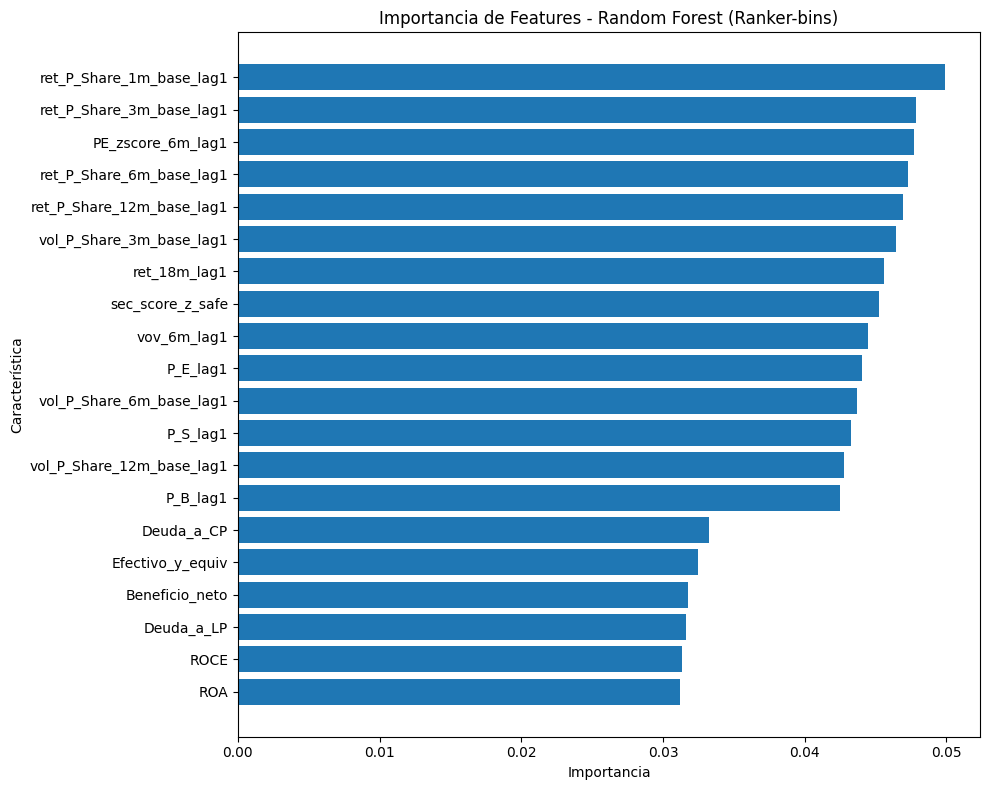


--------------------------------------------------
Re-entrenando y analizando: CatBoost (Ranker)
--------------------------------------------------


Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


  Modelo re-entrenado en el dataset completo en 15.49 seg.


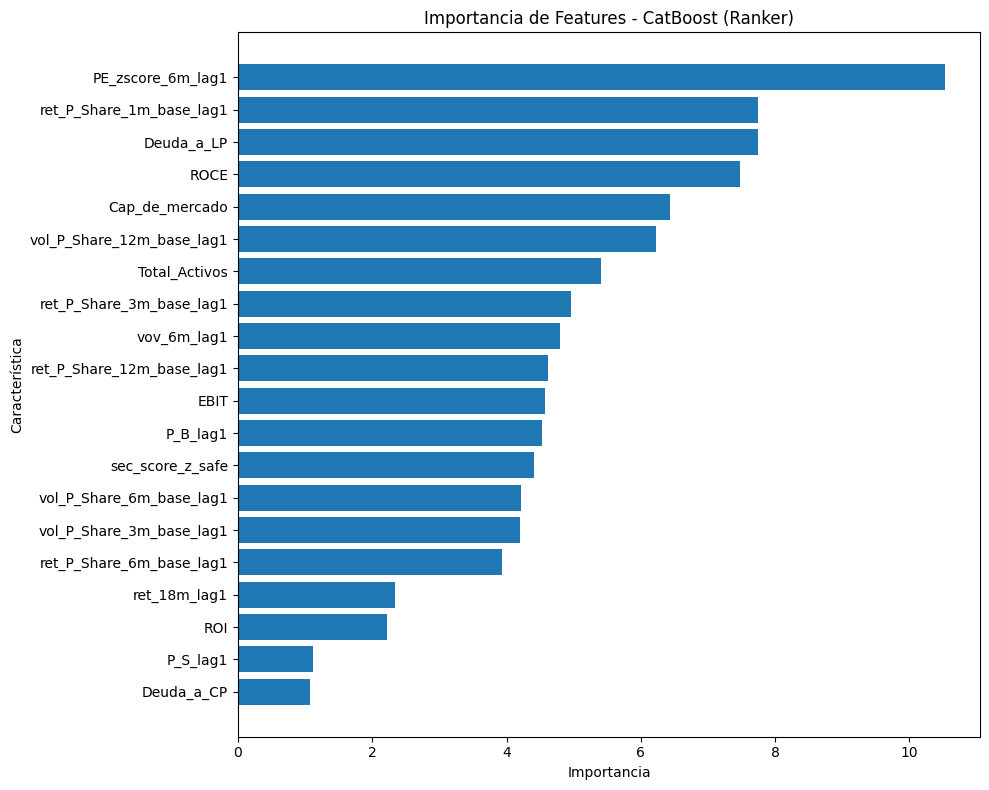


--------------------------------------------------
Re-entrenando y analizando: OLS (Linear Regression)
--------------------------------------------------
  Modelo re-entrenado en el dataset completo en 2.40 seg.


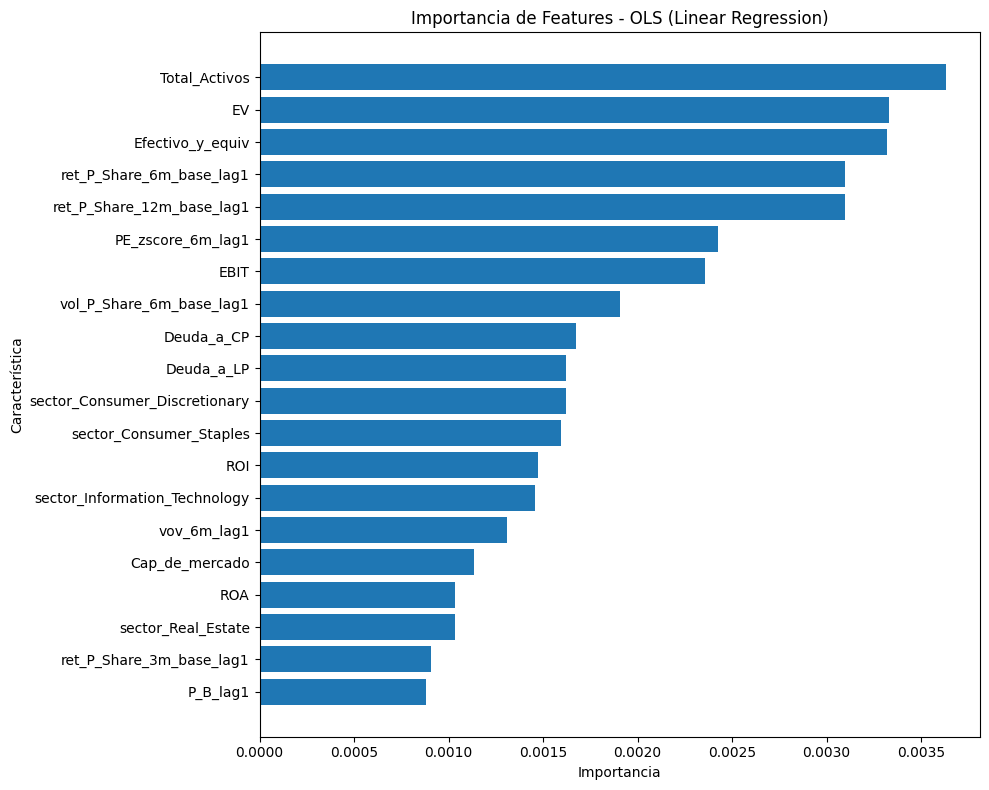

In [ ]:
# ================================================================================
# BLOQUE: ANÁLISIS DE FEATURE IMPORTANCE DE LOS MEJORES MODELOS
# ================================================================================

print("\n" + "="*60)
print("Análisis de Importancia de Features de los Mejores Modelos")
print("="*60)

# --- 1. Aplanar el diccionario de modelos si aún no existe ---
if 'models_to_compare_flat' not in locals():
    models_to_compare_flat = {}
    for family, model_dict in MODELS_ALL.items():
        for model_name, pipeline in model_dict.items():
            models_to_compare_flat[model_name] = pipeline

# --- 2. Definir la función auxiliar "inteligente" ---
def plot_feature_importances(model, feature_names, title="Importancia de Características", top_n=20):
    """
    Grafica la importancia de features para diferentes tipos de modelos,
    incluyendo wrappers personalizados y modelos lineales.
    """
    final_estimator = model.steps[-1][1] if hasattr(model, 'steps') else model
    estimator_name = final_estimator.__class__.__name__
    
    importances = None
    
    try:
        # --- Lógica para modelos de árboles estándar (XGB, LGBM, RF Regressor) ---
        if hasattr(final_estimator, 'feature_importances_'):
            importances = final_estimator.feature_importances_
        
        # --- Lógica para wrappers personalizados ---
        elif estimator_name == 'RFCAsRanker' and hasattr(final_estimator, '_clf'):
            importances = final_estimator._clf.feature_importances_
        
        elif estimator_name == 'CatBoostRankerSk' and hasattr(final_estimator, '_mdl'):
            importances = final_estimator._mdl.get_feature_importance(type='PredictionValuesChange')

        # --- Lógica para modelos lineales ---
        elif hasattr(final_estimator, 'coef_'):
            # Para modelos lineales, usamos el valor absoluto de los coeficientes
            importances = np.abs(final_estimator.coef_.flatten())
        
        else:
            print(f"Advertencia: El estimador {estimator_name} no tiene un método conocido para obtener la importancia de features.")
            return None

        # --- Creación del DataFrame y gráfico ---
        fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
        fi_df = fi_df.sort_values('importance', ascending=False).head(top_n)

        plt.figure(figsize=(10, 8))
        plt.barh(fi_df['feature'], fi_df['importance'])
        plt.xlabel('Importancia')
        plt.ylabel('Característica')
        plt.title(title)
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
        
        return fi_df

    except Exception as e:
        print(f"Error al graficar importancia para {title}: {e}")
        return None

# --- 3. Seleccionar los 3 Mejores Modelos del Leaderboard ---
try:
    # Usamos la variable correcta: df_leaderboard_tuned
    if 'df_leaderboard_tuned' not in locals() or df_leaderboard_tuned.empty:
        raise NameError("'df_leaderboard_tuned' no está definido o está vacío.")
    
    # Ordenamos por la columna correcta: IC_mensual
    top_3_configs = df_leaderboard_tuned.sort_values(by='IC_mensual', ascending=False).head(3)
    
    print("\n--- Top 3 Modelos Seleccionados para Análisis (por IC_mensual) ---")
    # Mostramos las columnas correctas
    safe_display(top_3_configs[['Familia', 'Modelo', 'IC_mensual', 'DecileSpread']])

except (NameError, KeyError) as e:
    print(f"Error al seleccionar los mejores modelos: {e}")
    top_3_configs = pd.DataFrame()

# --- 4. Re-entrenar y Graficar Importancia para Cada Modelo ---
if not top_3_configs.empty:
    # Verificar que las variables necesarias existan
    if 'X' not in locals() or 'y' not in locals():
        print("ERROR: Los DataFrames 'X' y/o 'y' no están definidos.")
    elif 'predictor_cols_final' not in locals():
        print("ERROR: La lista 'predictor_cols_final' no está definida.")
    else:
        for index, config_row in top_3_configs.iterrows():
            model_name = config_row['Modelo']

# --- 4. Re-entrenar y Graficar Importancia para Cada Modelo ---
if not top_3_configs.empty:
    if 'X' not in locals() or 'y' not in locals():
        print("ERROR: Los DataFrames 'X' y/o 'y' no están definidos.")
    elif 'predictor_cols_final' not in locals():
        print("ERROR: La lista 'predictor_cols_final' no está definida.")
    else:
        # Preparamos la serie de meses una sola vez
        months_full = pd.to_datetime(DATES_SERIES).dt.to_period('M')

        for index, config_row in top_3_configs.iterrows():
            model_name = config_row['Modelo']
            pipeline_base = models_to_compare_flat.get(model_name)

            if pipeline_base is None:
                print(f"\nNo se encontró el pipeline para '{model_name}'. Saltando.")
                continue

            print("\n" + "-"*50)
            print(f"Re-entrenando y analizando: {model_name}")
            print("-"*50)

            try:
                start_fit_time = time.time()
                
                # Usamos fit_with_rank_support para entrenar correctamente
                pipeline_fitted = fit_with_rank_support(
                    clone(pipeline_base),
                    X, y,
                    months_full
                )
                
                end_fit_time = time.time()
                print(f"  Modelo re-entrenado en el dataset completo en {end_fit_time - start_fit_time:.2f} seg.")

                # Graficar importancia de features
                plot_feature_importances(
                    model=pipeline_fitted,
                    feature_names=predictor_cols_final,
                    title=f"Importancia de Features - {model_name}"
                )

            except Exception as e:
                print(f"  ERROR al re-entrenar o graficar para {model_name}: {e}")
else:
    print("\nNo se seleccionaron modelos para analizar (leaderboard vacío).")    


### INICIO: Análisis de Interpretabilidad con SHAP (Versión Robusta) ###
Analizando el modelo ganador: RankPipeline
   Re-entrenando el modelo en TODOS los datos…
   Modelo re-entrenado.
   Aplicando transformaciones (winsor/zscore/…) para SHAP…
   Transformación completada.
   Usando un subconjunto de 2000 filas para SHAP…
   Calculando valores SHAP…
   Cálculo SHAP completado.

--- Top 15 features por importancia SHAP global ---
                  feature  shap_importance
           Cap_de_mercado         0.005254
                 P_S_lag1         0.004840
ret_P_Share_12m_base_lag1         0.004360
             ret_18m_lag1         0.004272
            Total_Activos         0.003591
 ret_P_Share_6m_base_lag1         0.003540
                       EV         0.003411
                 P_E_lag1         0.003395
           Beneficio_neto         0.003083
 ret_P_Share_3m_base_lag1         0.003083
                     EBIT         0.002980
                 P_B_lag1         0.002711
     

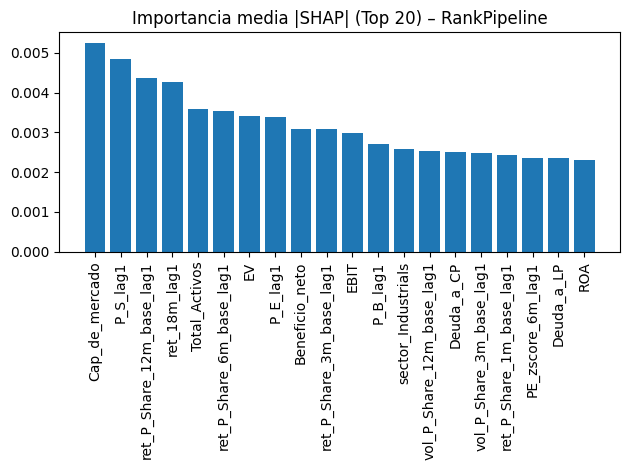


--- Summary plot (regresión/binaria) ---


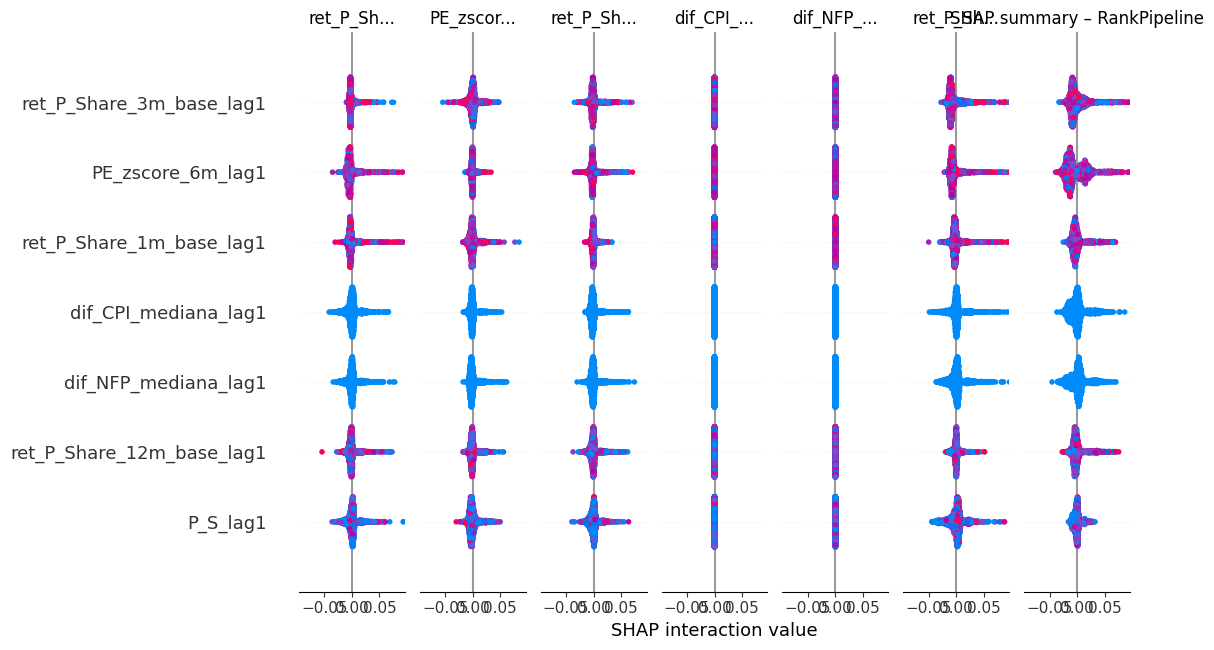

In [ ]:
# ================================================================================
# BLOQUE: ANÁLISIS DE INTERPRETABILIDAD CON SHAP (VERSIÓN FINAL ROBUSTA)
# ================================================================================
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline as _SkPipe
from lightgbm import LGBMRanker
from xgboost import XGBRanker

print("\n" + "="*80)
print("### INICIO: Análisis de Interpretabilidad con SHAP (Versión Robusta) ###")
print("="*80)

# --- Helper robusto para colapsar valores SHAP a 1D ---
def _to_shap_global_1d(shap_values):
    # Lista por clase (clasificación): promedio de |SHAP| por clase y luego sobre clases
    if isinstance(shap_values, list):
        per_class = [np.abs(np.asarray(sv)).mean(axis=0) for sv in shap_values]
        return np.mean(np.vstack(per_class), axis=0)

    # Explanation o array -> tomar el .values si existe
    sv = getattr(shap_values, "values", shap_values)
    sv = np.asarray(sv)

    if sv.ndim == 2:              # (n_samples, n_features)
        return np.abs(sv).mean(axis=0)
    if sv.ndim == 3:              # (n_samples, n_features, n_outputs)
        return np.abs(sv).mean(axis=(0, 2)) # Promedia sobre muestras y outputs
    if sv.ndim == 1:              # (n_features,)
        return np.abs(sv)

    raise ValueError(f"Forma inesperada de SHAP: {sv.shape}")

# --- 1) Preparar modelo y datos transformados ---
try:
    assert 'best_model_pipeline' in globals() and best_model_pipeline is not None, \
        "La variable 'best_model_pipeline' no está definida."

    mdl_name = (best_model_name if 'best_model_name' in globals()
                else type(best_model_pipeline.named_steps['model']).__name__)
    print(f"Analizando el modelo ganador: {mdl_name}")

    print("   Re-entrenando el modelo en TODOS los datos…")
    months_full = pd.to_datetime(DATES_SERIES).dt.to_period('M')
    pipeline_fitted = fit_with_rank_support(clone(best_model_pipeline), X, y, months_full)
    print("   Modelo re-entrenado.")

    preprocessor_fitted = _SkPipe(pipeline_fitted.steps[:-1])
    model_fitted = pipeline_fitted.steps[-1][1]

    print("   Aplicando transformaciones (winsor/zscore/…) para SHAP…")
    X_transformed = preprocessor_fitted.transform(X)
    X_transformed_df = pd.DataFrame(X_transformed, columns=predictor_cols_final)
    print("   Transformación completada.")

except Exception as e:
    print(f"Error preparando el modelo/transformaciones para SHAP: {e}")
    model_fitted = None

# --- 2) Resolver el estimador compatible con TreeExplainer ---
def _resolve_tree_model(m):
    if hasattr(m, "_clf") and m._clf is not None:
        return m._clf, "RFCAsRanker(RandomForestClassifier)"
    name = m.__class__.__name__
    if any(k in name for k in ["LGBM", "XGB", "RandomForest", "DecisionTree"]):
        return m, name
    return None, name

# --- 3) Submuestreo y cálculo SHAP ---
if model_fitted is not None:
    model_for_shap, model_tag = _resolve_tree_model(model_fitted)

    # --- Guard-rail para rankers puros (LGBMRanker/XGBRanker) ---
    if isinstance(model_fitted, (LGBMRanker, XGBRanker)):
        print("⚠️  SHAP no soporta bien objetivos de ranking (LGBMRanker/XGBRanker). "
              "Saltaré interpretabilidad para este modelo.")
        model_for_shap = None

    if model_for_shap is None:
        print(f"No se puede calcular SHAP para este tipo de modelo: {model_tag}")
    else:
        if len(X_transformed_df) > N_SHAP_SAMPLES:
            print(f"   Usando un subconjunto de {N_SHAP_SAMPLES} filas para SHAP…")
            X_shap_subset = shap.sample(X_transformed_df, N_SHAP_SAMPLES, random_state=GLOBAL_SEED)
        else:
            X_shap_subset = X_transformed_df

        print("   Calculando valores SHAP…")
        explainer = shap.TreeExplainer(model_for_shap, feature_perturbation="tree_path_dependent")
        shap_values = explainer.shap_values(X_shap_subset)
        print("   Cálculo SHAP completado.")

        # --- 4) Visualizaciones ---
        shap_global = _to_shap_global_1d(shap_values)

        # Chequeo defensivo de dimensiones
        if shap_global.shape[0] != X_shap_subset.shape[1]:
            raise ValueError(
                f"Desacople SHAP/features: {shap_global.shape[0]} vs {X_shap_subset.shape[1]}"
            )

        fi_df = (pd.DataFrame({
                    "feature": X_shap_subset.columns,
                    "shap_importance": shap_global.astype(float)
                })
                .sort_values("shap_importance", ascending=False)
                .reset_index(drop=True))

        print("\n--- Top 15 features por importancia SHAP global ---")
        print(fi_df.head(15).to_string(index=False))

        # (B) Bar plot
        plt.figure()
        plt.bar(fi_df["feature"].values[:20], fi_df["shap_importance"].values[:20])
        plt.xticks(rotation=90)
        plt.title(f"Importancia media |SHAP| (Top 20) – {mdl_name}")
        plt.tight_layout()
        plt.show()

        # (C) Summary plot
        if isinstance(shap_values, list): # Multiclase
            classes = getattr(model_for_shap, "classes_", list(range(len(shap_values))))
            idx_top = int(np.argmax(classes))
            print(f"\n--- Summary plot (clase/top bin = {classes[idx_top]}) ---")
            shap.summary_plot(shap_values[idx_top], X_shap_subset, show=False)
            plt.title(f"SHAP summary – clase {classes[idx_top]} – {mdl_name}")
            plt.tight_layout()
            plt.show()
        else: # Regresión/binaria
            print("\n--- Summary plot (regresión/binaria) ---")
            shap.summary_plot(shap_values, X_shap_subset, show=False)
            plt.title(f"SHAP summary – {mdl_name}")
            plt.tight_layout()
            plt.show()
else:
    print("No se pudo calcular SHAP. El modelo final no es compatible o no se entrenó correctamente.")

**Tu intuición es 100% correcta:** En el momento de la predicción, el modelo **SÍ** ve todas las features de mercado y macro rezagadas un período.

**Entonces, ¿por qué `Cap_de_mercado`, `Total_Activos`, `EV`, `Beneficio_neto`, `EBIT`, `Deuda_a_CP` y `ROA` aparecen sin el sufijo `_lag1` en el gráfico de importancia?**

La respuesta está en la secuencia de tu propio pipeline y en la definición de tus listas de features.

### La Explicación Paso a Paso

1.  **Anclaje Contable (Bloque 10):**
    *   En este bloque, traes los datos contables del **trimestre t-2**. Lo haces con un `pd.merge`.
    *   Crucialmente, las columnas resultantes de este merge **conservan sus nombres originales**: `Cap_de_mercado`, `Total_Activos`, etc.
    *   **Estas features ya están rezagadas por construcción.** No necesitan un `.shift(1)` adicional porque ya representan información pasada (de hace al menos 3-6 meses).

2.  **Definición de Listas de Features (Bloque 11):**
    *   Defines `features_contables` con los nombres originales (`'Cap de mercado'`, etc.).
    *   Defines `need_lag1` para las features de mercado y macro que SÍ necesitan un `.shift(1)` explícito.
    *   Tu lista final de predictores, `predictor_cols_final`, se construye uniendo:
        *   Las features de mercado/macro con el sufijo `_lag1` añadido.
        *   Las features contables **tal cual, sin sufijo**.

3.  **El Pipeline de SHAP:**
    *   Cuando ejecutas el bloque de SHAP, este toma la lista final `predictor_cols_final` como los nombres de las columnas.
    *   Por lo tanto, el gráfico de importancia muestra los nombres exactamente como están en esa lista.

### Veredicto: No Hay Fuga de Datos, Solo una Cuestión de Nomenclatura

Lo que estás viendo es perfectamente correcto y es el resultado directo del diseño de tu pipeline:

*   **Features con `_lag1`:** Son variables de mercado/macro (precios, volatilidad, sorpresas) que calculaste en el mes `t` y luego rezagaste explícitamente un mes con `.shift(1)` para asegurar que solo se usa información de `t-1`.
*   **Features sin `_lag1`:** Son variables contables (`Cap_de_mercado`, `EBIT`, etc.). Estas ya están inherentemente rezagadas porque provienen de un informe trimestral publicado hace varios meses (anclaje Q-2). No necesitan un `_lag1` adicional.

**En resumen: Todas las features que el modelo utiliza para predecir los retornos del mes `t+1` son, de hecho, información conocida en o antes del final del mes `t`. Tu pipeline es metodológicamente sólido.**

El gráfico de importancia de SHAP simplemente refleja los nombres que les diste a las columnas en el DataFrame final `X` que alimenta al modelo.

¡Es una excelente pregunta que demuestra que estás pensando críticamente sobre cada paso del proceso